<a href="https://colab.research.google.com/github/OJB-Quantum/Generative-Layout-Notebooks/blob/main/Semimetal_Nanobridge_Transmon_Qubit_Design_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!uv pip install -q -U phidl gdstk matplotlib numpy scipy

DEPENDENCY SUMMARY
NumPy:                 2.0.2
PHIDL:                 1.7.2
GDSTK:                 1.0.1
SciPy:                 not required

PRE-DRC REPORT
PASS  Feedline CPW impedance lower bound              actual=   49.22150  rule=   45.00000
PASS  Feedline CPW impedance upper bound              actual=   49.22150  rule=   55.00000
PASS  Resonator CPW impedance lower bound             actual=   49.99869  rule=   45.00000
PASS  Resonator CPW impedance upper bound             actual=   49.99869  rule=   55.00000
PASS  Resonator CPW 50-ohm target error               actual=    0.00131  rule=    0.10000
PASS  Feedline CPW gap                                actual=    6.00000  rule=    4.00000
PASS  Resonator CPW gap                               actual=    6.33500  rule=    4.00000
PASS  Feedline center width                           actual=   12.00000  rule=    2.50000
PASS  Resonator center width                          actual=   12.00000  rule=    2.50000
PASS  Accepted Euler be

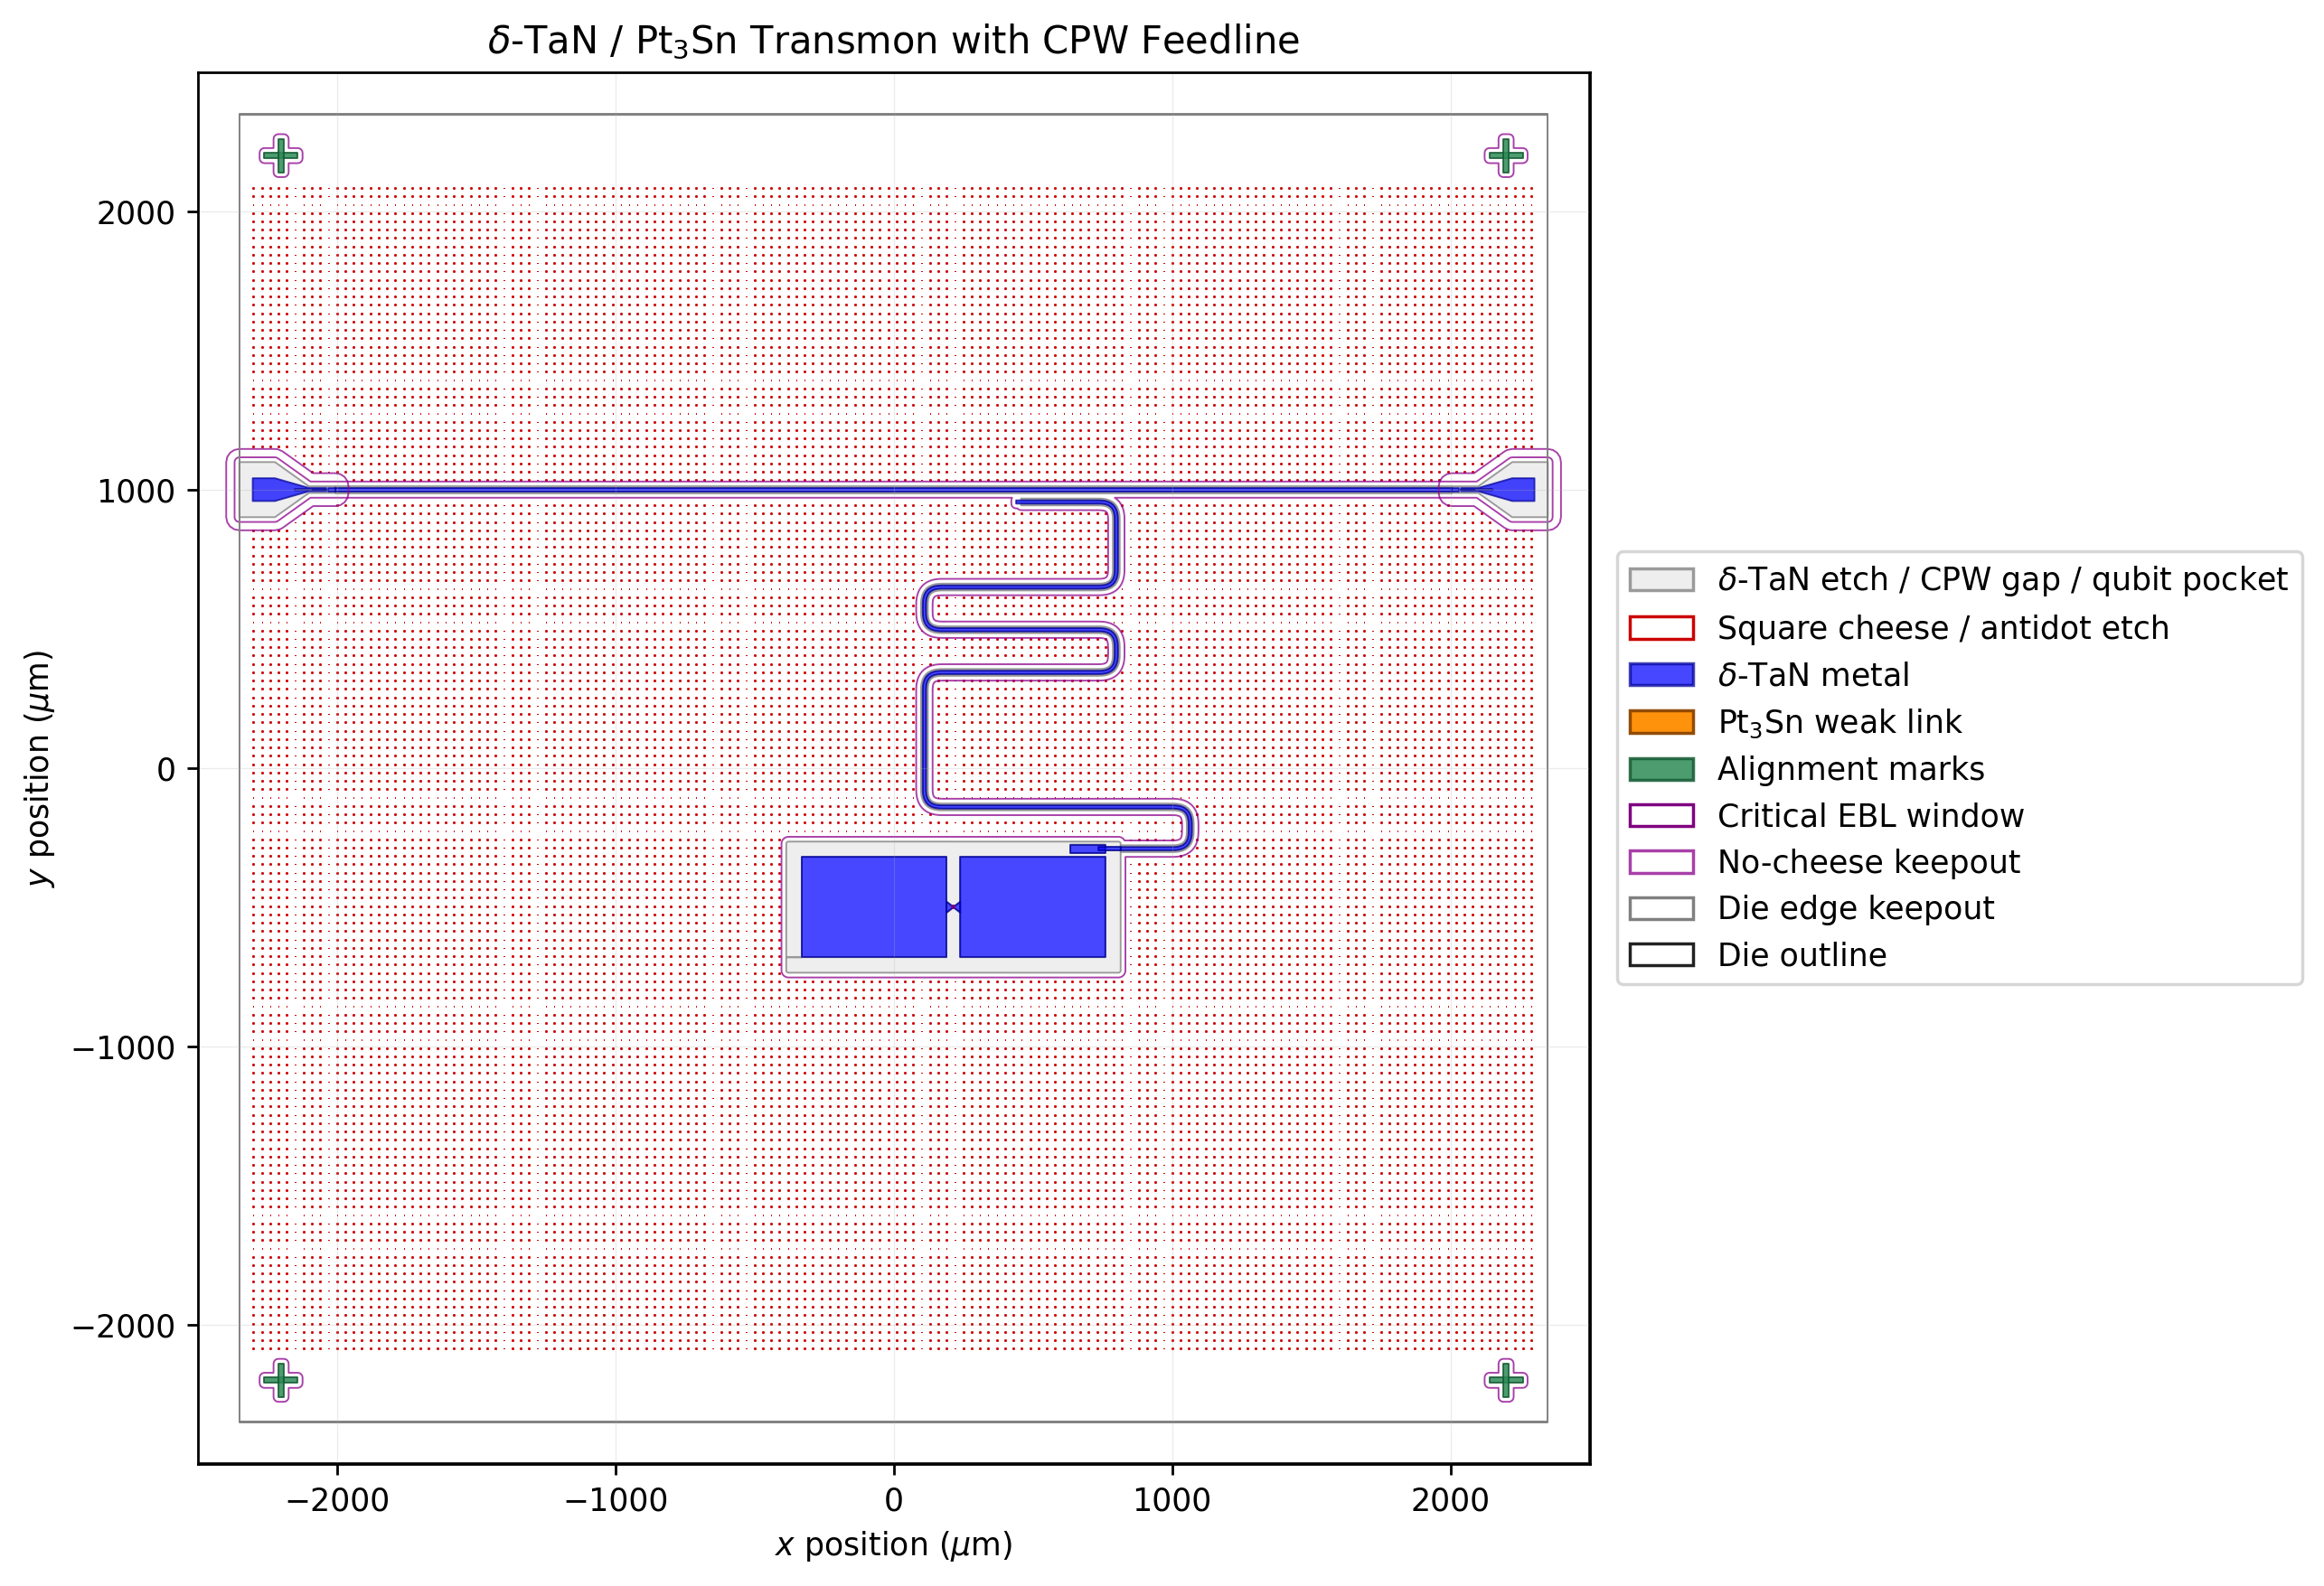

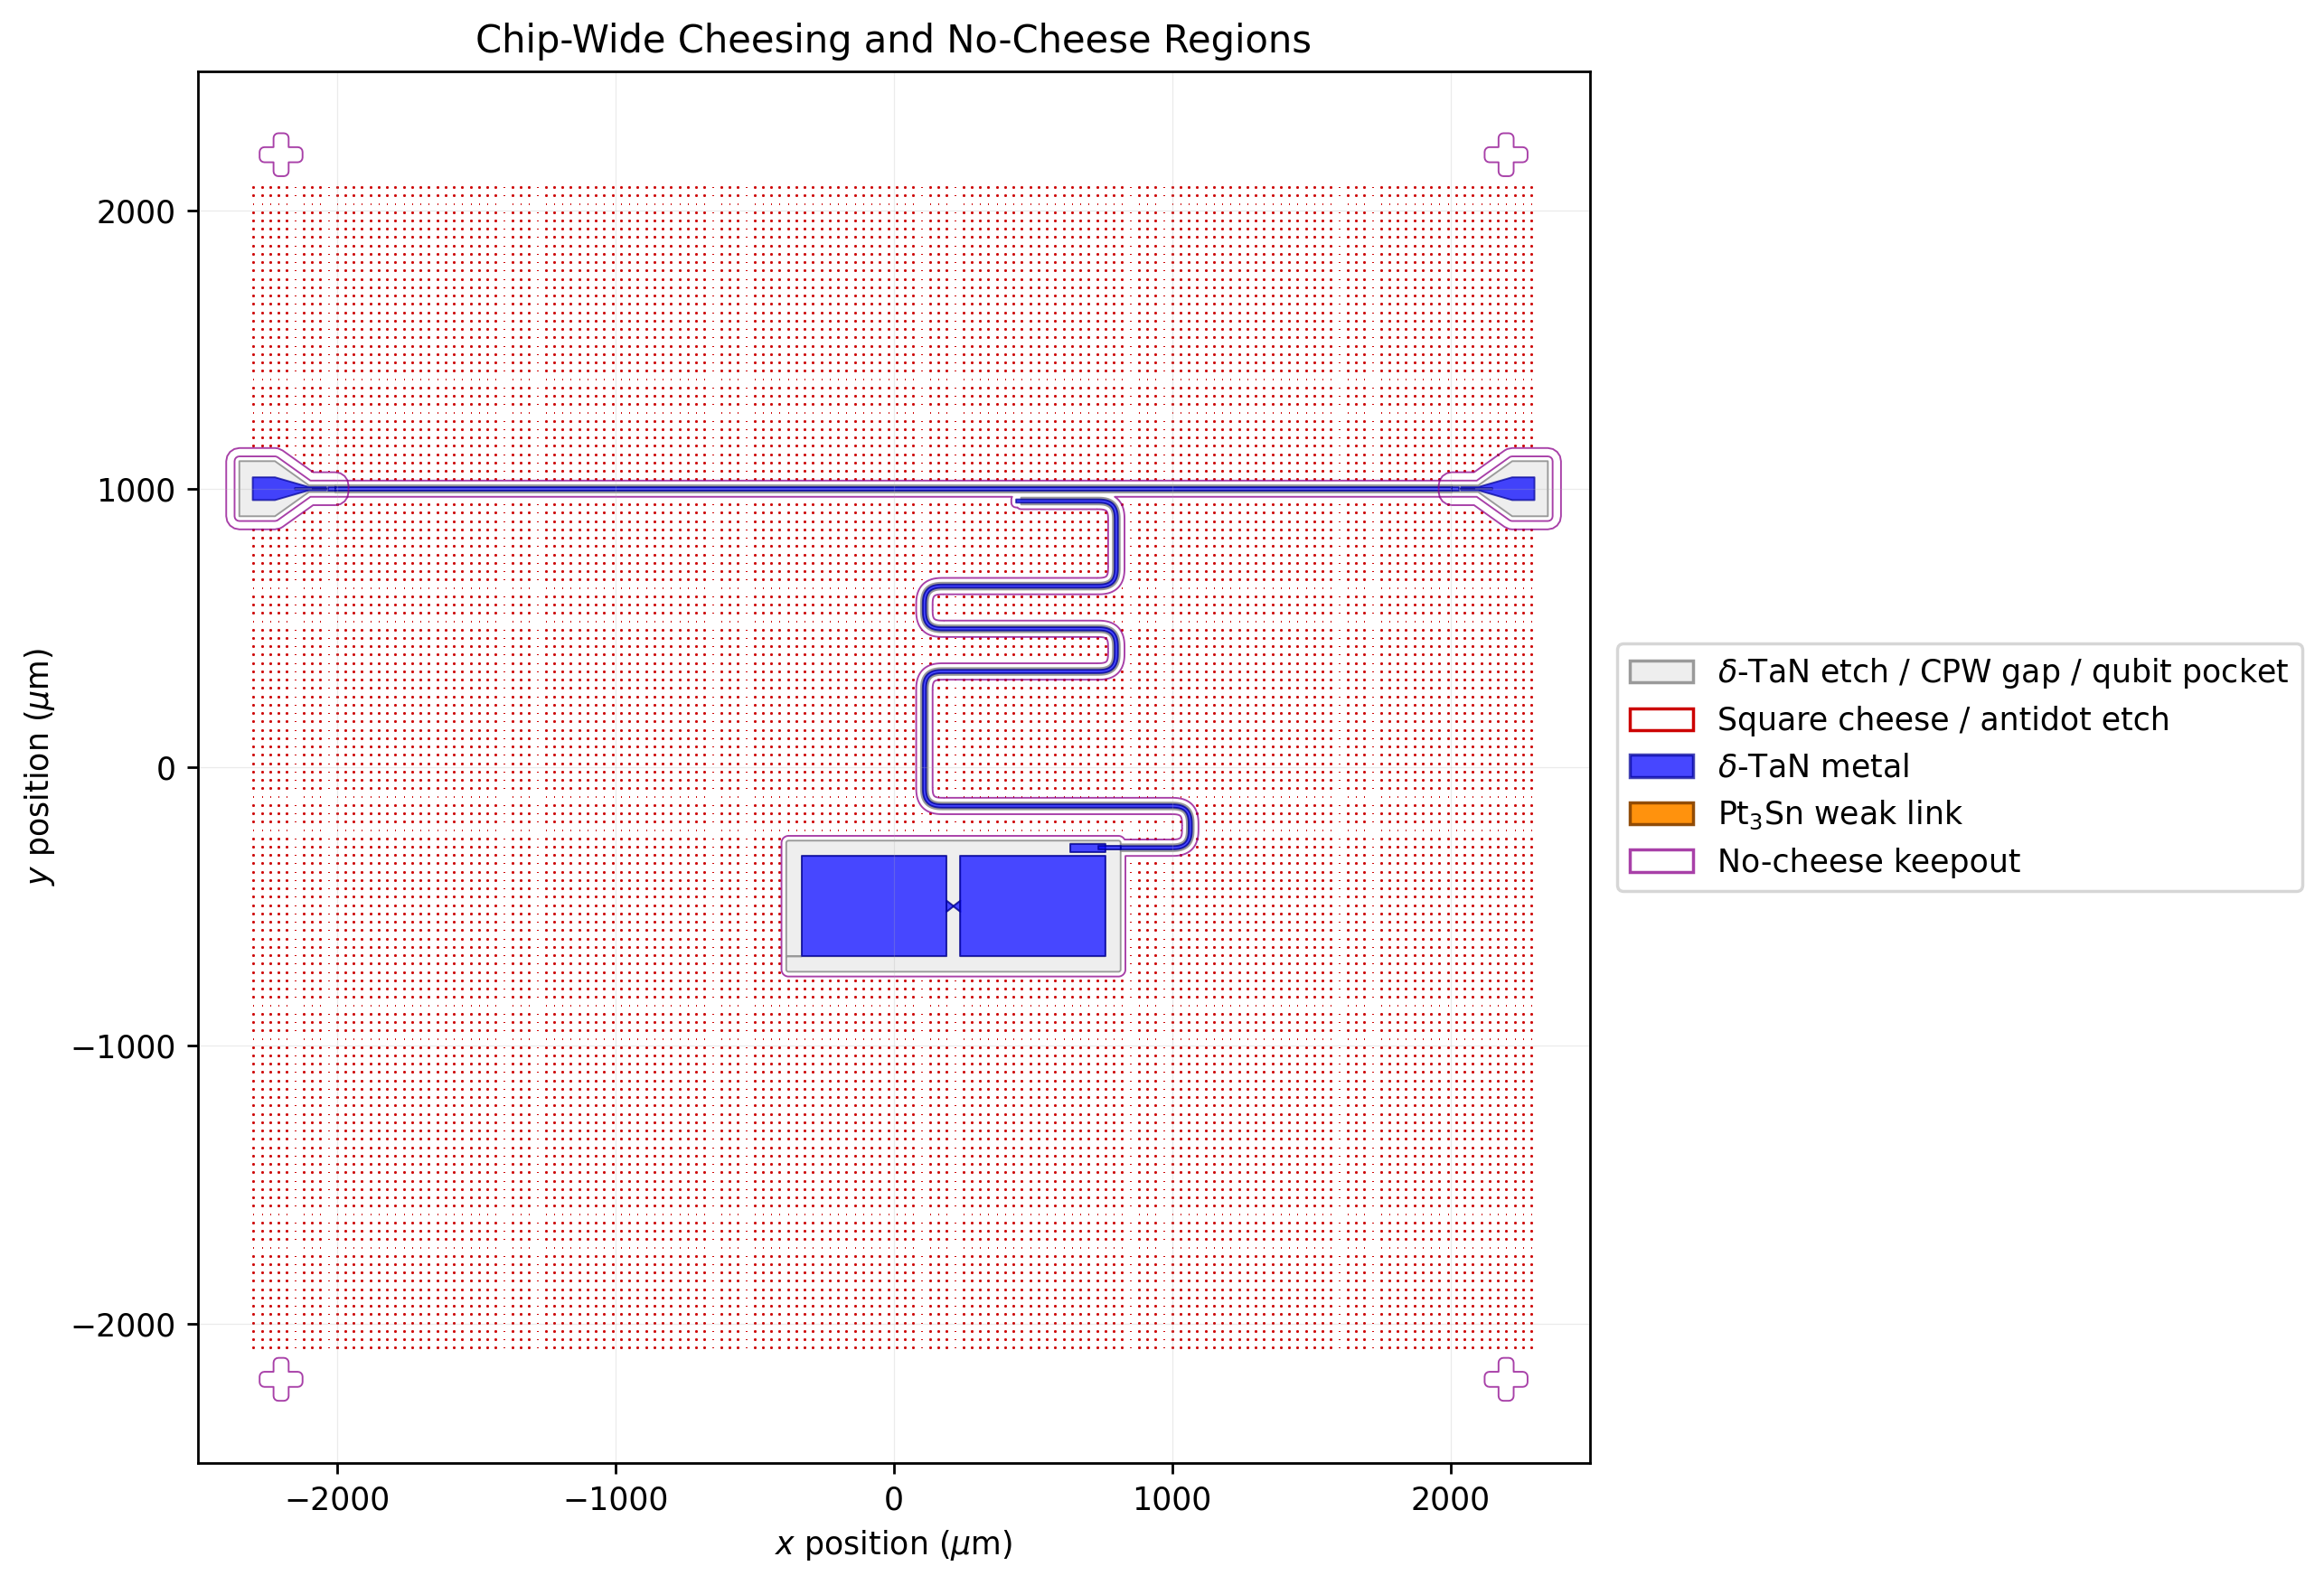

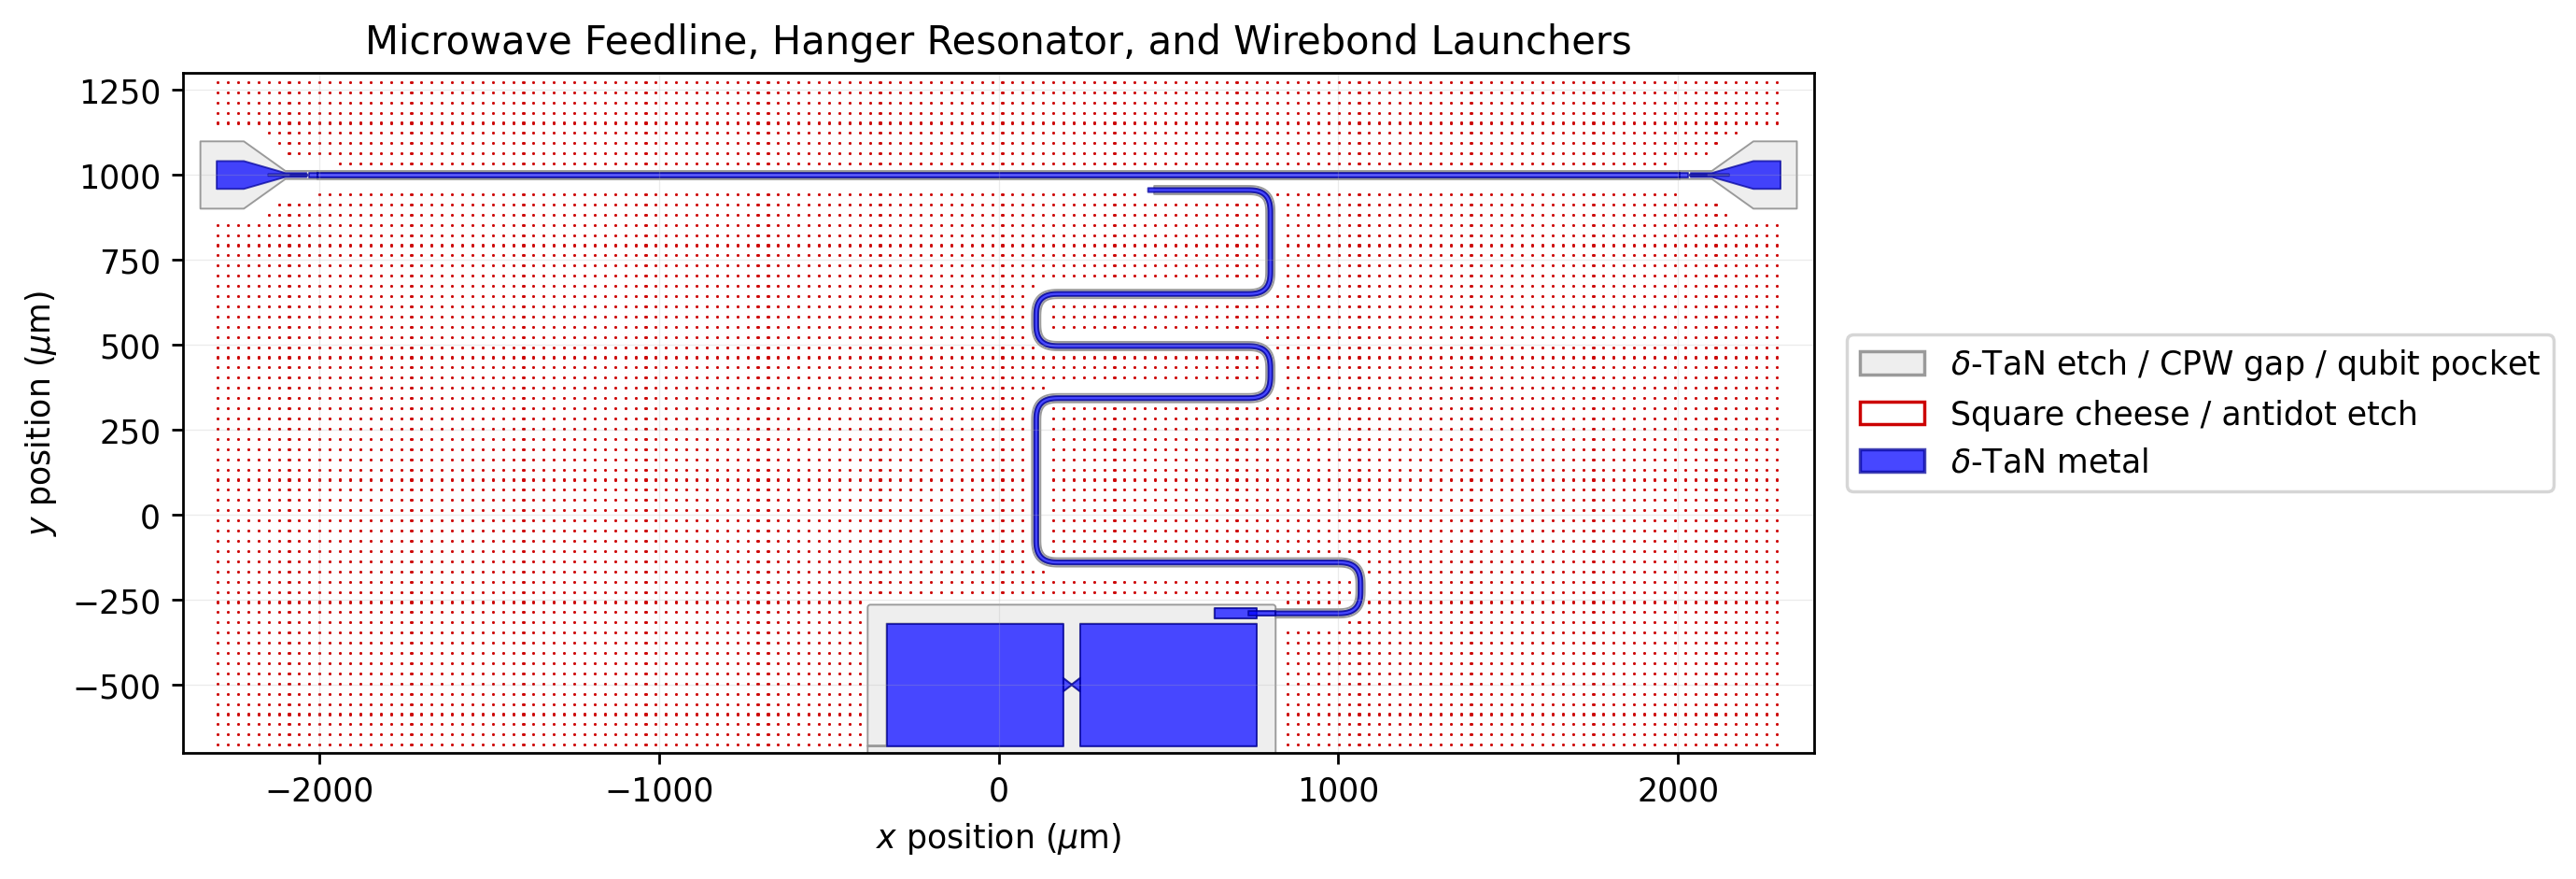

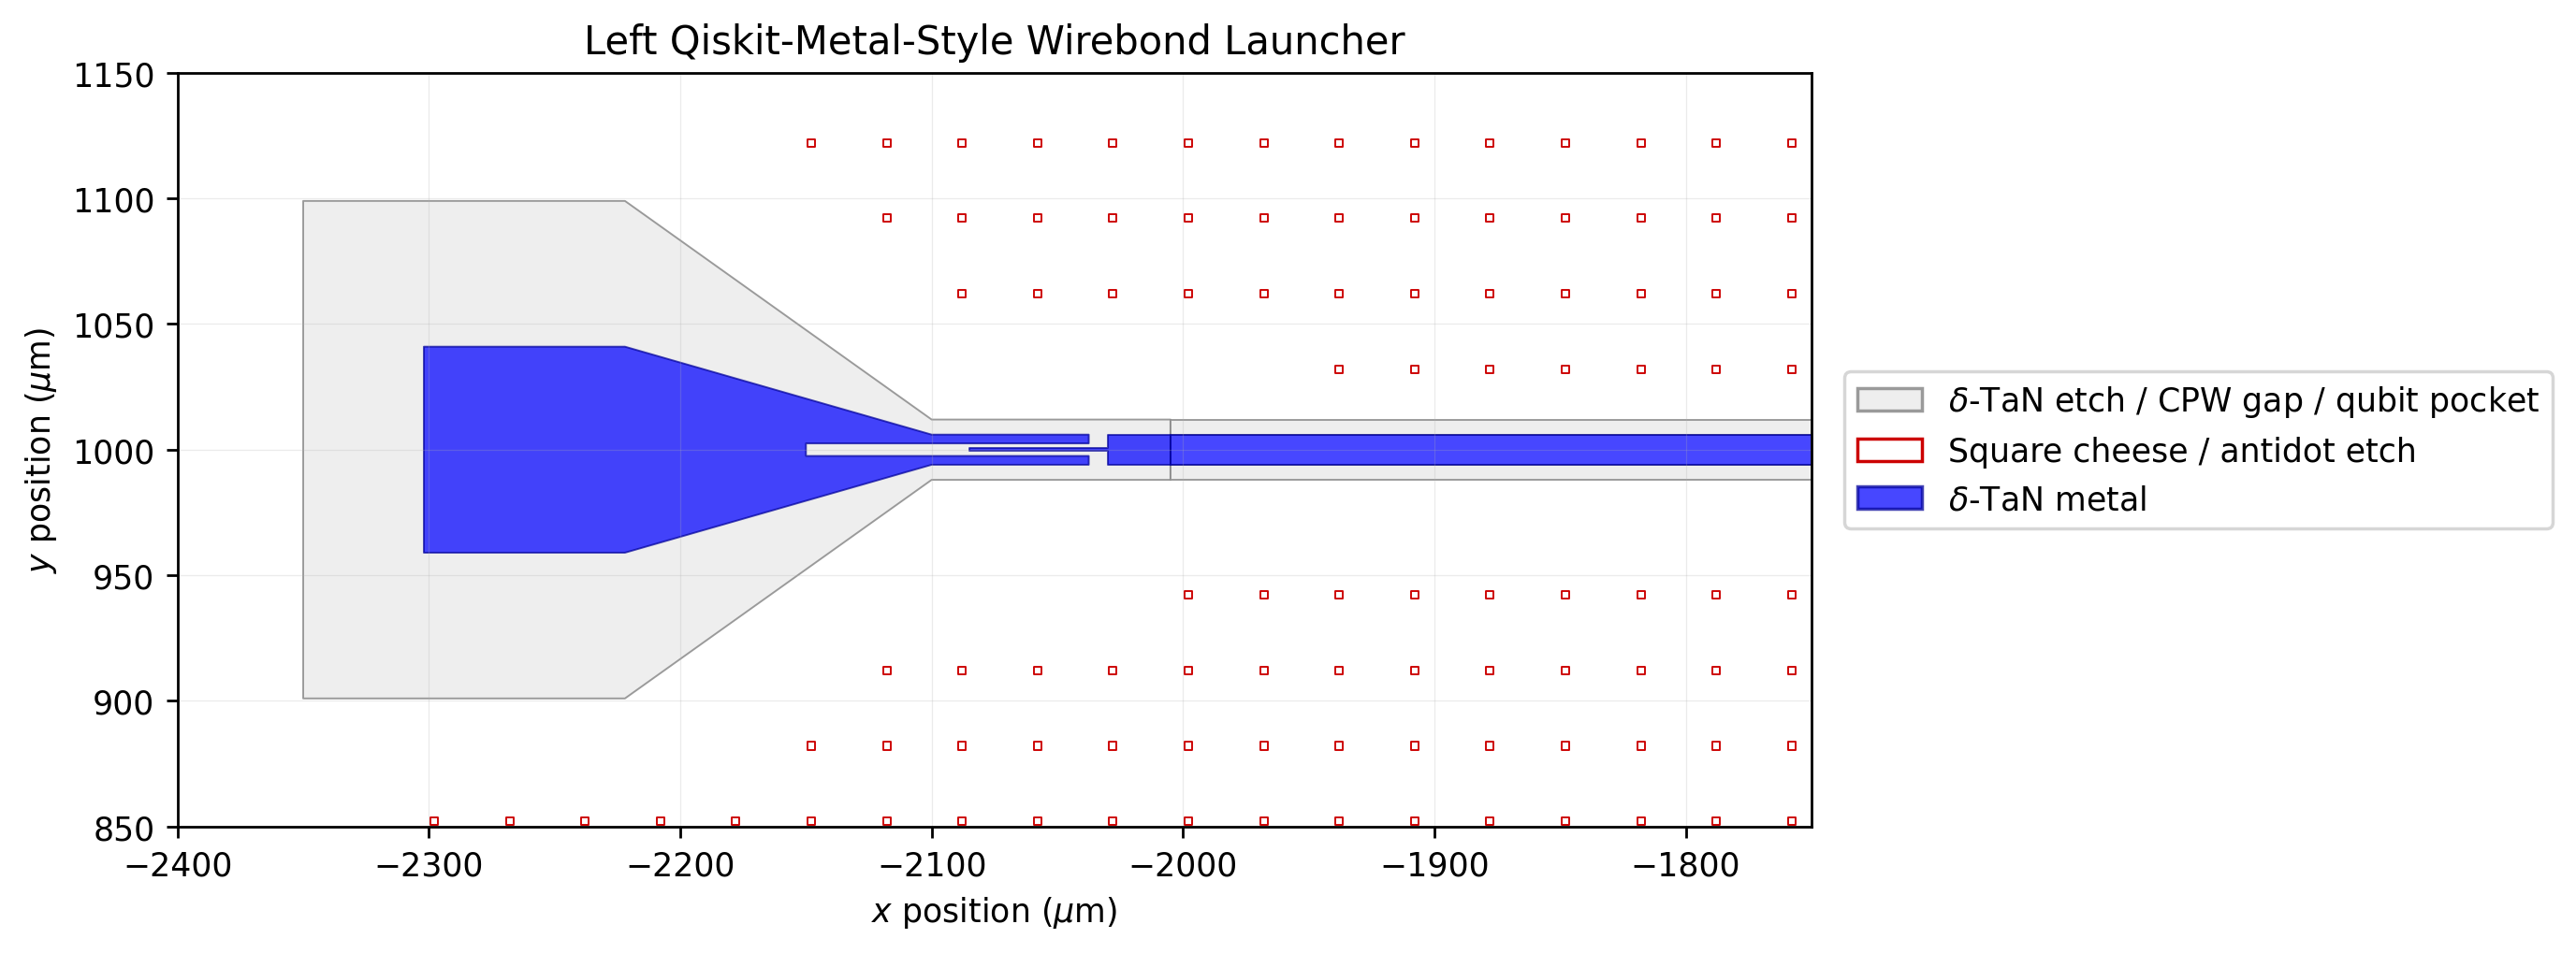

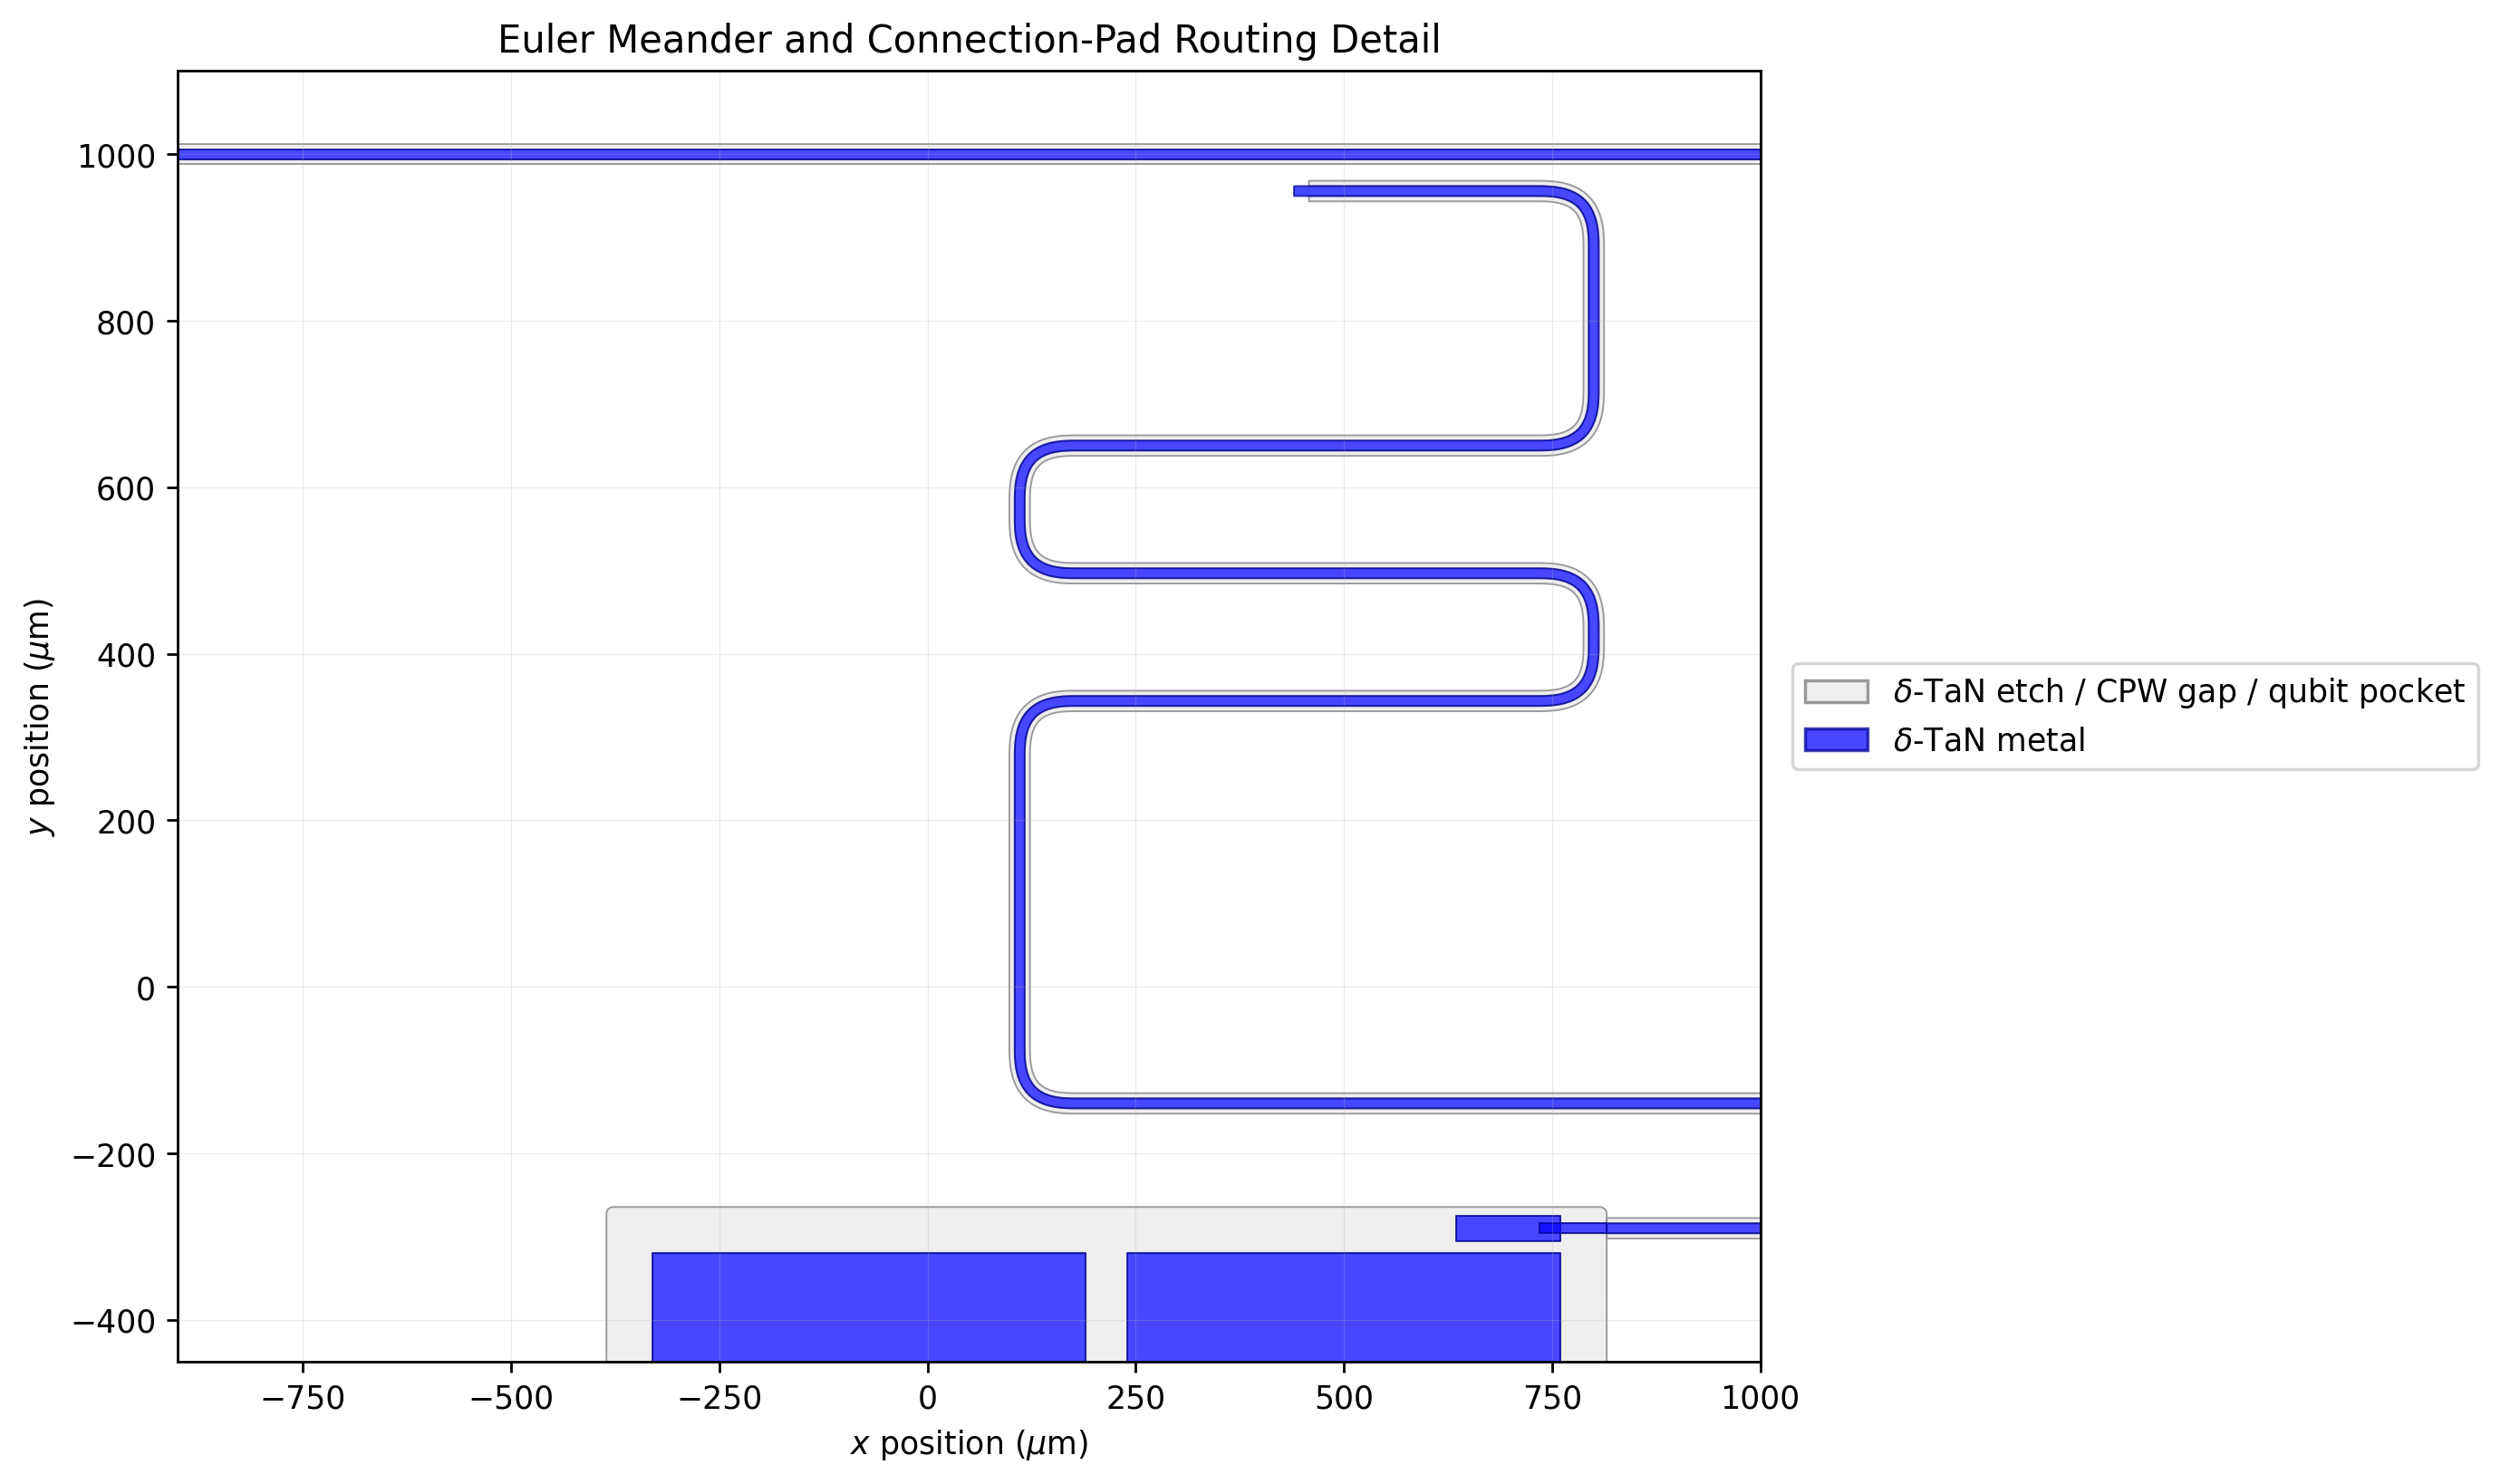

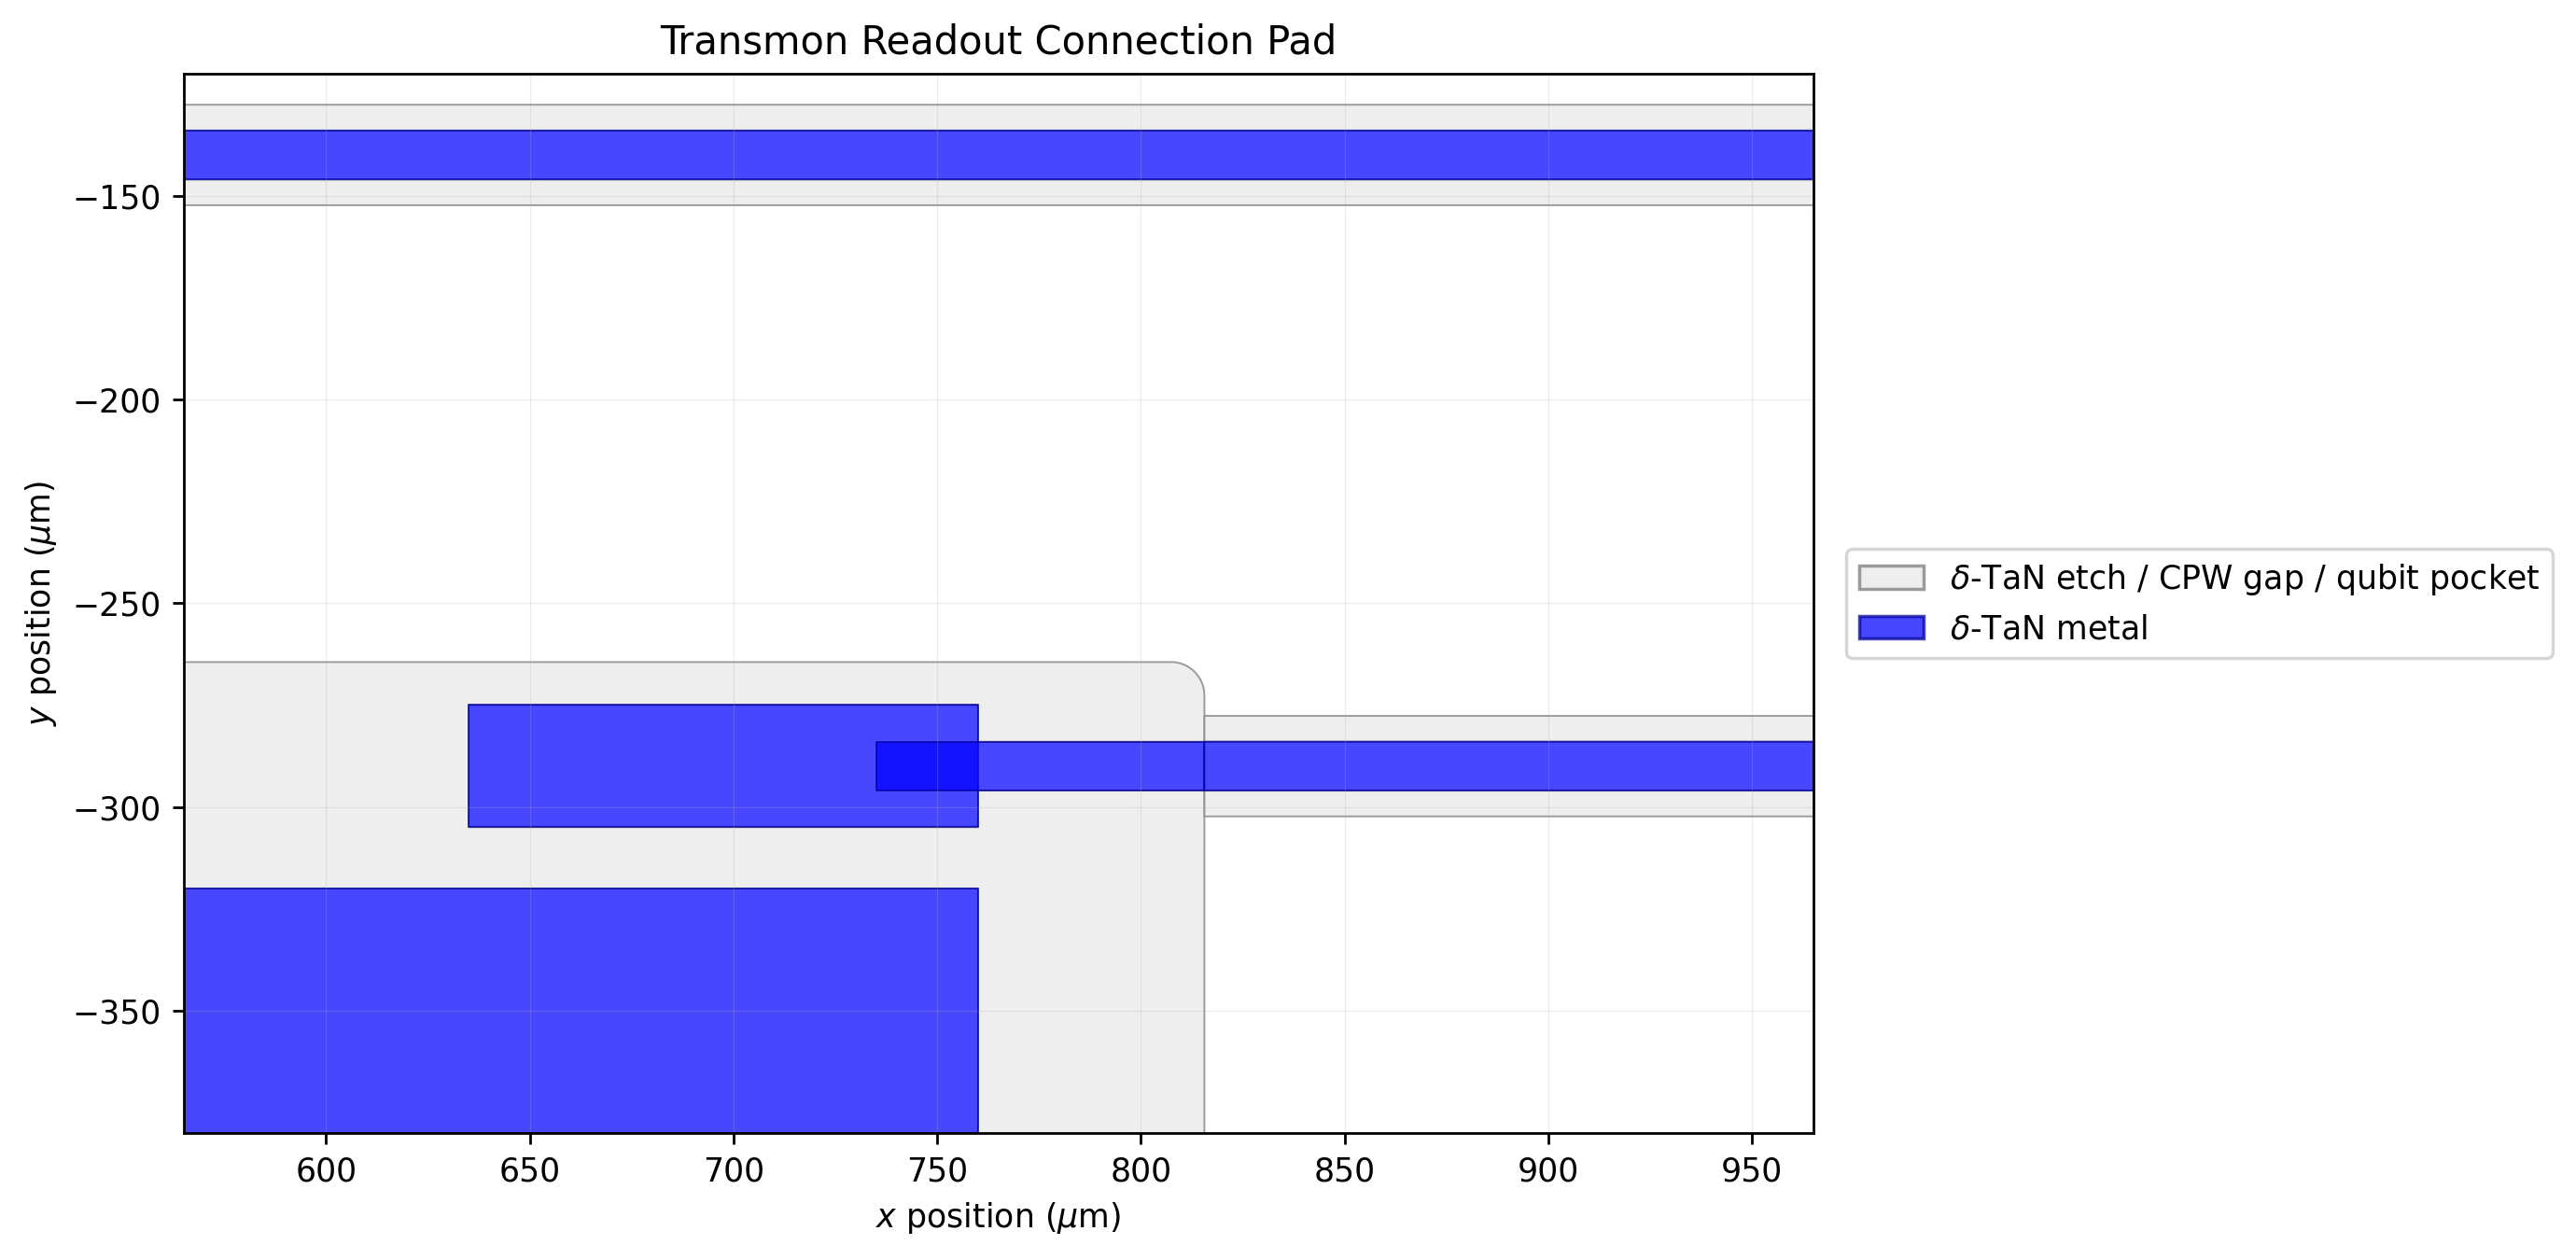

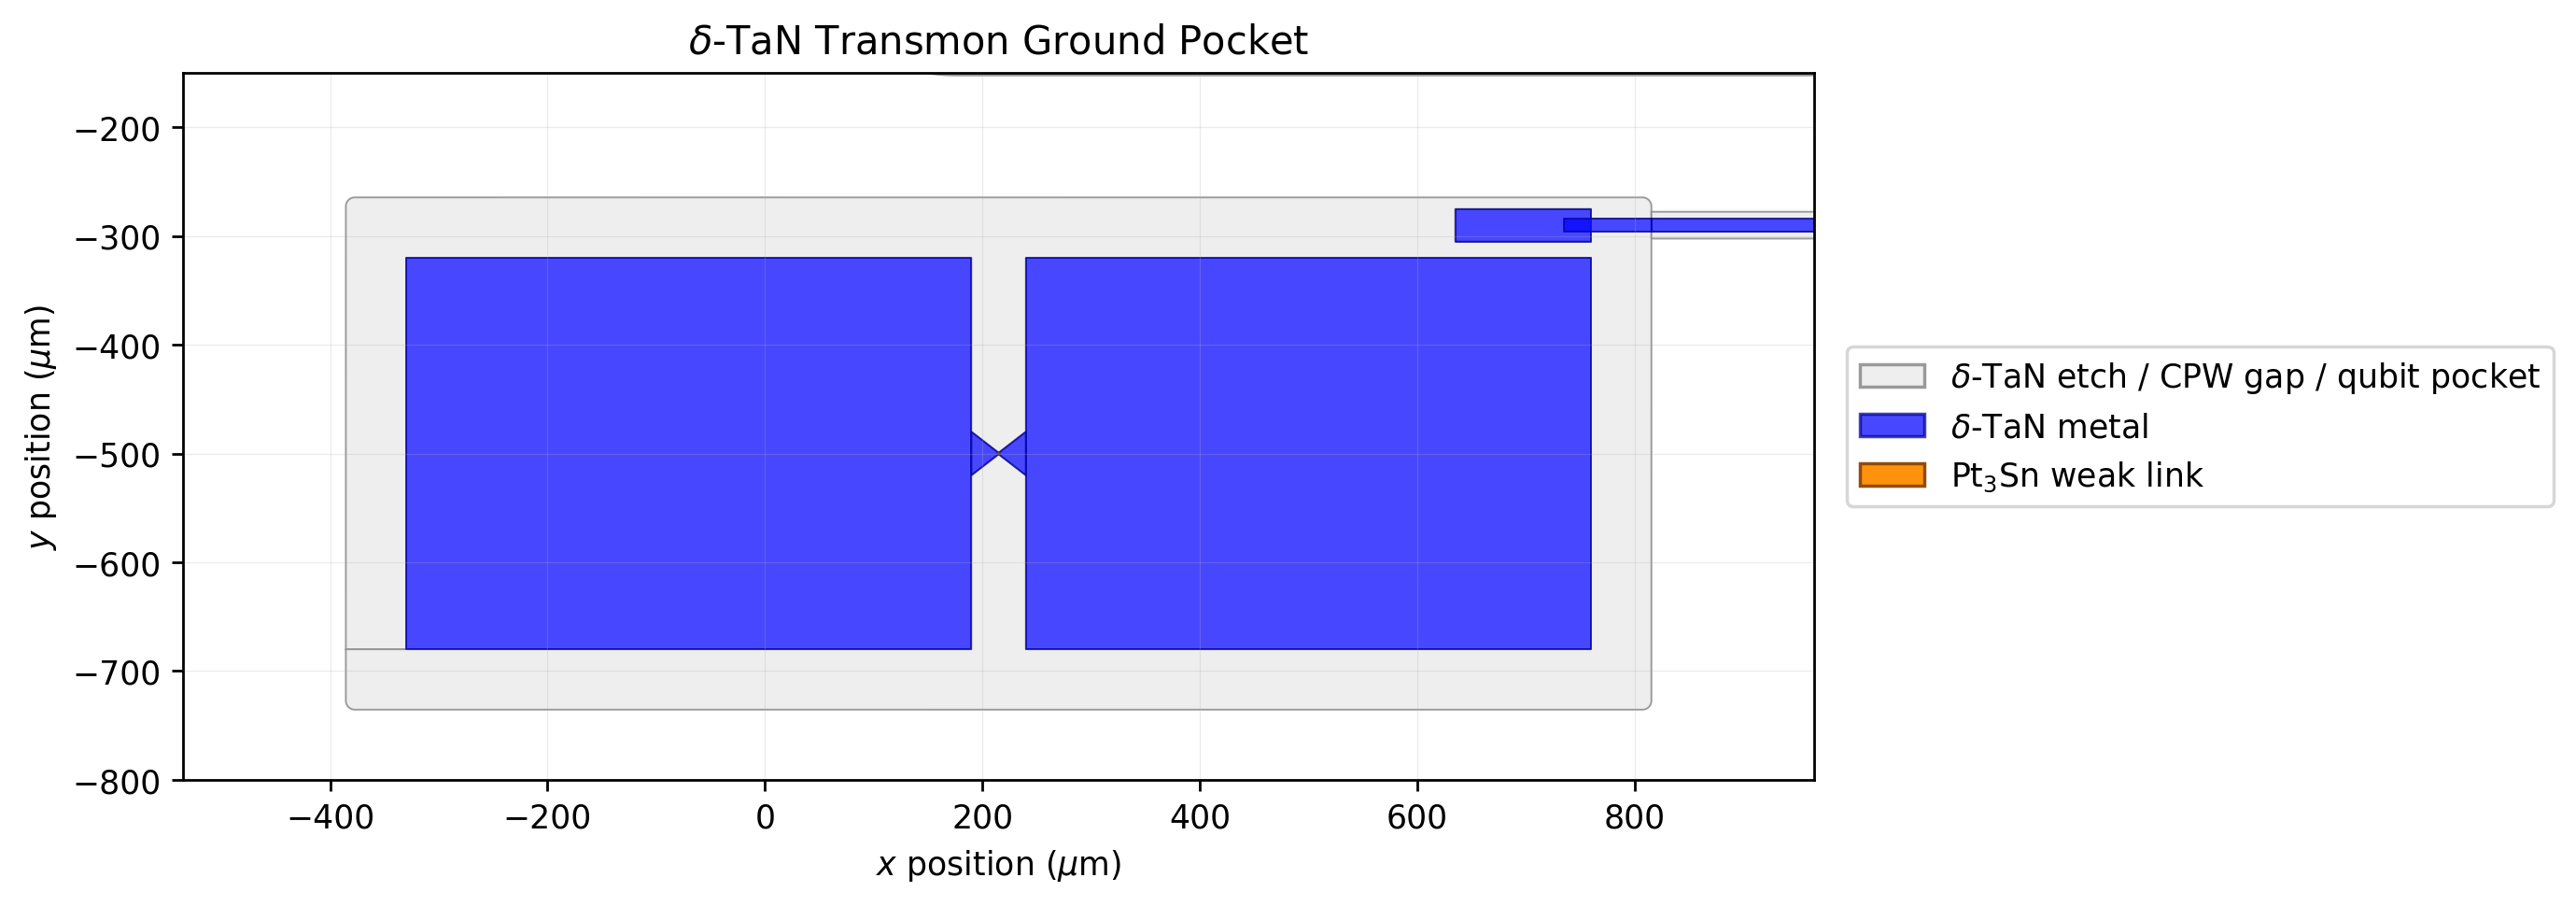

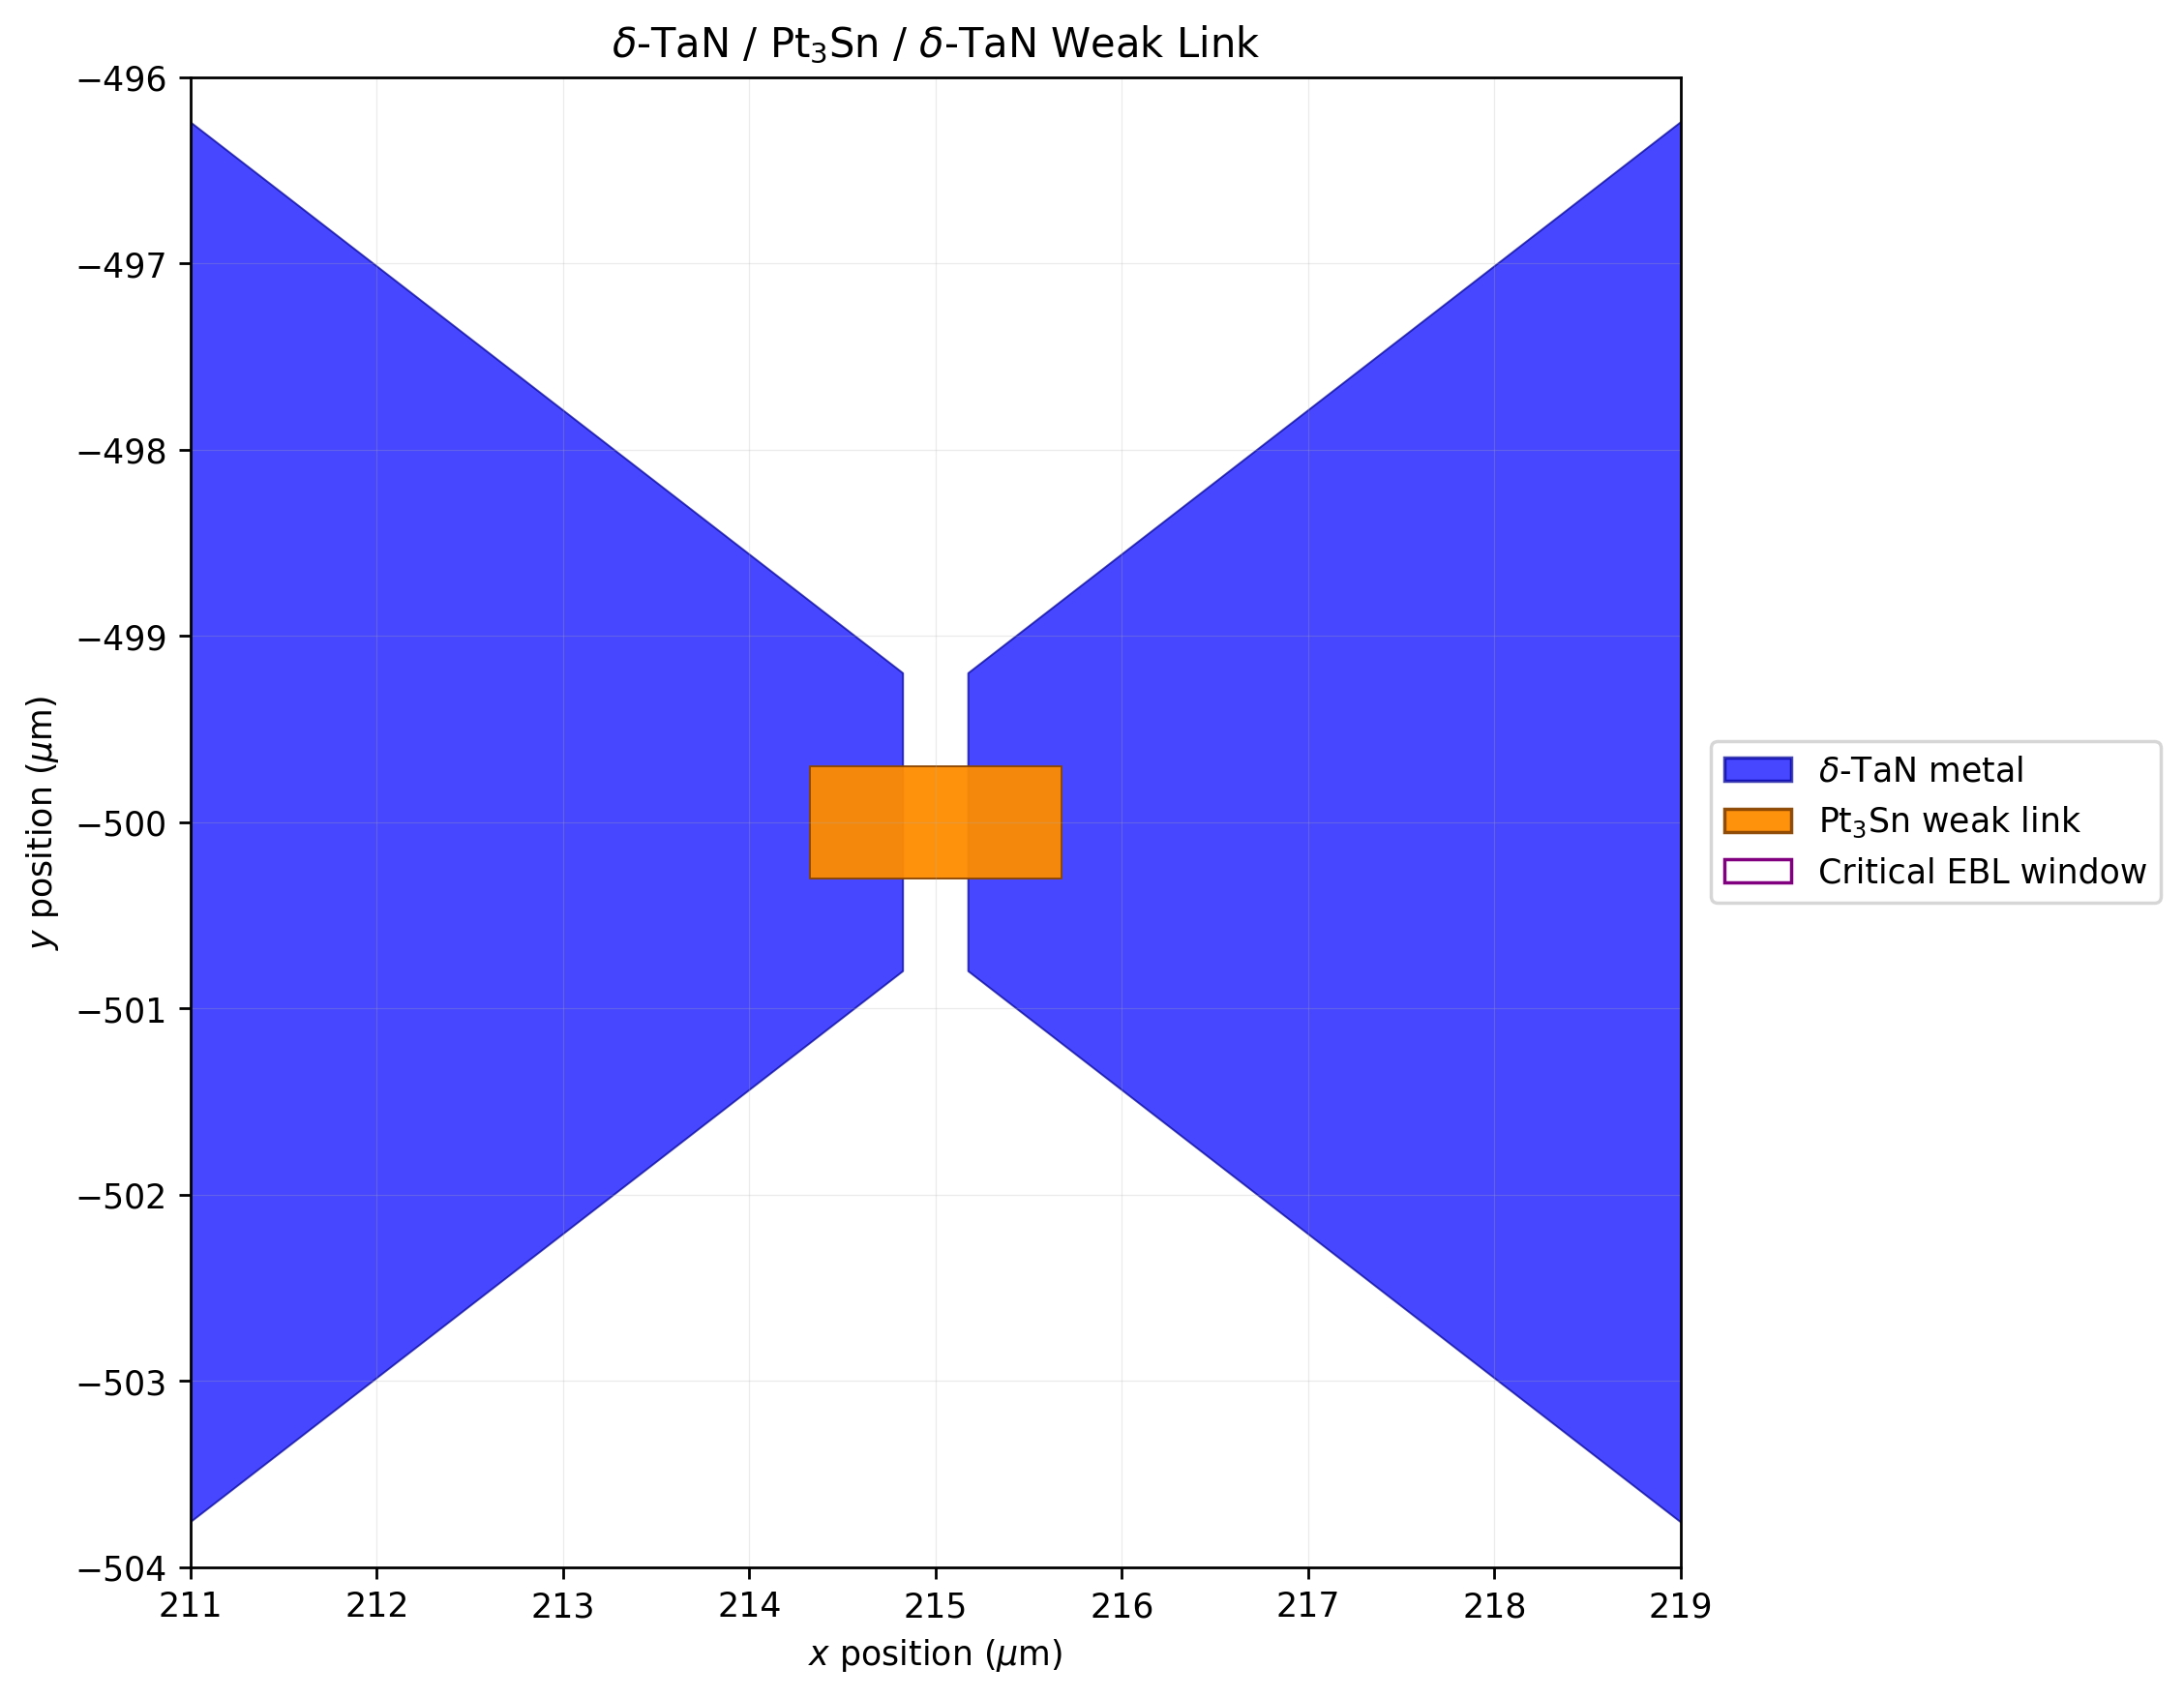

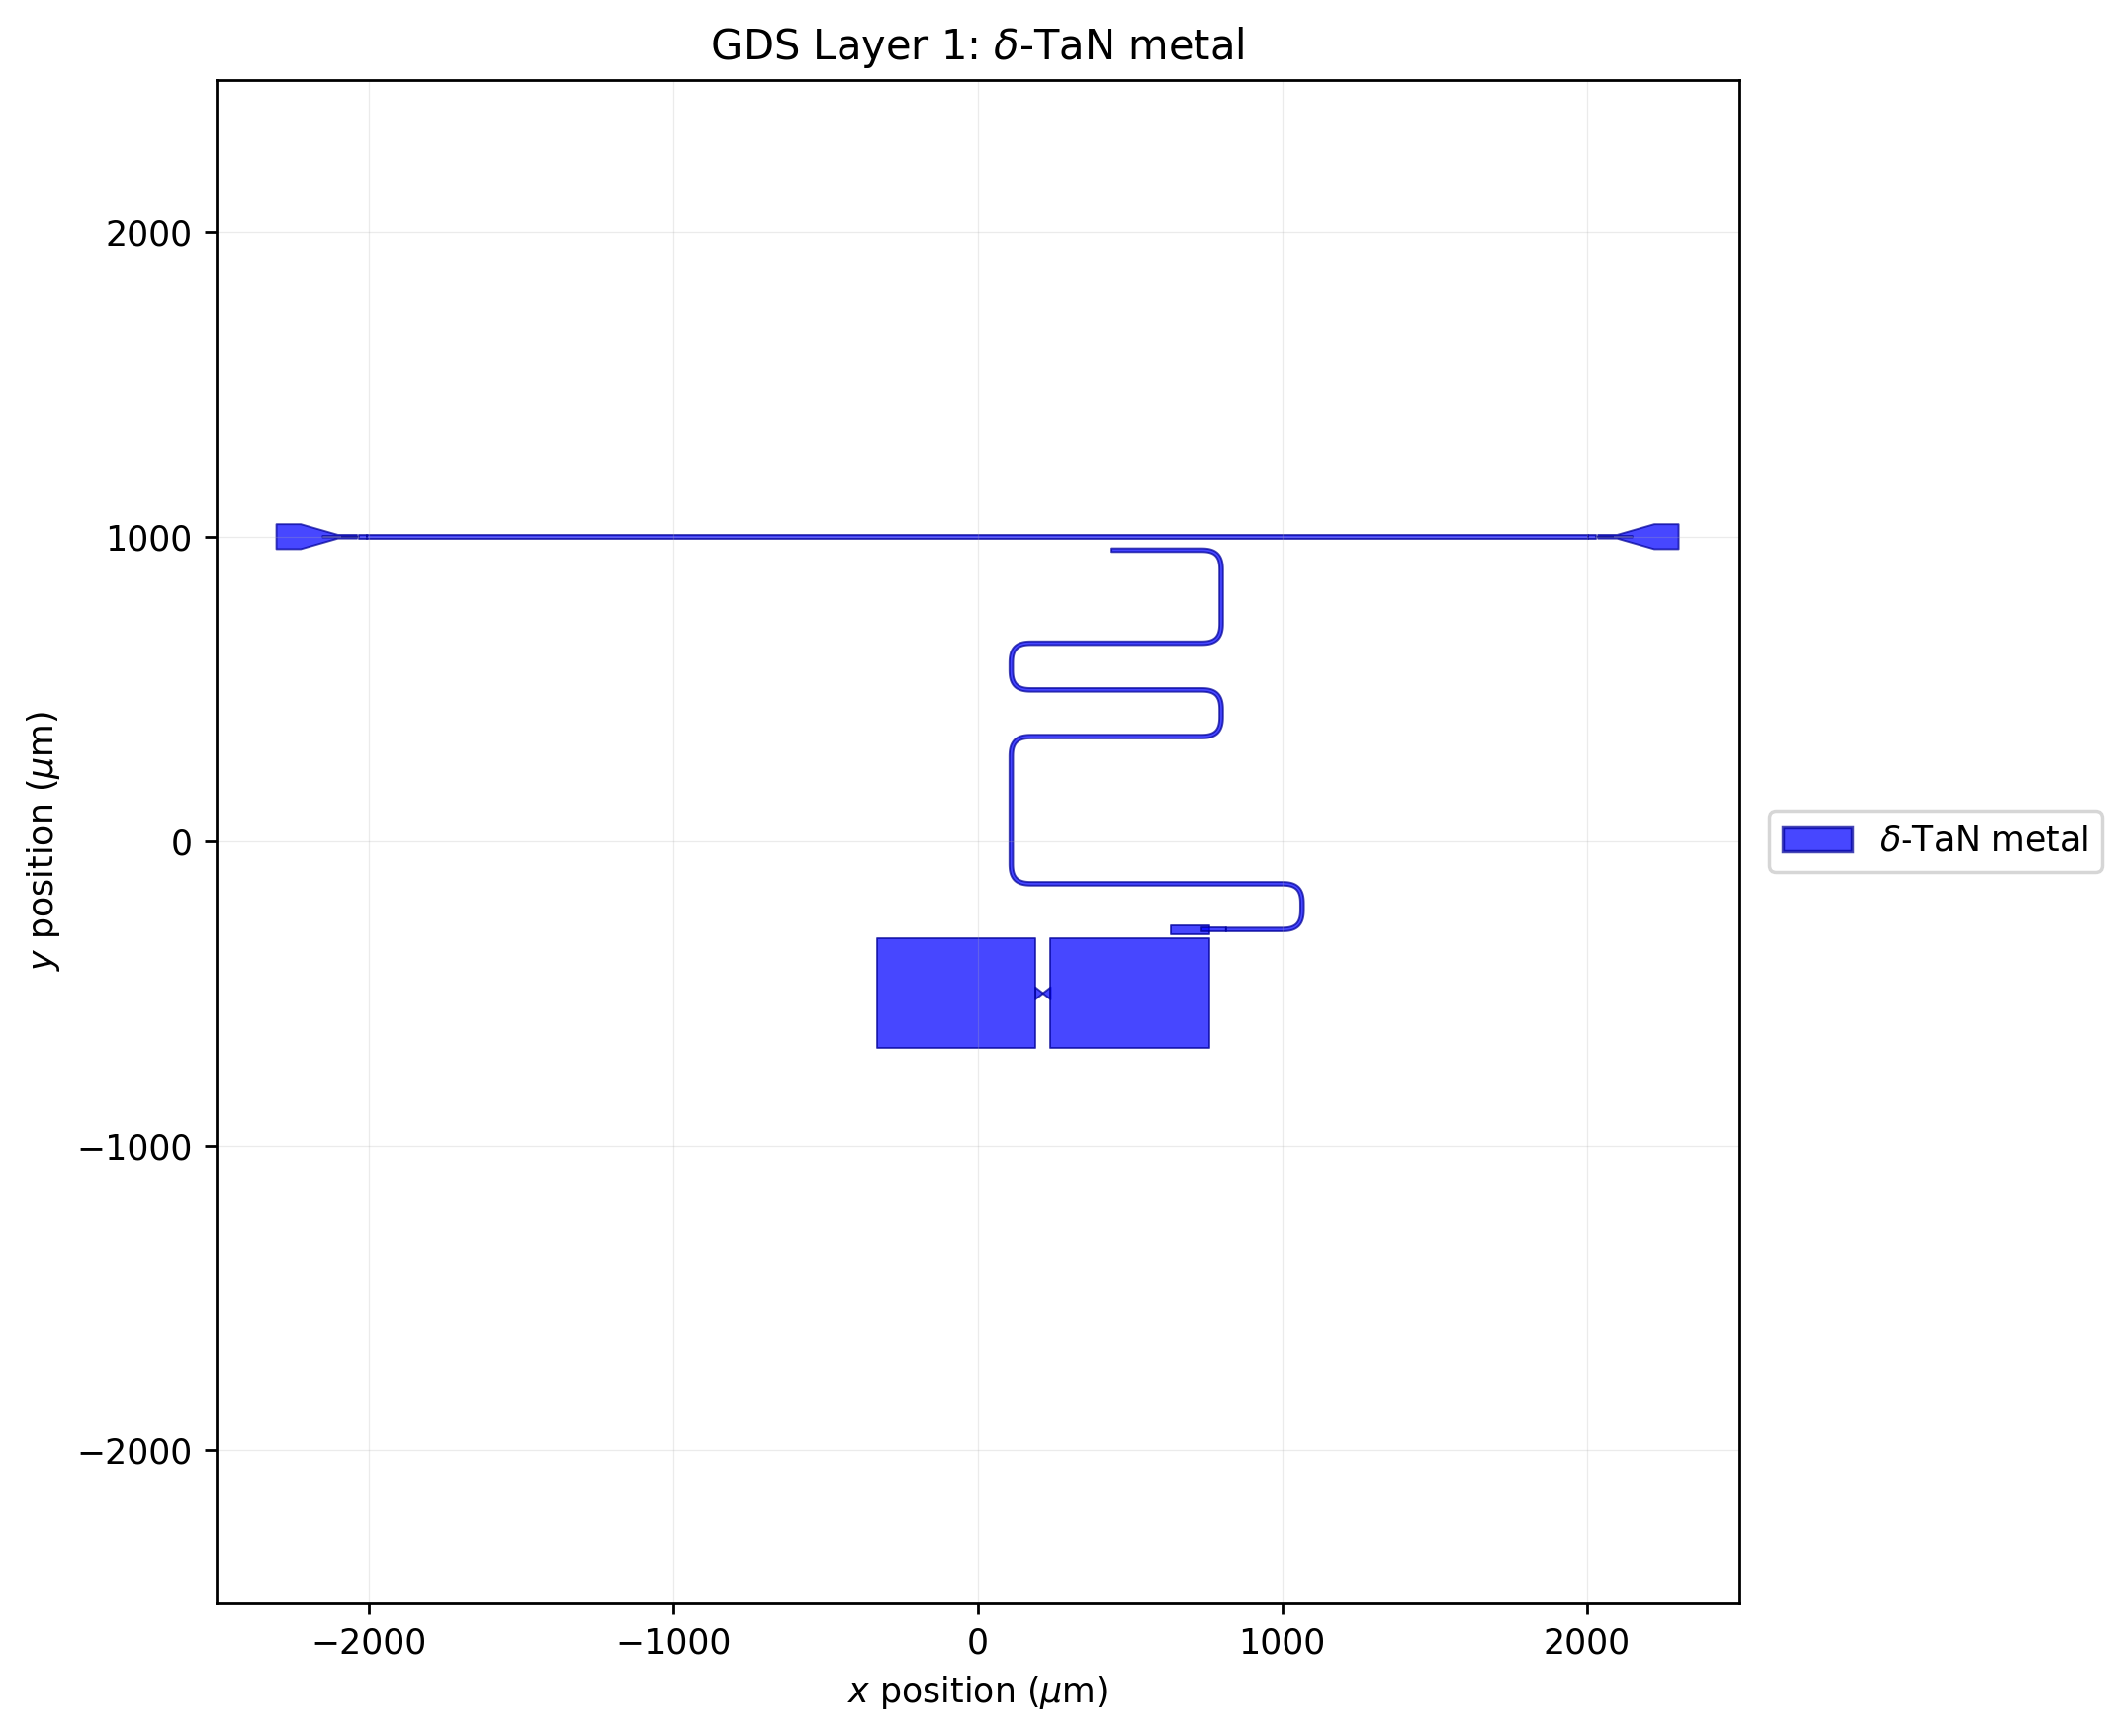

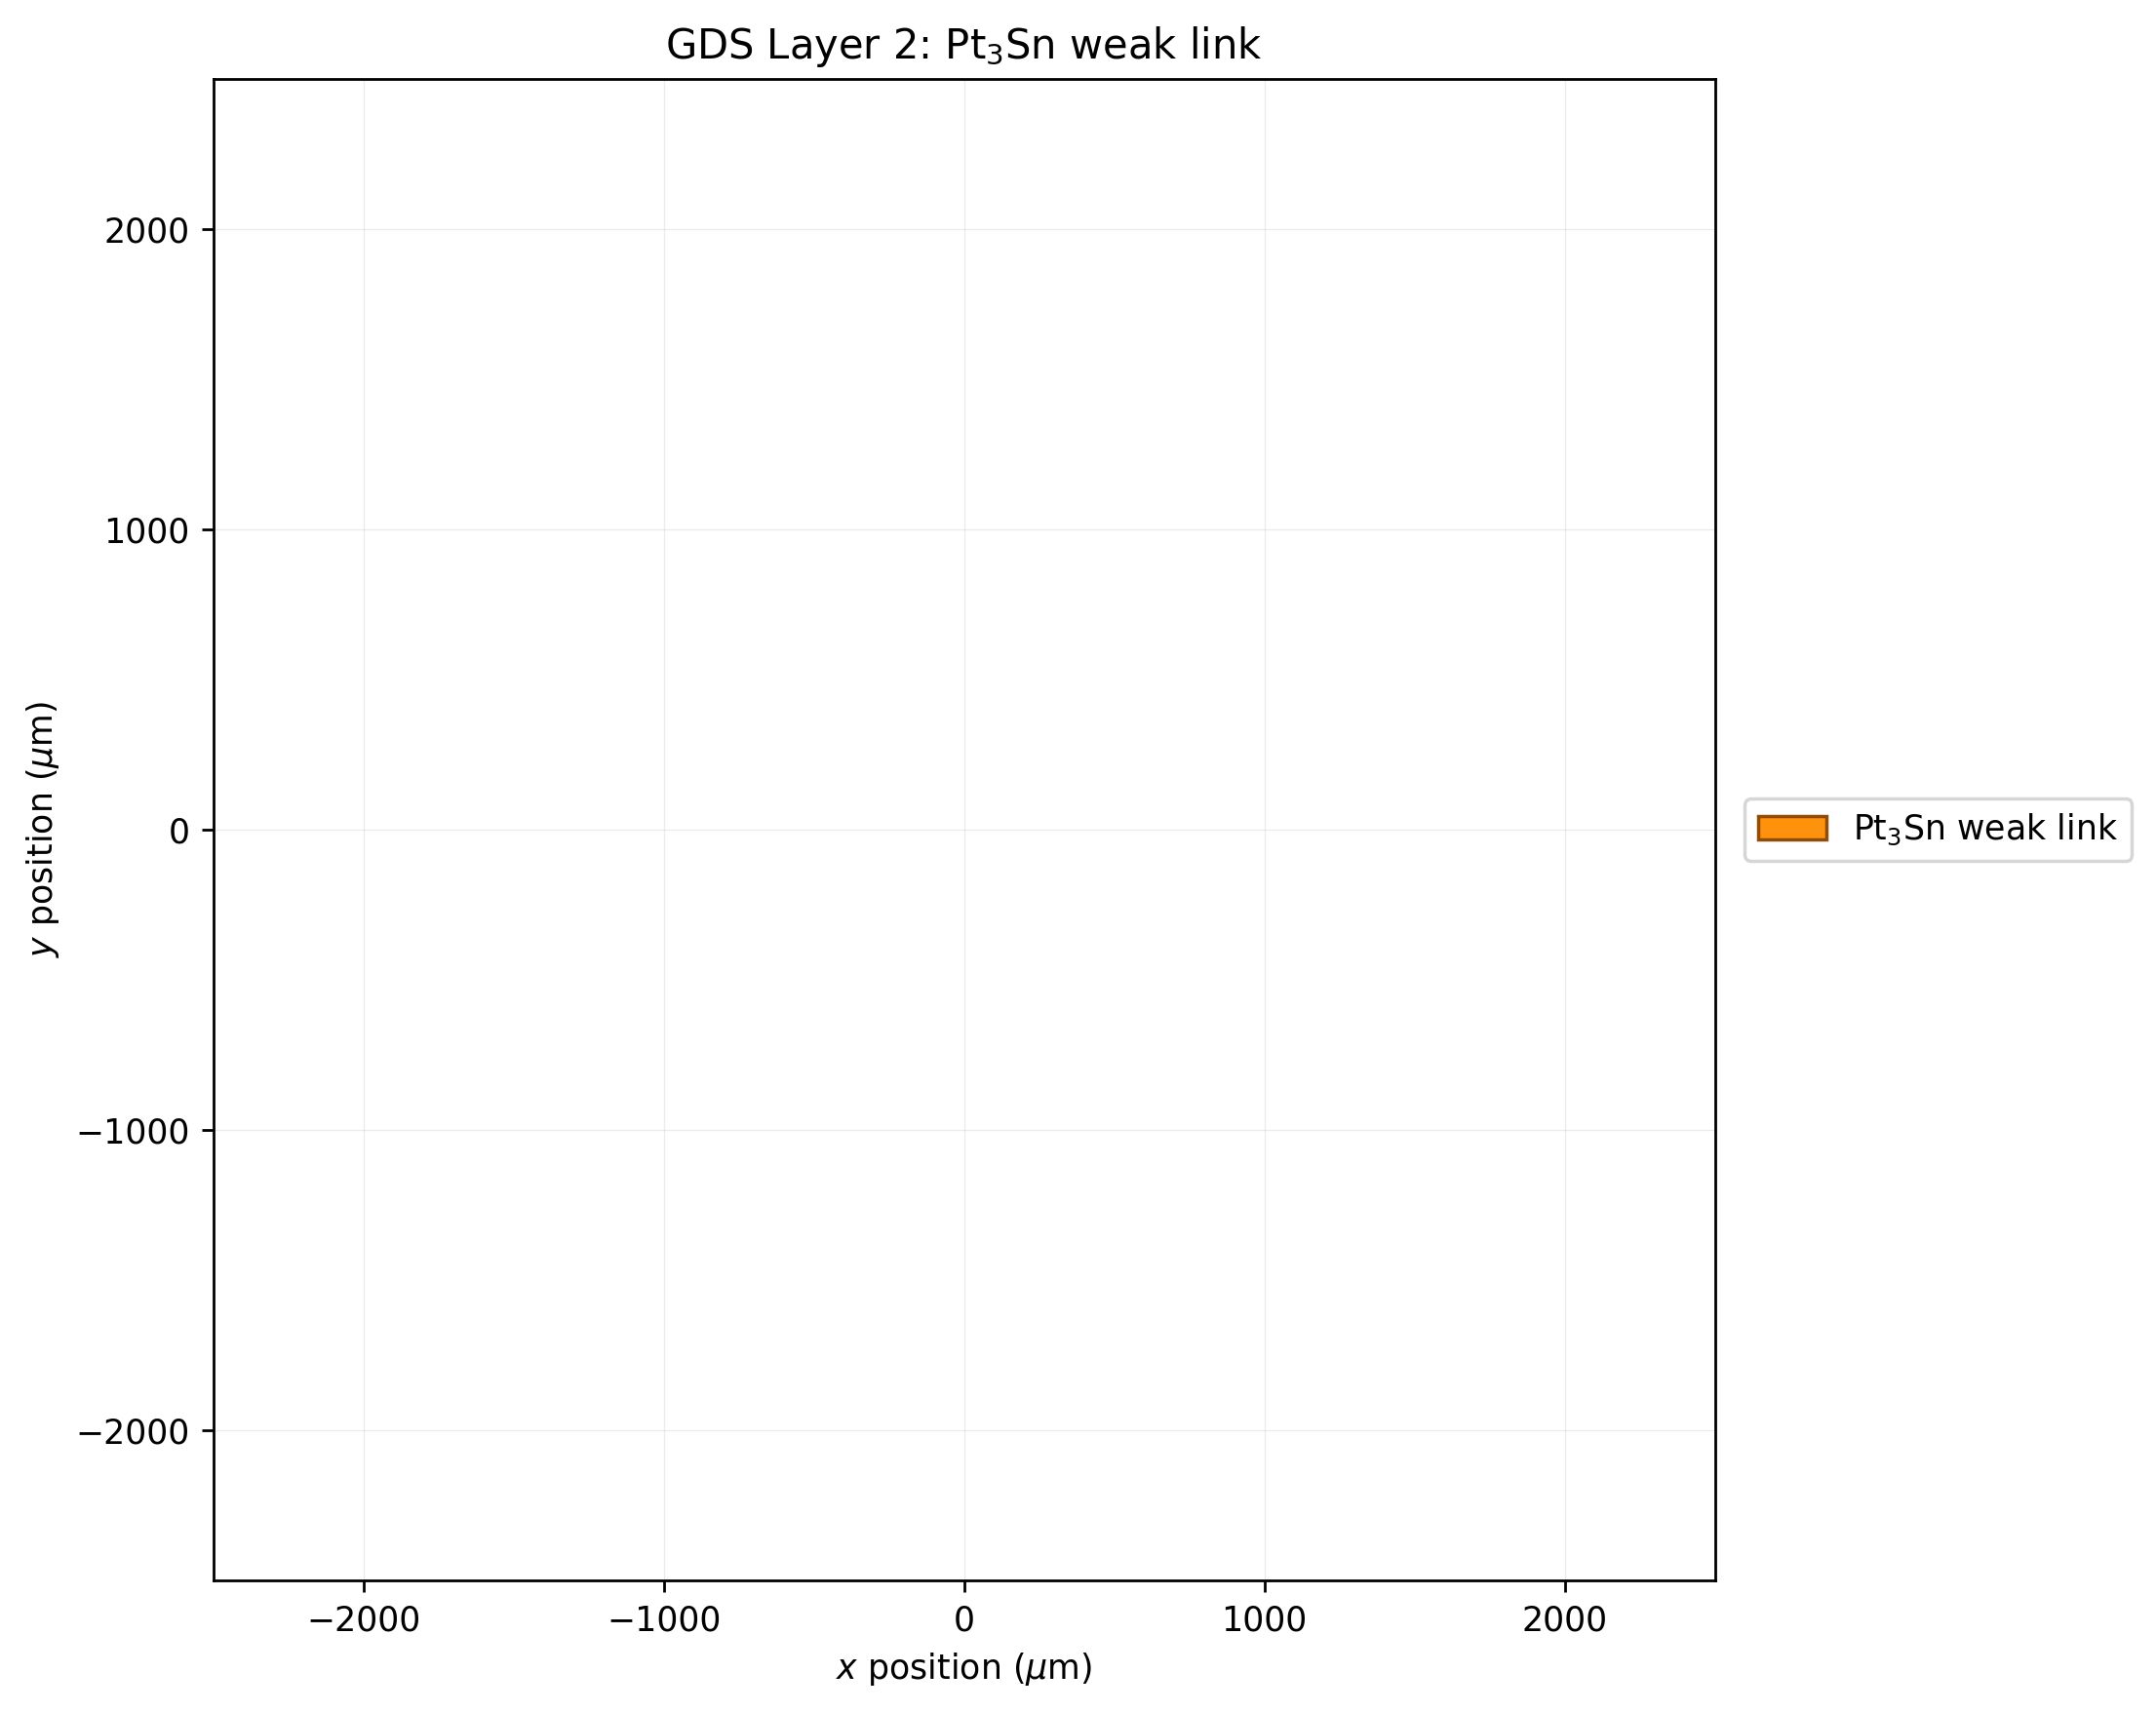

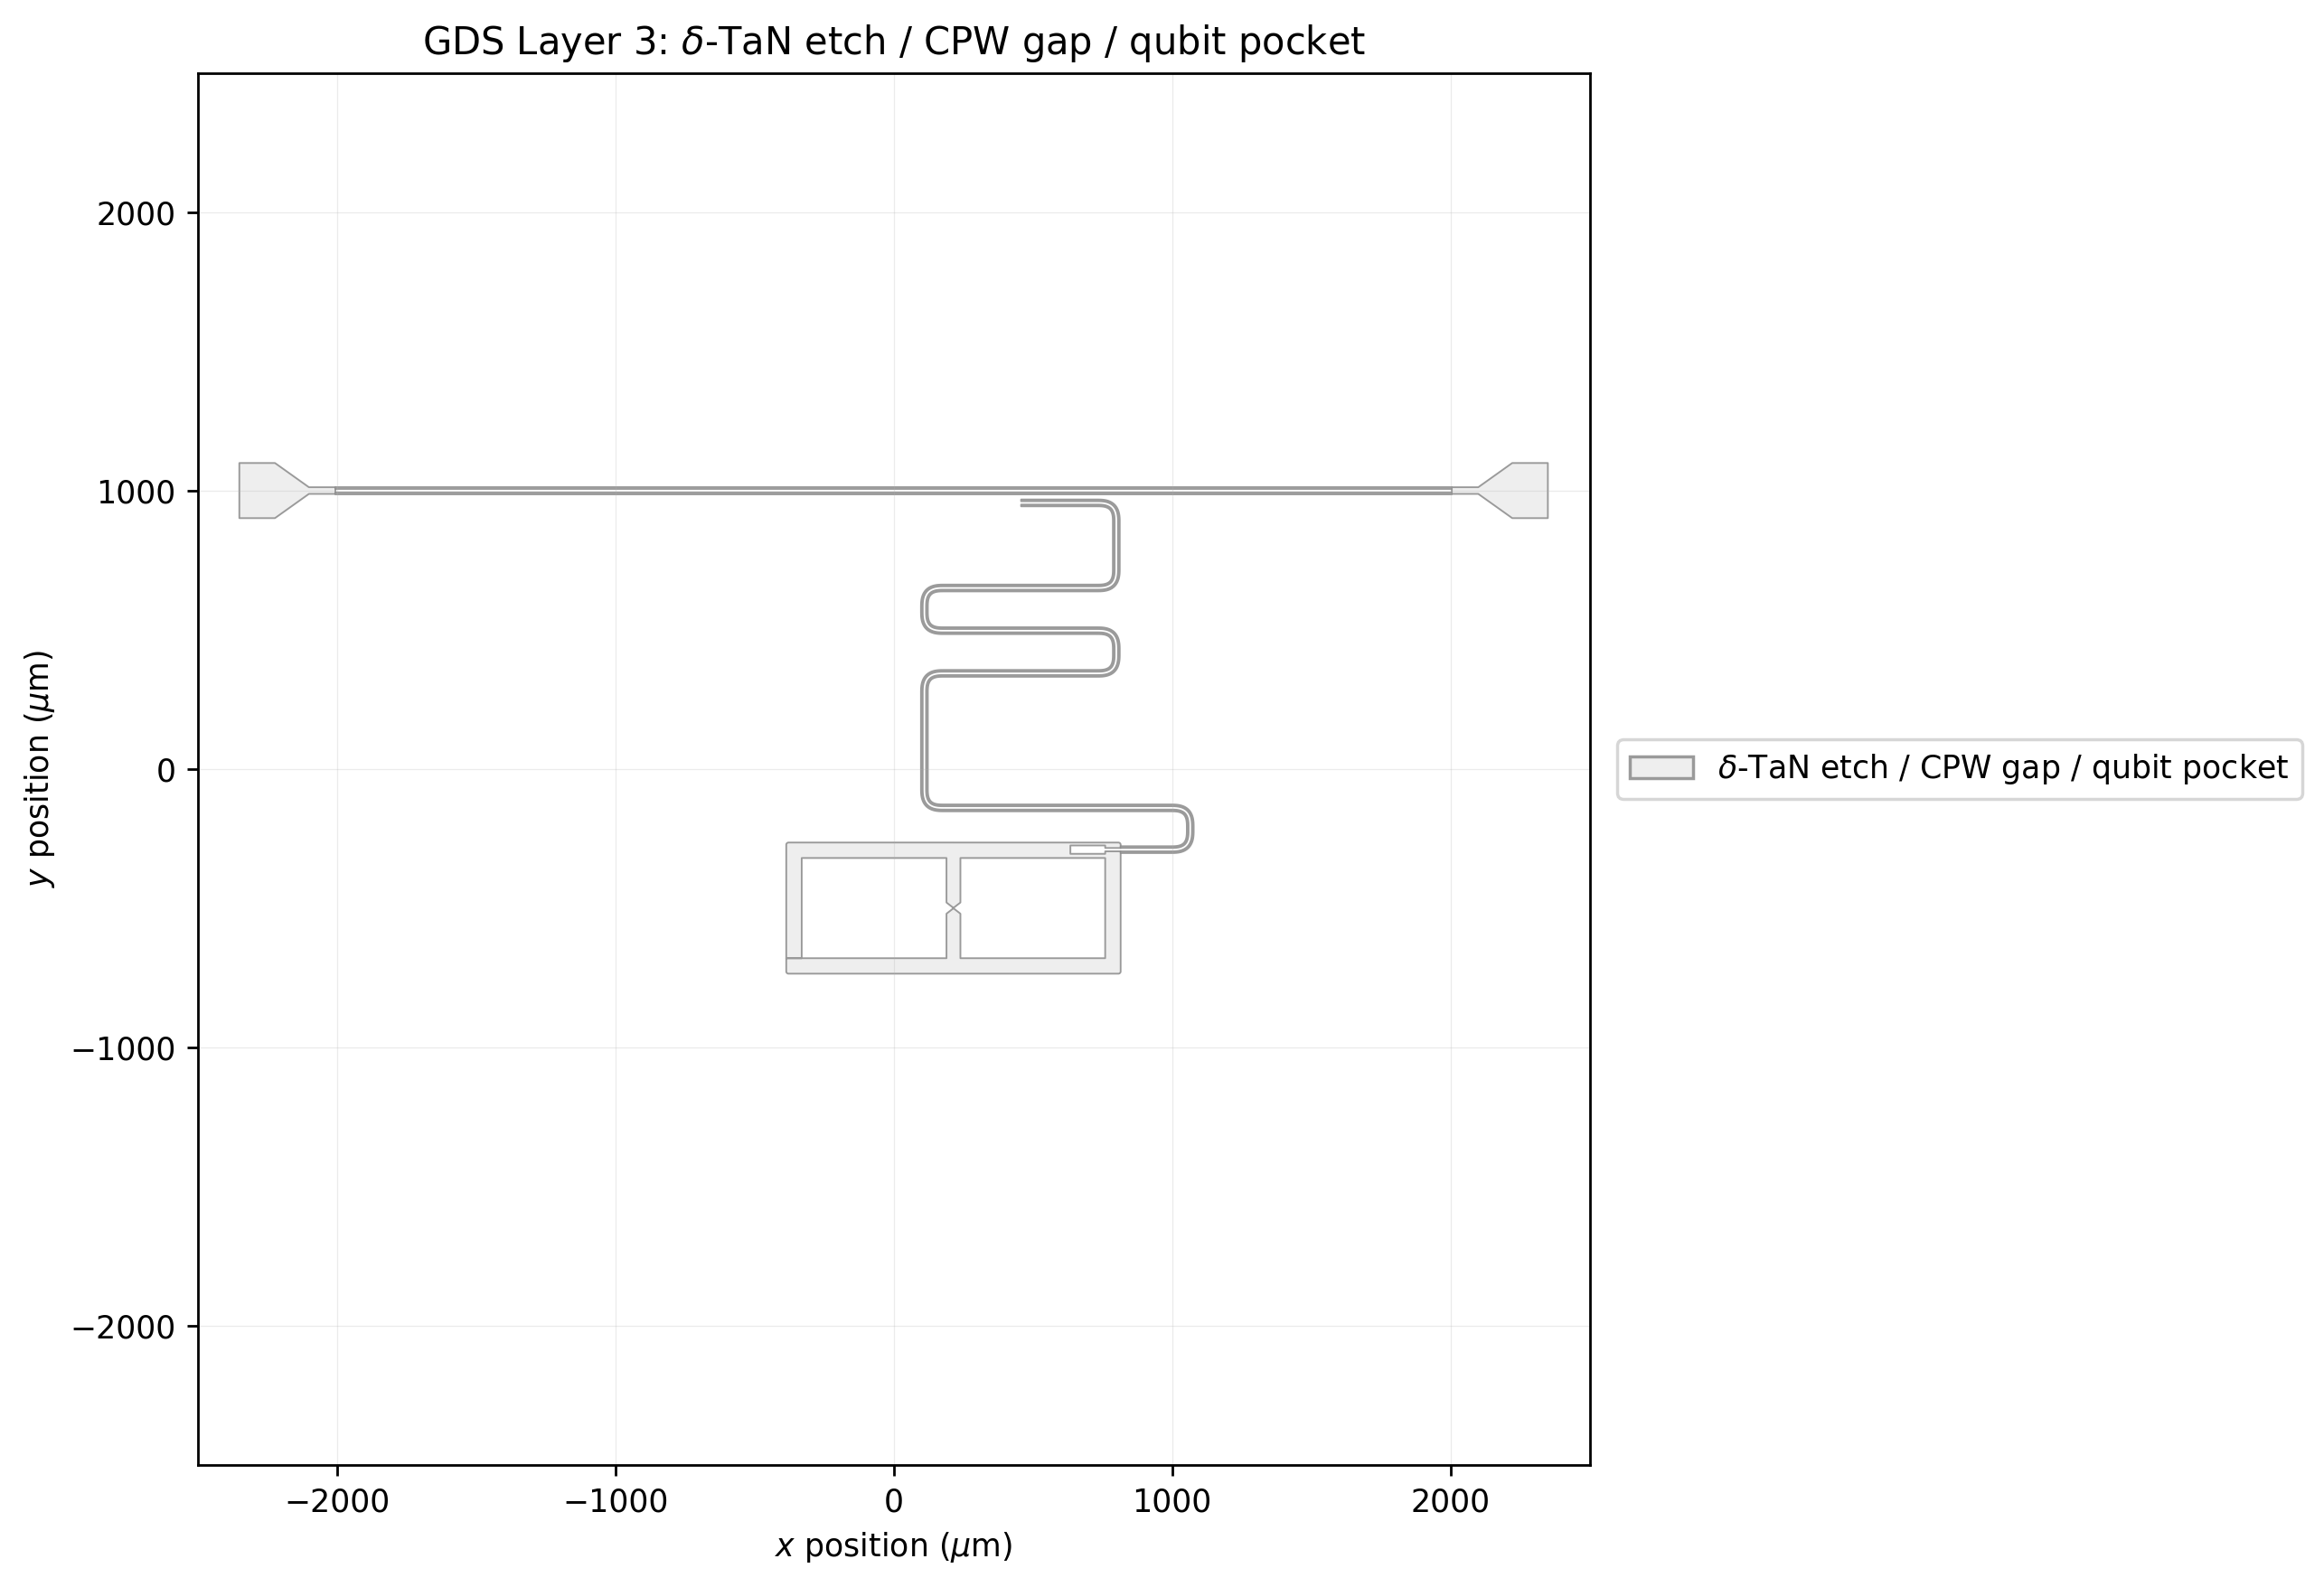

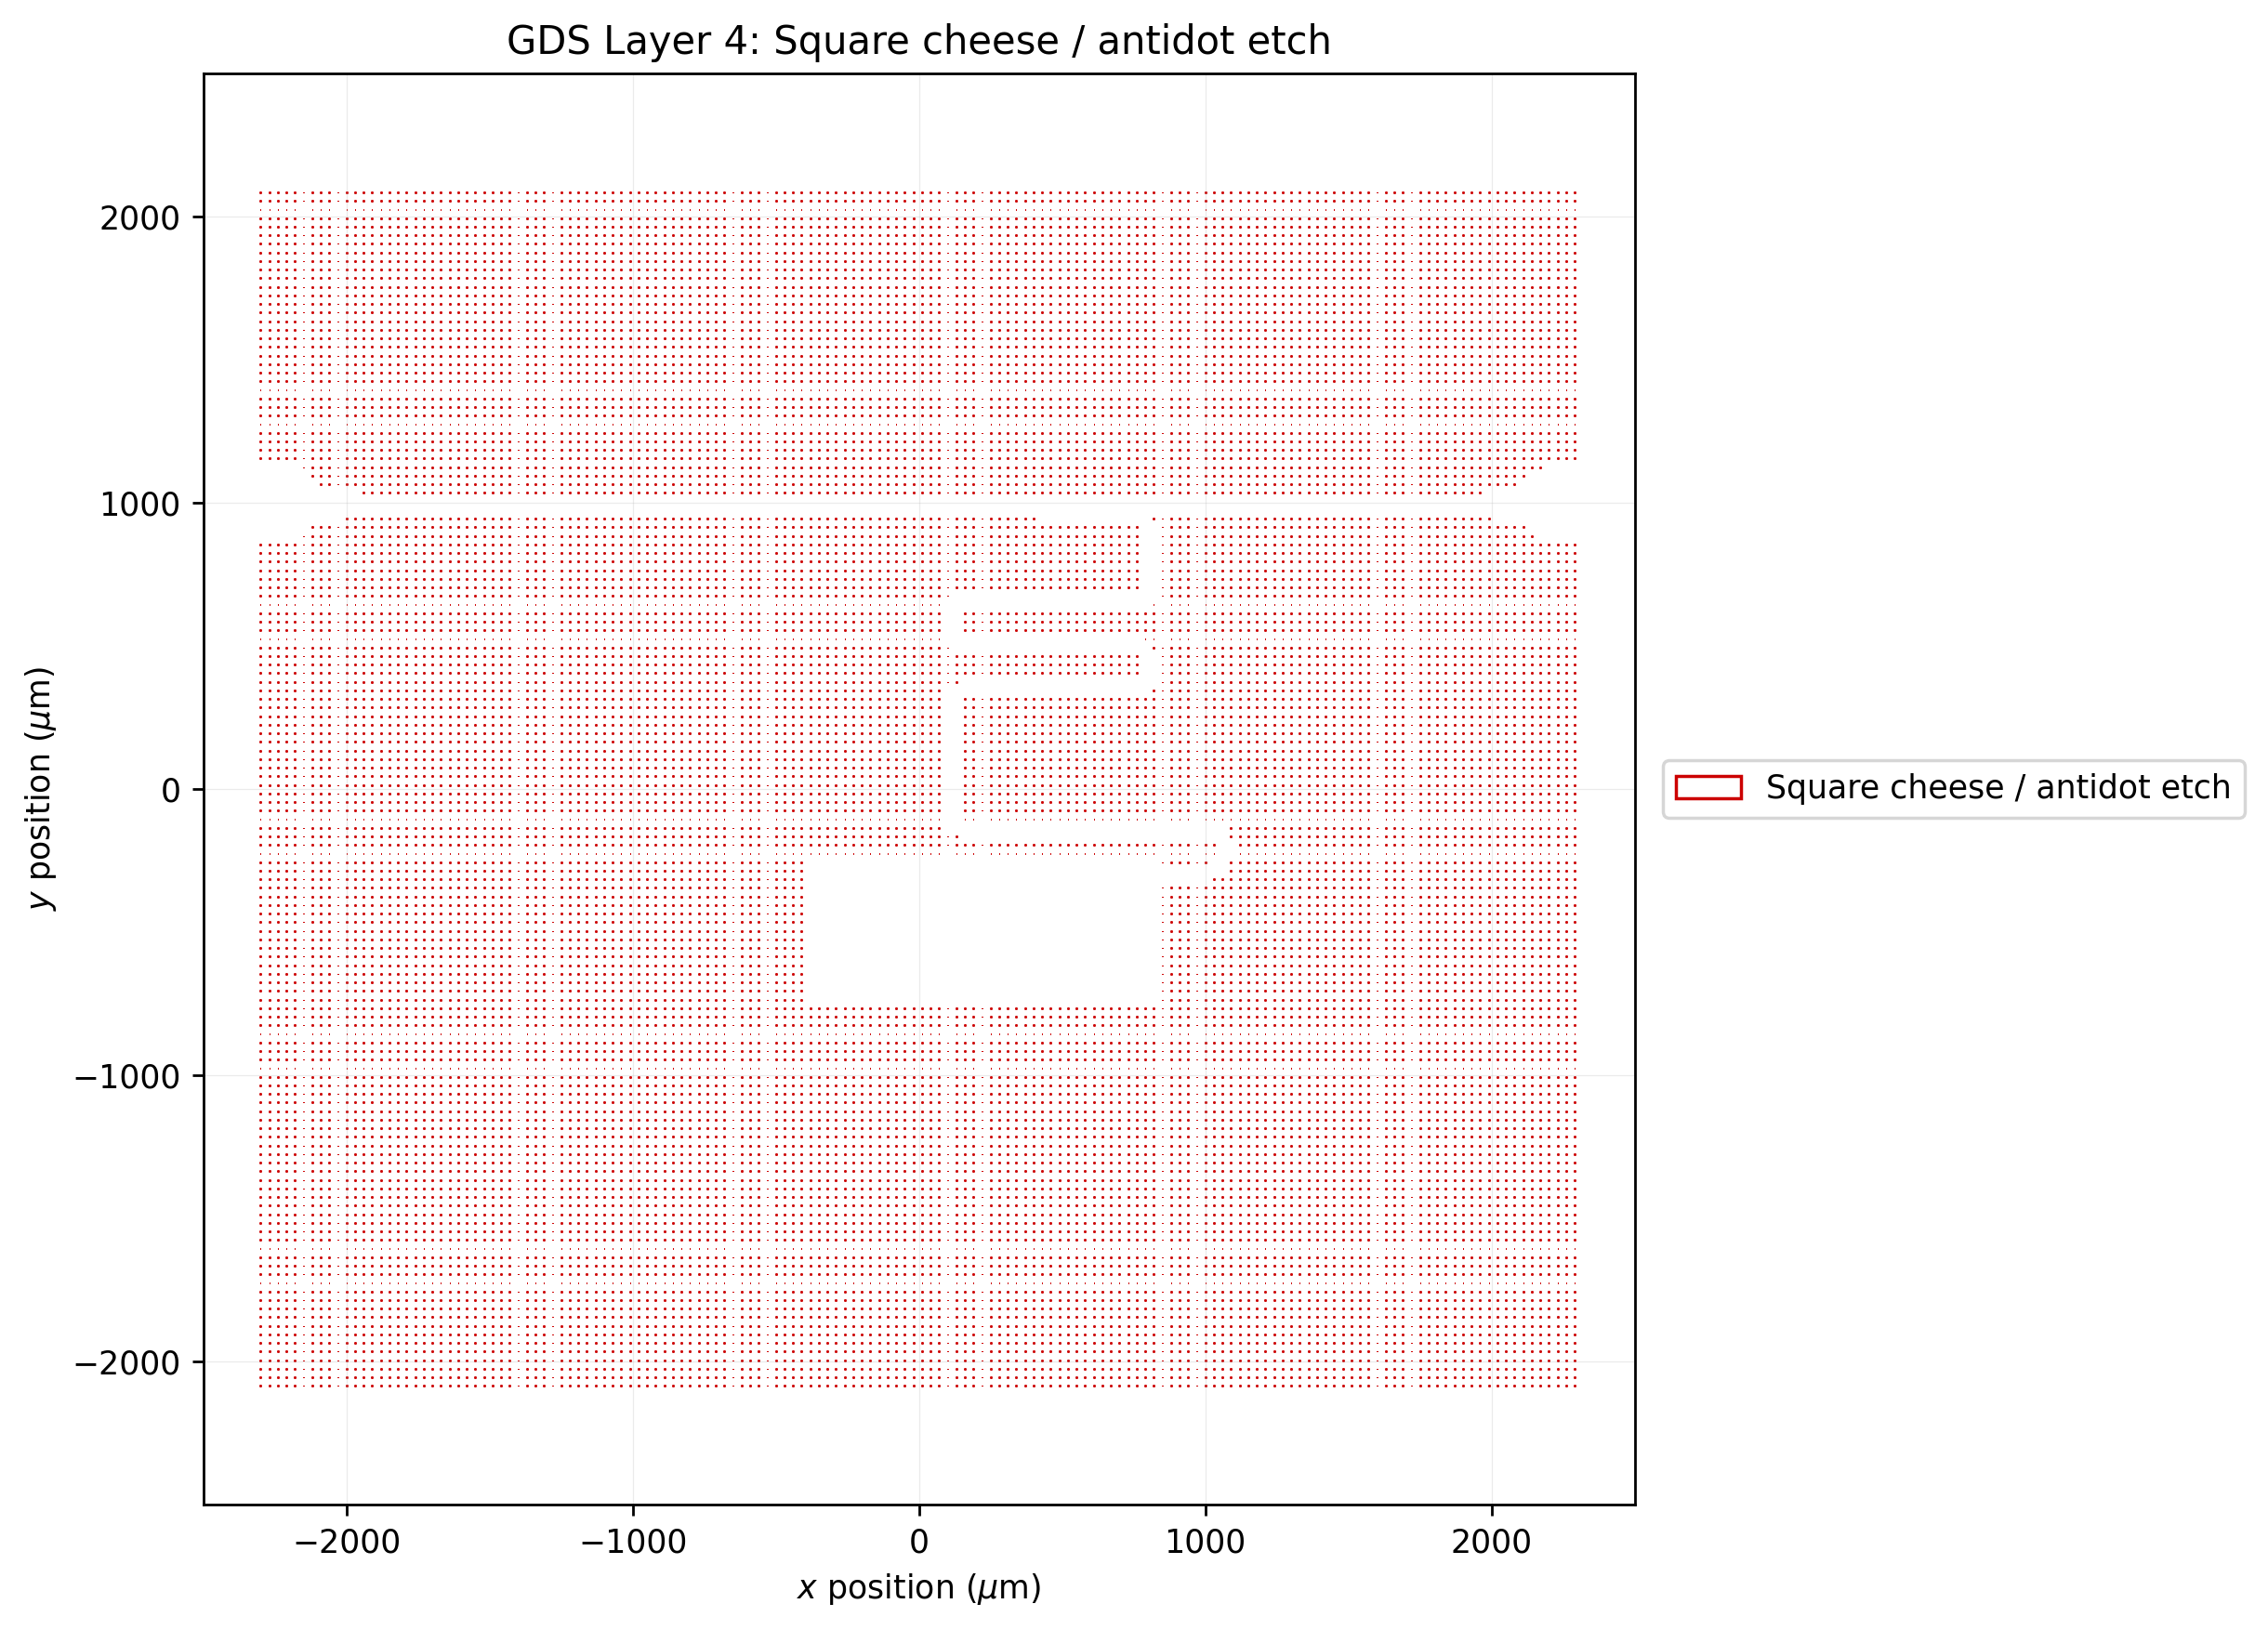

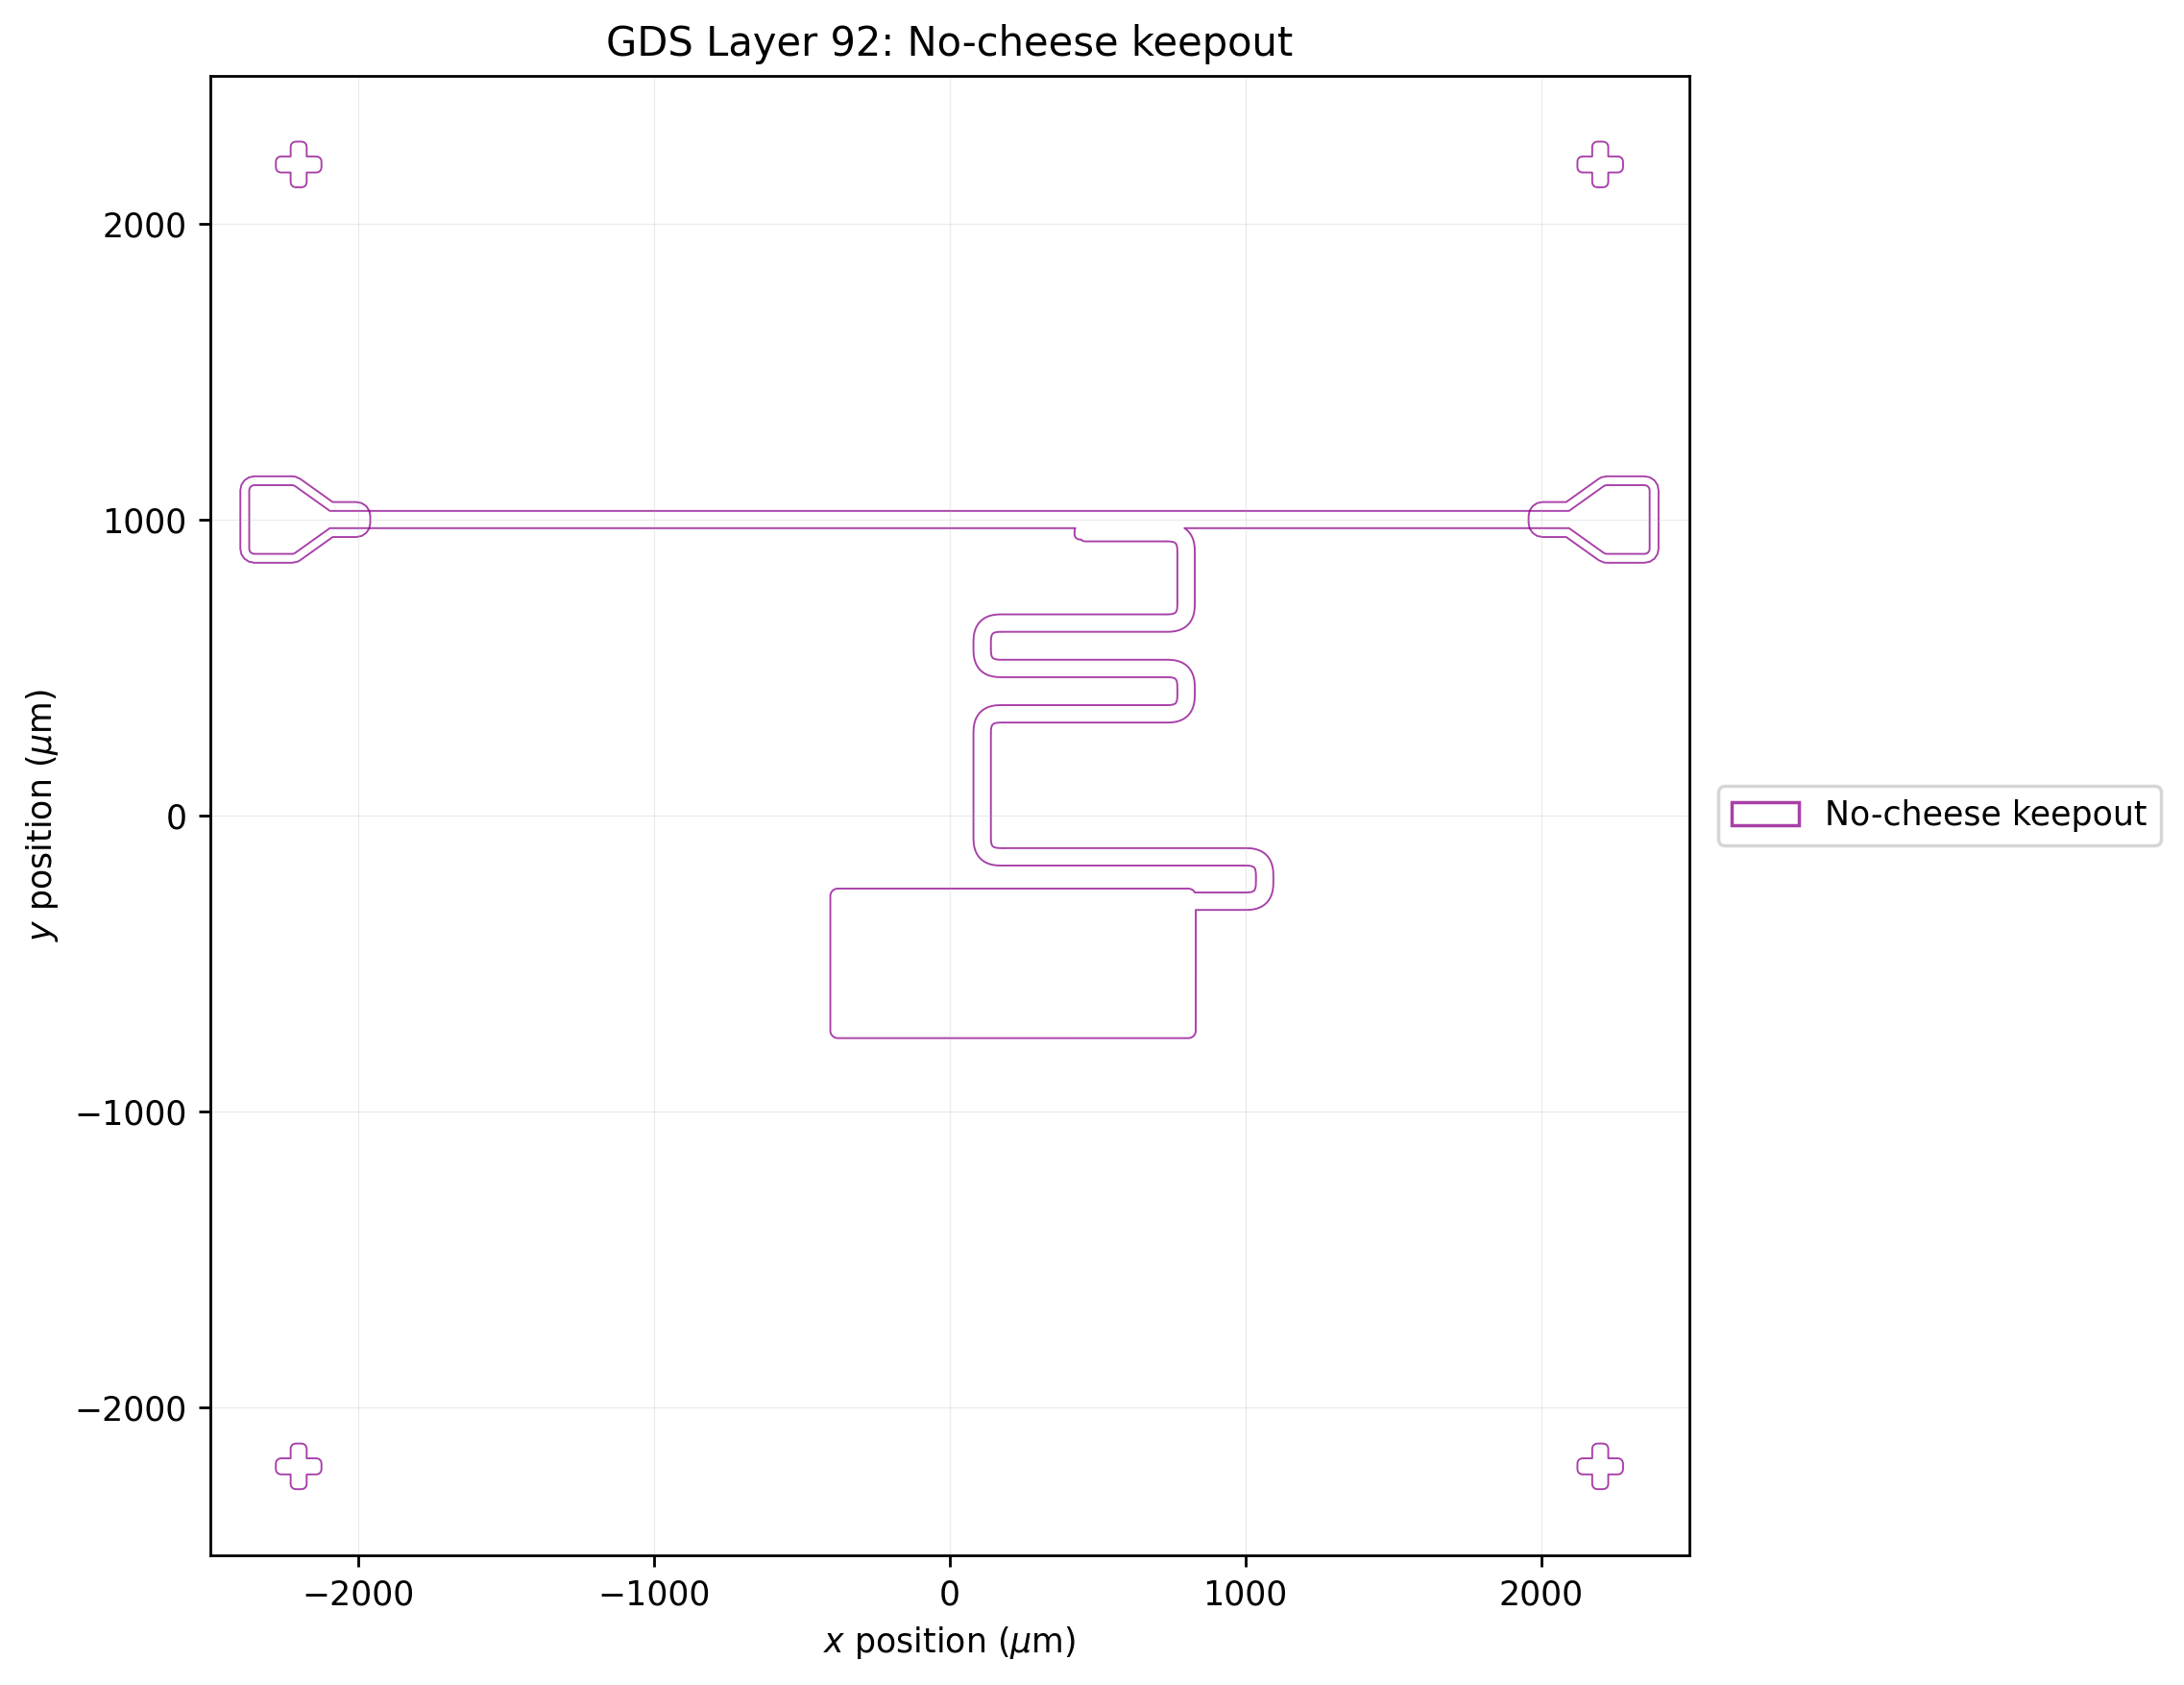

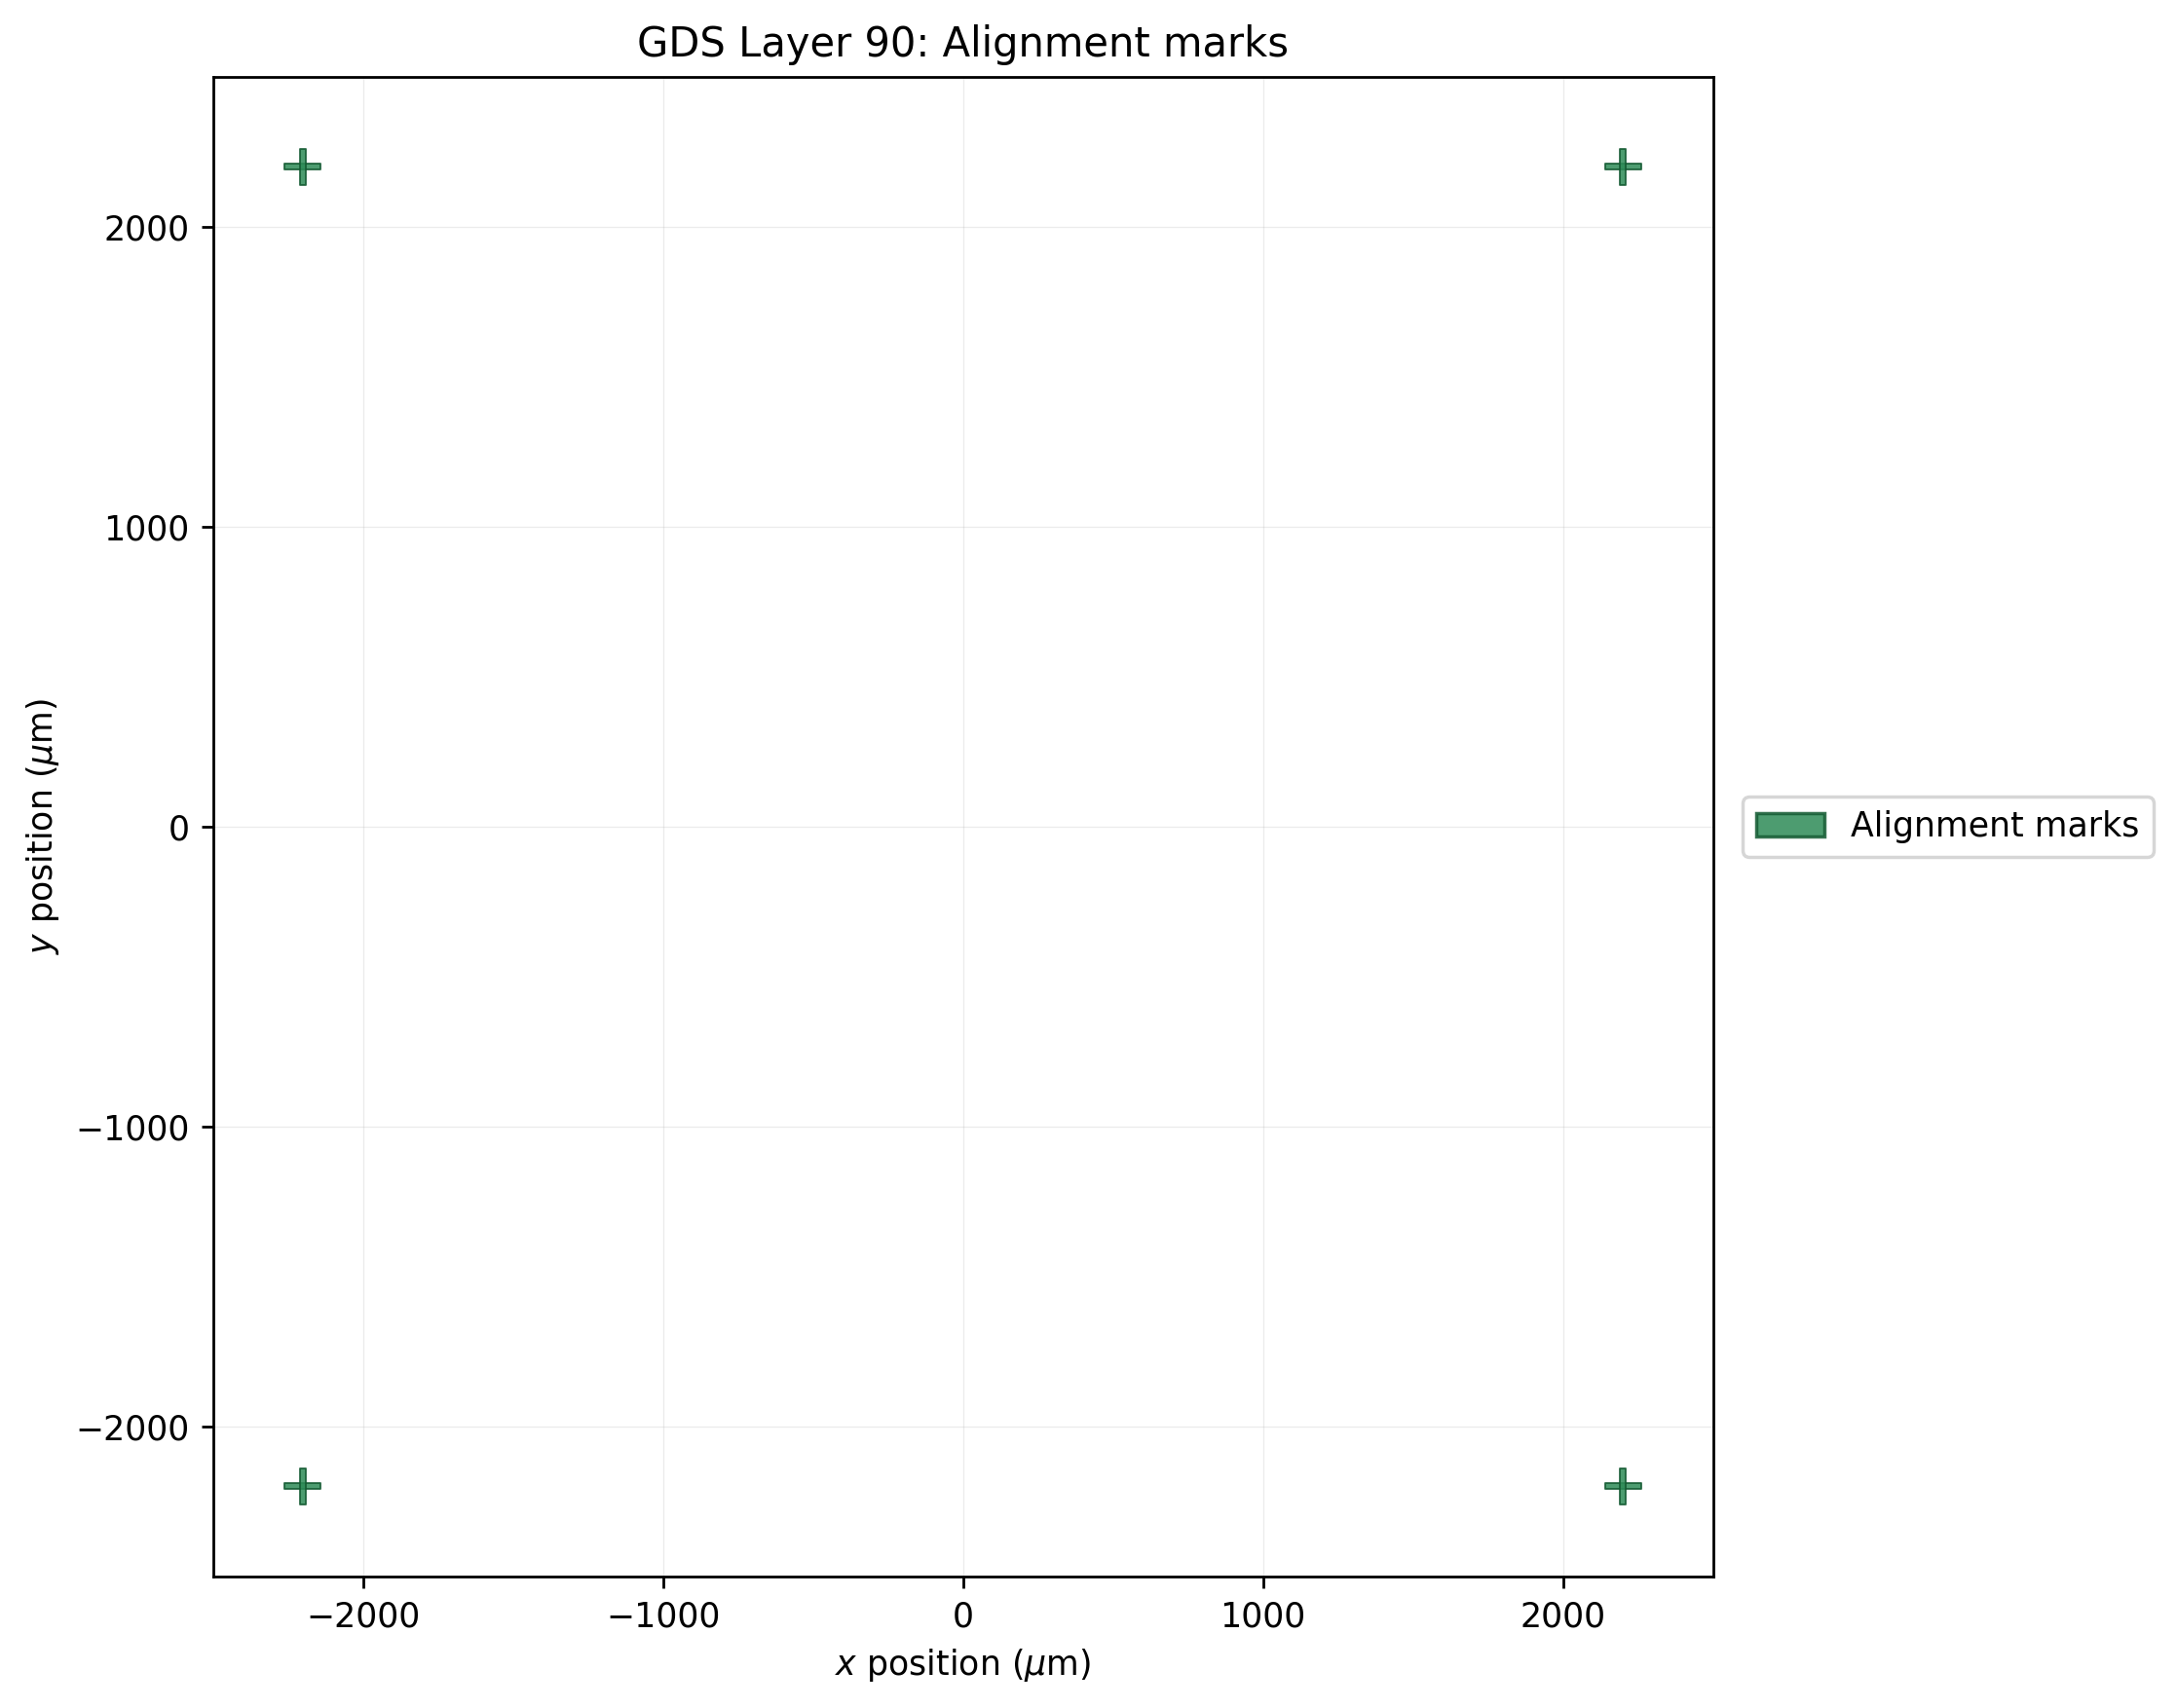


DESIGN SUMMARY
Weak-link stack:          delta-TaN / Pt3Sn / delta-TaN
Exposed junction length:  350.0 nm
Pt3Sn bridge width:       600.0 nm
Pt3Sn overlap per side:   500.0 nm
Total Pt3Sn length:       1350.0 nm

TaN transmon pocket:      enabled
Calculated pocket size:   1201.130 x 471.130 um
Symmetric pocket gap:     55.565 um
Vacuum C target:          70.000 fF
Vacuum C estimate:        70.001 fF
Vacuum-only E_C / h:      276.718 MHz
Main N/S asymmetry:       0.000 um
Resonator/pocket join err: 0.000 um
Resonator CPW slots:      stop at qubit-pocket edge
Requested pocket radius:  30.000 um
Effective pocket radius:  8.230 um

Feedline CPW:             12.0 / 6.0 um
Feedline Z0 estimate:     49.22 ohm
Launcher style:           Qiskit-Metal wirebond coupled
Launcher back length:     202.0 um
Launcher coupler length:  62.5 um
Launcher lead length:     25.0 um
Launcher inner finger:    1.0 um

Cheese hole shape:        rectangle
Cheese hole dimensions:   3.000 x 3.000 um
Cheese grid pit

In [34]:
"""Generate a microwave-aware delta-TaN/Pt3Sn transmon GDSII layout.

The script builds a research layout with PHIDL, including a delta-TaN
transmon, a Pt3Sn semimetal weak link, a smooth Euler-bend quarter-wave
CPW readout resonator, a through CPW feedline, and two Qiskit-Metal-style
wirebond launchers with ground pockets and inductive coupling fingers.
The resonator terminates at a dedicated TransmonPocket-style capacitive
readout connection pad instead of using a long direct parallel coupling section.
A chip-wide Quantum-Metal-style cheesing stage distributes square vortex-pinning
antidots across
the usable delta-TaN ground-plane area and removes holes from configurable
no-cheese regions surrounding all microwave and qubit geometries. Physical
polygons are exported with GDSTK and previewed in memory with Matplotlib.

All layout dimensions are expressed in micrometers unless stated otherwise.
"""

from dataclasses import dataclass
from importlib.metadata import PackageNotFoundError, version
import math
from pathlib import Path
from typing import Iterable, Sequence

import gdstk
import matplotlib.pyplot as plt
import numpy as np
import phidl.geometry as pg
import phidl.path as pp
from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MatplotlibPolygon
from phidl import Device

# ------------------------------------------------------------
# CONTROL KNOBS
# ------------------------------------------------------------

PLOT_DPI = 250
OUTPUT_DIRECTORY = "/content"
OUTPUT_GDS_NAME = "delta_tan_pt3sn_nanobridge_qubit.gds"
AUTO_DOWNLOAD_GDS = False
SHOW_LAYER_PREVIEWS = True
EXPORT_GUIDE_LAYERS = False
AUTO_TUNE_RESONATOR_LENGTH = True

# ------------------------------------------------------------
# GDS LAYERS
# ------------------------------------------------------------

LAYER_DELTA_TAN = 1
LAYER_PT3SN = 2
LAYER_CPW_GAP = 3
LAYER_ANTIDOT = 4
LAYER_ALIGNMENT = 90
LAYER_CRITICAL_WINDOW = 91
LAYER_CHEESE_KEEPOUT = 92
LAYER_EDGE_KEEPOUT = 98
LAYER_DIE_OUTLINE = 99

GUIDE_LAYERS = {
    LAYER_CRITICAL_WINDOW,
    LAYER_CHEESE_KEEPOUT,
    LAYER_EDGE_KEEPOUT,
    LAYER_DIE_OUTLINE,
}

LAYER_NAMES = {
    LAYER_DELTA_TAN: r"$\delta$-TaN metal",
    LAYER_PT3SN: r"Pt$_3$Sn weak link",
    LAYER_CPW_GAP: r"$\delta$-TaN etch / CPW gap / qubit pocket",
    LAYER_ANTIDOT: "Square cheese / antidot etch",
    LAYER_ALIGNMENT: "Alignment marks",
    LAYER_CRITICAL_WINDOW: "Critical EBL window",
    LAYER_CHEESE_KEEPOUT: "No-cheese keepout",
    LAYER_EDGE_KEEPOUT: "Die edge keepout",
    LAYER_DIE_OUTLINE: "Die outline",
}

LAYER_STYLES = {
    LAYER_CPW_GAP: {
        "facecolor": "#ECECEC",
        "edgecolor": "#8A8A8A",
        "alpha": 0.85,
    },
    LAYER_DELTA_TAN: {
        "facecolor": "#0000FF",
        "edgecolor": "#000099",
        "alpha": 0.72,
    },
    LAYER_ANTIDOT: {
        "facecolor": "#FFFFFF",
        "edgecolor": "#CC0000",
        "alpha": 1.0,
    },
    LAYER_PT3SN: {
        "facecolor": "#FF8C00",
        "edgecolor": "#8B4500",
        "alpha": 0.95,
    },
    LAYER_ALIGNMENT: {
        "facecolor": "#2E8B57",
        "edgecolor": "#145A32",
        "alpha": 0.85,
    },
    LAYER_CRITICAL_WINDOW: {
        "facecolor": "none",
        "edgecolor": "#800080",
        "alpha": 1.0,
    },
    LAYER_CHEESE_KEEPOUT: {
        "facecolor": "none",
        "edgecolor": "#8B008B",
        "alpha": 0.75,
    },
    LAYER_EDGE_KEEPOUT: {
        "facecolor": "none",
        "edgecolor": "#808080",
        "alpha": 1.0,
    },
    LAYER_DIE_OUTLINE: {
        "facecolor": "none",
        "edgecolor": "#222222",
        "alpha": 1.0,
    },
}

LAYER_DRAW_ORDER = [
    LAYER_CPW_GAP,
    LAYER_ANTIDOT,
    LAYER_DELTA_TAN,
    LAYER_PT3SN,
    LAYER_ALIGNMENT,
    LAYER_CRITICAL_WINDOW,
    LAYER_CHEESE_KEEPOUT,
    LAYER_EDGE_KEEPOUT,
    LAYER_DIE_OUTLINE,
]


# ------------------------------------------------------------
# RESEARCH DESIGN RULE DECK
# ------------------------------------------------------------


@dataclass(frozen=True)
class DesignRules:
    """Store conservative superconducting and microwave layout rules."""

    grid_um: float = 0.005
    gds_precision_m: float = 1e-9

    general_tan_min_width_um: float = 2.50
    critical_min_width_um: float = 0.50
    critical_min_space_um: float = 0.300

    pt3sn_min_width_um: float = 0.500
    pt3sn_min_area_um2: float = 0.500
    contact_overlap_um: float = 0.500
    contact_side_enclosure_um: float = 0.400

    cpw_min_gap_um: float = 4.00
    cpw_impedance_min_ohm: float = 45.0
    cpw_impedance_max_ohm: float = 55.0
    cpw_bend_radius_factor: float = 2.50
    cpw_parallel_free_space_um: float = 50.0

    resonator_feedline_min_ground_web_um: float = 10.0
    resonator_short_slot_closure_min_um: float = 6.0
    resonator_connection_final_straight_min_um: float = 100.0
    resonator_meander_min_ground_web_um: float = 50.0
    resonator_impedance_target_ohm: float = 50.0
    resonator_impedance_tolerance_ohm: float = 0.10
    resonator_frequency_tolerance_fraction: float = 0.03

    launcher_coupler_min_feature_um: float = 0.80
    launcher_coupler_min_gap_um: float = 1.50
    launcher_outer_finger_min_width_um: float = 2.50
    launcher_pocket_min_side_clearance_um: float = 40.0

    readout_pad_min_island_gap_um: float = 10.0
    readout_pad_min_width_um: float = 50.0
    readout_pad_min_height_um: float = 20.0
    readout_lead_min_pocket_span_um: float = 20.0
    readout_pad_max_pin_misalignment_um: float = 0.010
    readout_pad_edge_alignment_tolerance_um: float = 0.005
    readout_pad_connection_angle_tolerance_deg: float = 0.001
    readout_gap_stop_tolerance_um: float = 0.005
    readout_slot_pocket_overlap_tolerance_um2: float = 1e-6

    tan_pocket_min_clearance_um: float = 20.0
    tan_pocket_min_corner_radius_um: float = 5.0
    tan_pocket_vertical_symmetry_tolerance_um: float = 0.005
    tan_pocket_vacuum_capacitance_tolerance_ff: float = 0.02
    tan_pocket_connector_slot_margin_um: float = 10.0
    tan_pocket_connector_corner_margin_um: float = 5.0

    cheese_min_hole_dimension_um: float = 1.00
    cheese_min_ligament_um: float = 2.00
    cheese_min_default_keepout_um: float = 15.0
    cheese_min_launcher_keepout_um: float = 45.0
    cheese_min_edge_nocheese_um: float = 100.0
    cheese_min_alignment_y_offset_um: float = 25.0

    die_edge_keepout_um: float = 150.0
    min_taper_edge_angle_deg: float = 30.0


RULES = DesignRules()


# ------------------------------------------------------------
# CHIP GEOMETRY
# ------------------------------------------------------------

CHIP_WIDTH_UM = 5000.0
CHIP_HEIGHT_UM = 5000.0

ALIGNMENT_MARK_OFFSET_UM = 300.0
ALIGNMENT_MARK_LENGTH_UM = 120.0
ALIGNMENT_MARK_WIDTH_UM = 20.0

CRITICAL_WINDOW_WIDTH_UM = 10.0
CRITICAL_WINDOW_HEIGHT_UM = 10.0


# ------------------------------------------------------------
# TRANSMON CAPACITOR AND WEAK LINK
# ------------------------------------------------------------

# The qubit is shifted right so the center of its right capacitor paddle
# aligns with the center of the resonator's near-qubit coupling segment.
QUBIT_CENTER_X_UM = 215.0
QUBIT_CENTER_Y_UM = -500.0

PAD_WIDTH_UM = 520.0
PAD_HEIGHT_UM = 360.0
PAD_GAP_UM = 50.0

ELECTRODE_WIDE_WIDTH_UM = 40.0
ELECTRODE_TIP_WIDTH_UM = 1.60

JUNCTION_LENGTH_UM = 0.350
PT3SN_CONTACT_OVERLAP_UM = 0.500
PT3SN_WEAK_LINK_WIDTH_UM = 0.600


# ------------------------------------------------------------
# DELTA-TaN TRANSMON GROUND POCKET
# ------------------------------------------------------------

INCLUDE_TAN_TRANSMON_POCKET = True

# Automatically size the symmetric pocket from a first-order vacuum coplanar
# capacitance estimate for the two delta-TaN capacitor paddles.
AUTO_SIZE_TAN_POCKET_FROM_VACUUM_CAPACITANCE = True

# This is the vacuum-only shunt-capacitance design target used to determine the
# main pocket clearance. Substrate and package dielectric loading require an
# electrostatic or full-wave extraction before fabrication.
TARGET_VACUUM_SHUNT_CAPACITANCE_FF = 70.0

TAN_POCKET_CLEARANCE_MANUAL_UM = 60.0
TAN_POCKET_CLEARANCE_SEARCH_MIN_UM = 20.0
TAN_POCKET_CLEARANCE_SEARCH_MAX_UM = 250.0
TAN_POCKET_CLEARANCE_SOLVER_ITERATIONS = 80

# Requested corner radius. The final radius is automatically limited so
# the horizontal connector CPW clears the rounded upper-right corner.
TAN_POCKET_CORNER_RADIUS_UM = 30.0
AUTO_LIMIT_TAN_POCKET_CORNER_RADIUS = True
TAN_POCKET_CORNER_POINTS = 18

VACUUM_PERMITTIVITY_F_PER_M = 8.8541878128e-12
ELEMENTARY_CHARGE_C = 1.602176634e-19
PLANCK_CONSTANT_J_S = 6.62607015e-34


# ------------------------------------------------------------
# MICROWAVE CPW FEEDLINE
# ------------------------------------------------------------

CPW_EFFECTIVE_EPSILON = 6.0

FEEDLINE_Y_UM = 1000.0
FEEDLINE_CENTER_WIDTH_UM = 12.0
FEEDLINE_GAP_UM = 6.0

# Qiskit-Metal-style LaunchpadWirebondCoupled dimensions. The fixed values
# below are the original component dimensions converted from millimeters to
# micrometers. The trace width and trace gap follow this design's CPW knobs.
LAUNCHER_BACK_LENGTH_UM = 202.0
LAUNCHER_NECK_LENGTH_UM = 122.0
LAUNCHER_PAD_EXTRA_HALF_WIDTH_UM = 35.0
LAUNCHER_POCKET_BACK_LENGTH_UM = 250.0
LAUNCHER_POCKET_EXTRA_HALF_HEIGHT_UM = 87.0
LAUNCHER_INNER_FINGER_WIDTH_UM = 1.0
LAUNCHER_INNER_FINGER_OFFSET_UM = 15.0
LAUNCHER_FINGER_SIDE_GAP_UM = 2.0
LAUNCHER_OUTER_FINGER_TIP_GAP_UM = 7.5
LAUNCHER_INNER_FINGER_BASE_TIP_GAP_UM = 50.0
LAUNCHER_COUPLER_LENGTH_UM = 62.5
LAUNCHER_LEAD_LENGTH_UM = 25.0



# ------------------------------------------------------------
# CHIP-WIDE QUANTUM-METAL-STYLE CHEESING / ANTIDOTS
# ------------------------------------------------------------

# The implementation follows the Qiskit Metal Cheesing concept:
#
#   1. Define a usable chip-wide cheesing window.
#   2. Generate one periodic hole grid across that window.
#   3. Build no-cheese regions from the existing chip geometry.
#   4. Dilate those regions by a configurable safety clearance.
#   5. Remove every candidate whose full hole footprint would intersect
#      a no-cheese region.
#
# CHEESE_SHAPE follows the Qiskit Metal convention:
#   0 = rectangular hole
#   1 = circular hole
INCLUDE_CHIP_CHEESING = True
SHOW_CHEESE_KEEPOUT_GUIDE = True

CHEESE_SHAPE = 0

# Tiny square cheesing holes. These are the default fabrication geometry.
CHEESE_SHAPE_0_X_UM = 3.0
CHEESE_SHAPE_0_Y_UM = 3.0

# Retained only so CHEESE_SHAPE can be switched to 1 later if desired.
CHEESE_SHAPE_1_RADIUS_UM = 1.5
CHEESE_CIRCLE_POINTS = 16

# Hole center-to-center spacing. Qiskit Metal calls these delta_x and delta_y.
CHEESE_DELTA_X_UM = 30.0
CHEESE_DELTA_Y_UM = 30.0

# Keep the cheesing pattern away from the chip perimeter in X.
CHEESE_EDGE_NOCHEESE_UM = 200.0

# Limit the Y coverage using the four corner alignment markers. The upper
# cheese field stops this distance below the inner edge of the upper marker
# pair. The lower field starts the same distance above the inner edge of the
# lower marker pair.
CHEESE_ALIGNMENT_Y_OFFSET_UM = 50.0

# The supplied Quantum Metal example uses separate no-cheese distances for
# ordinary subtractive geometry and launchpad pockets. The complete square
# footprint is added internally, so these values are true edge-to-edge
# clearances from the antidot squares.
CHEESE_DEFAULT_KEEPOUT_UM = 15.0
CHEESE_LAUNCHER_KEEPOUT_UM = 45.0

# These physical layers define automatic no-cheese geometry. CPW slot polygons
# are included so holes do not appear inside an already etched microwave gap.
CHEESE_NOCHEESE_SOURCE_LAYERS = {
    LAYER_DELTA_TAN,
    LAYER_PT3SN,
    LAYER_CPW_GAP,
    LAYER_ALIGNMENT,
}

# GDSII datatypes follow the same conceptual separation used by the Qiskit
# Metal cheesing renderer. PHIDL still displays the geometries by layer.
CHEESE_DATATYPE = 2
CHEESE_KEEPOUT_DATATYPE = 3

# Hard guard against accidentally generating an impractically large GDS.
CHEESE_MAX_HOLES = 100000


# ------------------------------------------------------------
# QUARTER-WAVE READOUT RESONATOR
# ------------------------------------------------------------

RESONATOR_TARGET_FREQUENCY_GHZ = 6.50
RESONATOR_CENTER_WIDTH_UM = 12.0

# The 6.335 um slot is the nearest 5 nm-grid value to 50 ohms in the
# zero-thickness conformal model used by estimate_cpw_impedance_ohm().
RESONATOR_CPW_GAP_UM = 6.335

# Request the large Euler radius first. The safe-routing helper reduces this
# value only if PHIDL reports that the local waypoint spacing cannot contain
# the requested bends.
RESONATOR_BEND_RADIUS_UM = 120.0
RESONATOR_MIN_BEND_RADIUS_UM = 40.0
RESONATOR_BEND_REDUCTION_FACTOR = 0.90
RESONATOR_BEND_NUM_PTS = 96

# Grounded delta-TaN web between the outer feedline and resonator CPW slots.
# With 6 um slots on each CPW, 20 um of ground web produces a 32 um
# center-conductor edge-to-edge separation.
RESONATOR_FEEDLINE_GROUND_WEB_UM = 20.0

RESONATOR_FEEDLINE_COUPLING_LENGTH_UM = 360.0
RESONATOR_FEEDLINE_COUPLING_X_START_UM = 440.0

# ------------------------------------------------------------
# TRANSMON READOUT CONNECTION PAD
# ------------------------------------------------------------

INCLUDE_READOUT_CONNECTION_PAD = True

# Values follow the connection-pad description supplied by the user.
READOUT_PAD_GAP_UM = 15.0
READOUT_PAD_WIDTH_UM = 125.0
READOUT_PAD_HEIGHT_UM = 30.0

# Zero centers the CPW lead vertically in the connection pad and keeps the
# complete pad-to-resonator connection horizontal.
READOUT_PAD_CPW_SHIFT_UM = 0.0

# Depth that the horizontal CPW lead penetrates into the connection pad.
READOUT_PAD_CPW_EXTENT_UM = 25.0

READOUT_PAD_CPW_WIDTH_UM = RESONATOR_CENTER_WIDTH_UM
READOUT_PAD_CPW_GAP_UM = RESONATOR_CPW_GAP_UM

# The connection lead terminates exactly at the right edge of the qubit pocket.
# No center conductor or CPW slot is intentionally extended outside the pocket
# before the meandered resonator begins.
READOUT_PAD_CPW_EXTEND_UM = 0.0

READOUT_PAD_POCKET_EXTENT_UM = 5.0
READOUT_PAD_POCKET_RISE_UM = 0.0

# These retain the supplied location convention. In this horizontally oriented
# transmon, the pad is mapped to the upper-right edge of the right island so it
# faces the readout resonator.
READOUT_PAD_LOC_W = 1
READOUT_PAD_LOC_H = -1

READOUT_PAD_FILLET_RADIUS_UM = 10.0
READOUT_PAD_FILLET_POINTS = 32

# ------------------------------------------------------------
# READOUT RESONATOR ROUTING
# ------------------------------------------------------------

# The coupled-line section begins with a grounded termination, then the
# resonator travels through the Euler meander and ends at the connection-pad
# CPW pin. The connection pad supplies the final capacitive interface to the
# qubit island.
RESONATOR_MEANDER_TOP_Y_UM = 650.0

# Automatically choose the smallest center-to-center meander pitch that
# satisfies the CPW ground-web rule and the minimum allowable Euler radius.
AUTO_OPTIMIZE_RESONATOR_PITCH = True

# Used only if AUTO_OPTIMIZE_RESONATOR_PITCH is False.
RESONATOR_VERTICAL_PITCH_MANUAL_UM = 300.0

# Additional vertical distance beyond the two minimum bend-radius footprints.
# This prevents the optimized pitch from sitting exactly on the geometric
# encroachment limit used by PHIDL's corner smoothing.
RESONATOR_PITCH_BEND_MARGIN_UM = 30.0

RESONATOR_HORIZONTAL_LEGS = 3
RESONATOR_LEG_LENGTH_INITIAL_UM = 760.0
RESONATOR_LEG_LENGTH_MIN_UM = 500.0
RESONATOR_LEG_LENGTH_MAX_UM = 950.0
RESONATOR_LENGTH_TUNE_ITERATIONS = 30

# Short-to-ground termination at the feedline-coupling side.
#
# No positive-metal pad or transverse metal bar is added. The short is encoded
# by closing the CPW slot etch over this terminal length. In a blanket
# delta-TaN ground-plane process, the unetched film therefore shorts the CPW
# center conductor directly to the surrounding ground.
RESONATOR_SHORT_SLOT_CLOSURE_UM = 18.0

# The resonator approaches the readout connection pin horizontally, matching
# the connector pin tangent instead of forming a square 90-degree metal joint.
RESONATOR_CONNECTION_APPROACH_X_OFFSET_UM = 250.0

# The final meander leg ends leftward. A separate staging height prevents the
# route from reversing by 180 degrees on the same horizontal line before it
# approaches the connection-pad pin from the right.
RESONATOR_CONNECTION_STAGING_Y_OFFSET_UM = 150.0


# ------------------------------------------------------------
# MATPLOTLIB CONFIGURATION
# ------------------------------------------------------------

plt.rcParams["figure.dpi"] = PLOT_DPI
plt.rcParams["savefig.dpi"] = PLOT_DPI
plt.rcParams["font.family"] = "DejaVu Sans"


# ------------------------------------------------------------
# GRID AND BASIC GEOMETRY UTILITIES
# ------------------------------------------------------------


def snap_to_grid(value: float) -> float:
    """Snap a coordinate or dimension to the configured mask grid."""
    return round(value / RULES.grid_um) * RULES.grid_um


def snap_points(
    points: Sequence[tuple[float, float]],
) -> list[tuple[float, float]]:
    """Snap polygon vertices to the configured mask grid."""
    return [
        (snap_to_grid(x_value), snap_to_grid(y_value))
        for x_value, y_value in points
    ]


def is_grid_aligned(value: float) -> bool:
    """Return True if a value lies on the configured drawing grid."""
    return bool(
        np.isclose(
            value,
            snap_to_grid(value),
            atol=1e-12,
        )
    )


def add_box(
    device: Device,
    center: tuple[float, float],
    size: tuple[float, float],
    layer: int,
):
    """Add a grid-aligned PHIDL rectangle and return its reference."""
    width = snap_to_grid(size[0])
    height = snap_to_grid(size[1])
    center_x = snap_to_grid(center[0])
    center_y = snap_to_grid(center[1])

    rectangle = pg.rectangle(size=(width, height), layer=layer)
    reference = device.add_ref(rectangle)
    reference.move(
        (
            center_x - width / 2.0,
            center_y - height / 2.0,
        )
    )
    return reference


def add_outline_box(
    device: Device,
    center: tuple[float, float],
    size: tuple[float, float],
    line_width: float,
    layer: int,
) -> None:
    """Add a rectangular outline built from four rectangles."""
    width, height = size
    center_x, center_y = center

    add_box(
        device,
        (center_x, center_y + height / 2.0 - line_width / 2.0),
        (width, line_width),
        layer,
    )
    add_box(
        device,
        (center_x, center_y - height / 2.0 + line_width / 2.0),
        (width, line_width),
        layer,
    )
    add_box(
        device,
        (center_x - width / 2.0 + line_width / 2.0, center_y),
        (line_width, height),
        layer,
    )
    add_box(
        device,
        (center_x + width / 2.0 - line_width / 2.0, center_y),
        (line_width, height),
        layer,
    )


def add_cross(
    device: Device,
    center: tuple[float, float],
    arm_length: float,
    arm_width: float,
    layer: int,
) -> None:
    """Add a lithographic alignment cross."""
    add_box(device, center, (arm_length, arm_width), layer)
    add_box(device, center, (arm_width, arm_length), layer)


def make_horizontal_variable_width_polygon(
    x_coordinates: Sequence[float],
    widths: Sequence[float],
    center_y: float,
) -> list[tuple[float, float]]:
    """Create a symmetric variable-width horizontal polygon."""
    if len(x_coordinates) != len(widths):
        raise ValueError("x_coordinates and widths must have equal length.")

    upper = [
        (x_value, center_y + width / 2.0)
        for x_value, width in zip(x_coordinates, widths)
    ]
    lower = [
        (x_value, center_y - width / 2.0)
        for x_value, width in reversed(list(zip(x_coordinates, widths)))
    ]

    return snap_points(upper + lower)


# ------------------------------------------------------------
# MICROWAVE CALCULATIONS
# ------------------------------------------------------------


def complete_elliptic_k_parameter(
    parameter_m: float,
    tolerance: float = 1e-15,
    max_iterations: int = 64,
) -> float:
    """Return the complete elliptic integral K(m) using the AGM method.

    This implementation avoids SciPy so the Colab notebook does not depend
    on binary compatibility between separately upgraded NumPy and SciPy
    wheels.

    Args:
        parameter_m: Elliptic parameter m in the interval [0, 1).
        tolerance: Relative arithmetic-geometric-mean convergence tolerance.
        max_iterations: Maximum number of AGM iterations.

    Returns:
        Complete elliptic integral of the first kind K(m).

    Raises:
        ValueError: If parameter_m is outside the supported interval.
        RuntimeError: If the AGM iteration does not converge.
    """
    if not 0.0 <= parameter_m < 1.0:
        raise ValueError(
            "Elliptic parameter m must satisfy 0 <= m < 1."
        )

    arithmetic_mean = 1.0
    geometric_mean = math.sqrt(1.0 - parameter_m)

    for _ in range(max_iterations):
        next_arithmetic = (
            arithmetic_mean + geometric_mean
        ) / 2.0
        next_geometric = math.sqrt(
            arithmetic_mean * geometric_mean
        )

        scale = max(1.0, abs(next_arithmetic))

        if (
            abs(next_arithmetic - next_geometric)
            <= tolerance * scale
        ):
            return math.pi / (2.0 * next_arithmetic)

        arithmetic_mean = next_arithmetic
        geometric_mean = next_geometric

    raise RuntimeError(
        "AGM iteration did not converge for the elliptic integral."
    )


def estimate_cpw_impedance_ohm(
    center_width_um: float,
    gap_um: float,
    effective_epsilon: float,
) -> float:
    """Estimate CPW impedance using the zero-thickness conformal model."""
    if center_width_um <= 0.0:
        raise ValueError("CPW center width must be positive.")

    if gap_um <= 0.0:
        raise ValueError("CPW gap must be positive.")

    if effective_epsilon <= 0.0:
        raise ValueError("Effective permittivity must be positive.")

    modulus = center_width_um / (
        center_width_um + 2.0 * gap_um
    )

    parameter_m = modulus**2
    complementary_parameter_m = 1.0 - parameter_m

    k_value = complete_elliptic_k_parameter(parameter_m)
    kp_value = complete_elliptic_k_parameter(
        complementary_parameter_m
    )

    return float(
        30.0
        * math.pi
        / math.sqrt(effective_epsilon)
        * kp_value
        / k_value
    )


def target_quarter_wave_length_um() -> float:
    """Return the dielectric-only quarter-wave target length."""
    speed_of_light = 299_792_458.0
    frequency_hz = RESONATOR_TARGET_FREQUENCY_GHZ * 1e9

    length_m = speed_of_light / (
        4.0
        * frequency_hz
        * np.sqrt(CPW_EFFECTIVE_EPSILON)
    )

    return length_m * 1e6


def estimate_quarter_wave_frequency_ghz(length_um: float) -> float:
    """Estimate quarter-wave frequency from the centerline length."""
    speed_of_light = 299_792_458.0
    length_m = length_um * 1e-6

    frequency_hz = speed_of_light / (
        4.0
        * length_m
        * np.sqrt(CPW_EFFECTIVE_EPSILON)
    )

    return frequency_hz / 1e9


# ------------------------------------------------------------
# VACUUM TRANSMON-POCKET CAPACITANCE MODEL
# ------------------------------------------------------------


def coplanar_edge_pair_capacitance_f(
    conductor_width_um: float,
    edge_length_um: float,
    gap_um: float,
) -> float:
    """Estimate vacuum capacitance for one opposite edge pair.

    A CPW conformal-mapping expression is used as a first-order surrogate for
    the fringing field between a rectangular paddle and surrounding ground.

    Args:
        conductor_width_um: Paddle dimension normal to the edge pair.
        edge_length_um: Length of each edge in the pair.
        gap_um: Paddle-to-ground pocket clearance.

    Returns:
        Vacuum capacitance in farads for the edge pair.
    """
    if conductor_width_um <= 0.0:
        raise ValueError("Conductor width must be positive.")

    if edge_length_um <= 0.0:
        raise ValueError("Edge length must be positive.")

    if gap_um <= 0.0:
        raise ValueError("Pocket gap must be positive.")

    modulus = conductor_width_um / (
        conductor_width_um + 2.0 * gap_um
    )

    parameter_m = modulus**2
    complementary_parameter_m = 1.0 - parameter_m

    k_value = complete_elliptic_k_parameter(parameter_m)
    kp_value = complete_elliptic_k_parameter(
        complementary_parameter_m
    )

    capacitance_per_meter = (
        4.0
        * VACUUM_PERMITTIVITY_F_PER_M
        * k_value
        / kp_value
    )

    return capacitance_per_meter * edge_length_um * 1e-6


def estimate_two_paddle_vacuum_shunt_capacitance_ff(
    clearance_um: float,
) -> float:
    """Estimate vacuum shunt capacitance of both rectangular transmon paddles.

    The top/bottom edge pair and left/right edge pair are evaluated separately
    for one paddle, then doubled for the two-paddle floating transmon geometry.

    Args:
        clearance_um: Symmetric paddle-to-pocket-ground clearance.

    Returns:
        First-order vacuum shunt capacitance in femtofarads.
    """
    top_bottom_pair = coplanar_edge_pair_capacitance_f(
        PAD_HEIGHT_UM,
        PAD_WIDTH_UM,
        clearance_um,
    )

    left_right_pair = coplanar_edge_pair_capacitance_f(
        PAD_WIDTH_UM,
        PAD_HEIGHT_UM,
        clearance_um,
    )

    one_paddle_capacitance = (
        top_bottom_pair + left_right_pair
    )

    return 2.0 * one_paddle_capacitance * 1e15


def solve_tan_pocket_clearance_um() -> float:
    """Solve symmetric pocket clearance for the vacuum capacitance target."""
    if not AUTO_SIZE_TAN_POCKET_FROM_VACUUM_CAPACITANCE:
        return snap_to_grid(
            TAN_POCKET_CLEARANCE_MANUAL_UM
        )

    lower = TAN_POCKET_CLEARANCE_SEARCH_MIN_UM
    upper = TAN_POCKET_CLEARANCE_SEARCH_MAX_UM

    lower_capacitance = (
        estimate_two_paddle_vacuum_shunt_capacitance_ff(
            lower
        )
    )
    upper_capacitance = (
        estimate_two_paddle_vacuum_shunt_capacitance_ff(
            upper
        )
    )

    if not (
        upper_capacitance
        <= TARGET_VACUUM_SHUNT_CAPACITANCE_FF
        <= lower_capacitance
    ):
        raise ValueError(
            "Vacuum capacitance target lies outside the configured pocket "
            "clearance search interval. "
            f"Target={TARGET_VACUUM_SHUNT_CAPACITANCE_FF:.3f} fF, "
            f"range={upper_capacitance:.3f} to "
            f"{lower_capacitance:.3f} fF."
        )

    for _ in range(
        TAN_POCKET_CLEARANCE_SOLVER_ITERATIONS
    ):
        midpoint = (lower + upper) / 2.0

        midpoint_capacitance = (
            estimate_two_paddle_vacuum_shunt_capacitance_ff(
                midpoint
            )
        )

        if (
            midpoint_capacitance
            > TARGET_VACUUM_SHUNT_CAPACITANCE_FF
        ):
            lower = midpoint
        else:
            upper = midpoint

    return snap_to_grid((lower + upper) / 2.0)


def vacuum_target_charging_energy_mhz() -> float:
    """Return E_C / h implied by the vacuum capacitance target."""
    capacitance_f = (
        TARGET_VACUUM_SHUNT_CAPACITANCE_FF * 1e-15
    )

    charging_energy_hz = (
        ELEMENTARY_CHARGE_C**2
        / (
            2.0
            * PLANCK_CONSTANT_J_S
            * capacitance_f
        )
    )

    return charging_energy_hz / 1e6


# ------------------------------------------------------------
# DRC GUIDE GEOMETRY
# ------------------------------------------------------------


def add_drc_guides(device: Device) -> None:
    """Add non-fabrication die and critical-region guides."""
    add_outline_box(
        device,
        (0.0, 0.0),
        (CHIP_WIDTH_UM, CHIP_HEIGHT_UM),
        2.0,
        LAYER_DIE_OUTLINE,
    )

    active_width = CHIP_WIDTH_UM - 2.0 * RULES.die_edge_keepout_um
    active_height = CHIP_HEIGHT_UM - 2.0 * RULES.die_edge_keepout_um

    add_outline_box(
        device,
        (0.0, 0.0),
        (active_width, active_height),
        2.0,
        LAYER_EDGE_KEEPOUT,
    )

    add_outline_box(
        device,
        (QUBIT_CENTER_X_UM, QUBIT_CENTER_Y_UM),
        (CRITICAL_WINDOW_WIDTH_UM, CRITICAL_WINDOW_HEIGHT_UM),
        0.10,
        LAYER_CRITICAL_WINDOW,
    )


def add_alignment_marks(device: Device) -> None:
    """Add four alignment crosses within the die keepout boundary."""
    x_offset = CHIP_WIDTH_UM / 2.0 - ALIGNMENT_MARK_OFFSET_UM
    y_offset = CHIP_HEIGHT_UM / 2.0 - ALIGNMENT_MARK_OFFSET_UM

    centers = [
        (-x_offset, -y_offset),
        (-x_offset, y_offset),
        (x_offset, -y_offset),
        (x_offset, y_offset),
    ]

    for center in centers:
        add_cross(
            device,
            center,
            ALIGNMENT_MARK_LENGTH_UM,
            ALIGNMENT_MARK_WIDTH_UM,
            LAYER_ALIGNMENT,
        )


# ------------------------------------------------------------
# TRANSMON GEOMETRY
# ------------------------------------------------------------


def add_transmon_pads(device: Device) -> None:
    """Add the two delta-TaN transmon capacitor paddles."""
    left_center_x = (
        QUBIT_CENTER_X_UM
        - PAD_GAP_UM / 2.0
        - PAD_WIDTH_UM / 2.0
    )
    right_center_x = (
        QUBIT_CENTER_X_UM
        + PAD_GAP_UM / 2.0
        + PAD_WIDTH_UM / 2.0
    )

    add_box(
        device,
        (left_center_x, QUBIT_CENTER_Y_UM),
        (PAD_WIDTH_UM, PAD_HEIGHT_UM),
        LAYER_DELTA_TAN,
    )
    add_box(
        device,
        (right_center_x, QUBIT_CENTER_Y_UM),
        (PAD_WIDTH_UM, PAD_HEIGHT_UM),
        LAYER_DELTA_TAN,
    )


def add_delta_tan_electrodes(device: Device) -> None:
    """Add tapered delta-TaN electrodes around the Pt3Sn weak link."""
    center_y = QUBIT_CENTER_Y_UM

    left_wide_x = QUBIT_CENTER_X_UM - PAD_GAP_UM / 2.0
    left_tip_x = QUBIT_CENTER_X_UM - JUNCTION_LENGTH_UM / 2.0
    right_tip_x = QUBIT_CENTER_X_UM + JUNCTION_LENGTH_UM / 2.0
    right_wide_x = QUBIT_CENTER_X_UM + PAD_GAP_UM / 2.0

    left_points = snap_points(
        [
            (
                left_wide_x,
                center_y - ELECTRODE_WIDE_WIDTH_UM / 2.0,
            ),
            (
                left_tip_x,
                center_y - ELECTRODE_TIP_WIDTH_UM / 2.0,
            ),
            (
                left_tip_x,
                center_y + ELECTRODE_TIP_WIDTH_UM / 2.0,
            ),
            (
                left_wide_x,
                center_y + ELECTRODE_WIDE_WIDTH_UM / 2.0,
            ),
        ]
    )

    right_points = snap_points(
        [
            (
                right_tip_x,
                center_y - ELECTRODE_TIP_WIDTH_UM / 2.0,
            ),
            (
                right_wide_x,
                center_y - ELECTRODE_WIDE_WIDTH_UM / 2.0,
            ),
            (
                right_wide_x,
                center_y + ELECTRODE_WIDE_WIDTH_UM / 2.0,
            ),
            (
                right_tip_x,
                center_y + ELECTRODE_TIP_WIDTH_UM / 2.0,
            ),
        ]
    )

    device.add_polygon(left_points, layer=LAYER_DELTA_TAN)
    device.add_polygon(right_points, layer=LAYER_DELTA_TAN)


def add_pt3sn_weak_link(device: Device) -> None:
    """Add the Pt3Sn bridge with explicit overlap onto both electrodes."""
    total_length = (
        JUNCTION_LENGTH_UM + 2.0 * PT3SN_CONTACT_OVERLAP_UM
    )

    add_box(
        device,
        (QUBIT_CENTER_X_UM, QUBIT_CENTER_Y_UM),
        (total_length, PT3SN_WEAK_LINK_WIDTH_UM),
        LAYER_PT3SN,
    )


# ------------------------------------------------------------
# TRANSMON READOUT CONNECTION-PAD GEOMETRY
# ------------------------------------------------------------


def readout_connection_geometry() -> dict[str, object]:
    """Return the connection pad and its metal lead to the pocket boundary."""
    _, pad_right, _, qubit_pad_top = transmon_right_pad_bounds()

    connector_right = pad_right
    connector_left = (
        connector_right - READOUT_PAD_WIDTH_UM
    )

    connector_bottom = (
        qubit_pad_top + READOUT_PAD_GAP_UM
    )
    connector_top = (
        connector_bottom + READOUT_PAD_HEIGHT_UM
    )

    connector_center_y = (
        connector_bottom
        + READOUT_PAD_HEIGHT_UM / 2.0
        + READOUT_PAD_CPW_SHIFT_UM
    )

    pocket_clearance = solve_tan_pocket_clearance_um()
    pocket_right = (
        pad_right + pocket_clearance
    )

    # The physical metal lead overlaps the pad by CPW_EXTENT, then terminates
    # exactly at the pocket boundary. The resonator begins at this same point.
    wire_x_start = (
        connector_right - READOUT_PAD_CPW_EXTENT_UM
    )

    wire_x_pin = pocket_right

    waypoints = snap_points(
        [
            (wire_x_start, connector_center_y),
            (wire_x_pin, connector_center_y),
        ]
    )

    return {
        "pad_bounds": (
            snap_to_grid(connector_left),
            snap_to_grid(connector_right),
            snap_to_grid(connector_bottom),
            snap_to_grid(connector_top),
        ),
        "wire_waypoints": waypoints,
        "pin": waypoints[-1],
        "qubit_pad_top_um": qubit_pad_top,
        "island_gap_um": READOUT_PAD_GAP_UM,
        "pad_right_edge_um": connector_right,
        "qubit_right_edge_um": pad_right,
        "pocket_right_edge_um": pocket_right,
        "connection_angle_deg": 0.0,
        "lead_inside_pocket_um": (
            pocket_right - connector_right
        ),
        "outside_pocket_extend_um": 0.0,
    }


def make_readout_connection_path():
    """Return the straight zero-degree CPW path to the resonator pin."""
    geometry = readout_connection_geometry()

    path = pp.Path()
    path.append(
        pp.straight(
            length=(
                geometry["wire_waypoints"][-1][0]
                - geometry["wire_waypoints"][0][0]
            )
        )
    )

    path.move(
        origin=(0.0, 0.0),
        destination=geometry["wire_waypoints"][0],
    )

    return path


def readout_connection_wire_length_um() -> float:
    """Return the transmission-line lead length from pad edge to pocket edge."""
    if not INCLUDE_READOUT_CONNECTION_PAD:
        return 0.0

    geometry = readout_connection_geometry()

    return float(
        geometry["lead_inside_pocket_um"]
    )


def readout_connection_pin() -> tuple[float, float]:
    """Return the CPW pin at the external end of the readout connector."""
    geometry = readout_connection_geometry()
    return geometry["pin"]


def build_readout_connection_pad() -> tuple[
    Device,
    Device,
    dict[str, float],
]:
    """Build the connection-pad metal and bare lead inside the qubit pocket.

    The qubit pocket itself already removes the surrounding ground plane.
    Consequently, no additional CPW-gap polygons are generated around the
    connection lead inside the pocket. The external resonator CPW slots begin
    only at the pocket boundary.

    Returns:
        Metal device, empty internal-slot device, and connector metadata.
    """
    metal_device = Device("READOUT_CONNECTION_METAL")
    slot_device = Device("READOUT_CONNECTION_INTERNAL_SLOTS")

    if not INCLUDE_READOUT_CONNECTION_PAD:
        return (
            metal_device,
            slot_device,
            {
                "island_gap_um": 0.0,
                "wire_length_um": 0.0,
                "pin_x_um": 0.0,
                "pin_y_um": 0.0,
                "pad_right_edge_um": 0.0,
                "qubit_right_edge_um": 0.0,
                "pocket_right_edge_um": 0.0,
                "connection_angle_deg": 0.0,
                "lead_inside_pocket_um": 0.0,
                "outside_pocket_extend_um": 0.0,
            },
        )

    geometry = readout_connection_geometry()

    (
        connector_left,
        connector_right,
        connector_bottom,
        connector_top,
    ) = geometry["pad_bounds"]

    add_box(
        metal_device,
        (
            (connector_left + connector_right) / 2.0,
            (connector_bottom + connector_top) / 2.0,
        ),
        (
            connector_right - connector_left,
            connector_top - connector_bottom,
        ),
        LAYER_DELTA_TAN,
    )

    connection_path = make_readout_connection_path()

    wire_center = connection_path.extrude(
        width=READOUT_PAD_CPW_WIDTH_UM,
        layer=LAYER_DELTA_TAN,
    )

    metal_device.add_ref(wire_center)

    pin_x, pin_y = geometry["pin"]

    metadata = {
        "island_gap_um": READOUT_PAD_GAP_UM,
        "pad_width_um": READOUT_PAD_WIDTH_UM,
        "pad_height_um": READOUT_PAD_HEIGHT_UM,
        "wire_length_um": readout_connection_wire_length_um(),
        "pin_x_um": pin_x,
        "pin_y_um": pin_y,
        "connector_left_um": connector_left,
        "connector_right_um": connector_right,
        "connector_bottom_um": connector_bottom,
        "connector_top_um": connector_top,
        "pad_right_edge_um": float(
            geometry["pad_right_edge_um"]
        ),
        "qubit_right_edge_um": float(
            geometry["qubit_right_edge_um"]
        ),
        "pocket_right_edge_um": float(
            geometry["pocket_right_edge_um"]
        ),
        "connection_angle_deg": float(
            geometry["connection_angle_deg"]
        ),
        "lead_inside_pocket_um": float(
            geometry["lead_inside_pocket_um"]
        ),
        "outside_pocket_extend_um": float(
            geometry["outside_pocket_extend_um"]
        ),
    }

    return metal_device, slot_device, metadata


# ------------------------------------------------------------
# DELTA-TaN TRANSMON GROUND POCKET GEOMETRY
# ------------------------------------------------------------


def rounded_rectangle_points(
    left: float,
    right: float,
    bottom: float,
    top: float,
    radius: float,
    points_per_corner: int,
) -> list[tuple[float, float]]:
    """Return a grid-aligned rounded-rectangle polygon."""
    if right <= left or top <= bottom:
        raise ValueError(
            "Rounded rectangle requires positive width and height."
        )

    if points_per_corner < 2:
        raise ValueError(
            "TAN_POCKET_CORNER_POINTS must be at least 2."
        )

    maximum_radius = min(
        (right - left) / 2.0,
        (top - bottom) / 2.0,
    )
    effective_radius = min(radius, maximum_radius)

    if effective_radius <= 0.0:
        return snap_points(
            [
                (left, bottom),
                (right, bottom),
                (right, top),
                (left, top),
            ]
        )

    corner_specs = [
        (
            right - effective_radius,
            bottom + effective_radius,
            -math.pi / 2.0,
            0.0,
        ),
        (
            right - effective_radius,
            top - effective_radius,
            0.0,
            math.pi / 2.0,
        ),
        (
            left + effective_radius,
            top - effective_radius,
            math.pi / 2.0,
            math.pi,
        ),
        (
            left + effective_radius,
            bottom + effective_radius,
            math.pi,
            3.0 * math.pi / 2.0,
        ),
    ]

    points: list[tuple[float, float]] = []

    for center_x, center_y, start_angle, end_angle in corner_specs:
        angles = np.linspace(
            start_angle,
            end_angle,
            points_per_corner,
            endpoint=False,
        )

        for angle in angles:
            points.append(
                (
                    center_x
                    + effective_radius * math.cos(angle),
                    center_y
                    + effective_radius * math.sin(angle),
                )
            )

    return snap_points(points)


def transmon_metal_bounds() -> tuple[float, float, float, float]:
    """Return the outer bounds of the two delta-TaN transmon paddles."""
    left = (
        QUBIT_CENTER_X_UM
        - PAD_GAP_UM / 2.0
        - PAD_WIDTH_UM
    )
    right = (
        QUBIT_CENTER_X_UM
        + PAD_GAP_UM / 2.0
        + PAD_WIDTH_UM
    )
    bottom = (
        QUBIT_CENTER_Y_UM
        - PAD_HEIGHT_UM / 2.0
    )
    top = (
        QUBIT_CENTER_Y_UM
        + PAD_HEIGHT_UM / 2.0
    )

    return left, right, bottom, top


def connection_wire_outer_top_um() -> float:
    """Return the upper edge of the connection CPW slot envelope."""
    geometry = readout_connection_geometry()

    wire_center_y = float(
        geometry["wire_waypoints"][0][1]
    )

    return (
        wire_center_y
        + READOUT_PAD_CPW_WIDTH_UM / 2.0
        + READOUT_PAD_CPW_GAP_UM
    )


def effective_tan_pocket_corner_radius_um() -> float:
    """Return the largest corner radius compatible with connector clearance.

    The vacuum-capacitance solver determines the symmetric pocket boundary.
    This function then limits the upper-right corner radius so the horizontal
    connection CPW remains below the rounded-corner transition by at least the
    configured connector-corner margin.

    Returns:
        Grid-aligned effective corner radius in micrometers.

    Raises:
        ValueError: If the capacitance-derived pocket cannot provide even the
            minimum configured corner radius.
    """
    if not AUTO_LIMIT_TAN_POCKET_CORNER_RADIUS:
        return snap_to_grid(
            TAN_POCKET_CORNER_RADIUS_UM
        )

    (
        _,
        _,
        _,
        metal_top,
    ) = transmon_metal_bounds()

    pocket_top = (
        metal_top + solve_tan_pocket_clearance_um()
    )

    maximum_radius = (
        pocket_top
        - connection_wire_outer_top_um()
        - RULES.tan_pocket_connector_corner_margin_um
    )

    # Floor instead of round so grid snapping cannot accidentally exceed the
    # available geometric margin.
    maximum_radius_grid = (
        math.floor(
            maximum_radius / RULES.grid_um
        )
        * RULES.grid_um
    )

    effective_radius = min(
        TAN_POCKET_CORNER_RADIUS_UM,
        maximum_radius_grid,
    )

    if (
        effective_radius
        < RULES.tan_pocket_min_corner_radius_um
    ):
        raise ValueError(
            "The capacitance-derived transmon pocket is too shallow for the "
            "horizontal connection CPW and the configured minimum pocket "
            "corner radius. "
            f"Available radius={maximum_radius_grid:.3f} um, "
            f"minimum={RULES.tan_pocket_min_corner_radius_um:.3f} um."
        )

    return snap_to_grid(effective_radius)


def build_tan_pocket_outer_region() -> tuple[
    Device,
    dict[str, float],
]:
    """Build the complete outer qubit-pocket region before metal subtraction."""
    (
        metal_left,
        metal_right,
        metal_bottom,
        metal_top,
    ) = transmon_metal_bounds()

    clearance_um = solve_tan_pocket_clearance_um()

    pocket_left = metal_left - clearance_um
    pocket_right = metal_right + clearance_um
    pocket_bottom = metal_bottom - clearance_um
    pocket_top = metal_top + clearance_um

    outer = Device("TRANSMON_POCKET_OUTER_REGION")

    outer.add_polygon(
        rounded_rectangle_points(
            pocket_left,
            pocket_right,
            pocket_bottom,
            pocket_top,
            effective_tan_pocket_corner_radius_um(),
            TAN_POCKET_CORNER_POINTS,
        ),
        layer=LAYER_CPW_GAP,
    )

    metadata = {
        "left_um": pocket_left,
        "right_um": pocket_right,
        "bottom_um": pocket_bottom,
        "top_um": pocket_top,
        "clearance_um": clearance_um,
    }

    return outer, metadata


def build_transmon_metal_for_pocket() -> Device:
    """Build all delta-TaN metal that must survive inside the qubit pocket."""
    metal = Device("TRANSMON_METAL_FOR_POCKET")
    add_transmon_pads(metal)
    add_delta_tan_electrodes(metal)

    if INCLUDE_READOUT_CONNECTION_PAD:
        connection_metal, _, _ = build_readout_connection_pad()
        metal.add_ref(connection_metal)

    return metal


def build_delta_tan_transmon_pocket() -> tuple[Device, dict[str, float]]:
    """Build one symmetric pocket sized from the vacuum capacitance target."""
    pocket_device = Device("DELTA_TAN_TRANSMON_POCKET")

    if not INCLUDE_TAN_TRANSMON_POCKET:
        return (
            pocket_device,
            {
                "outer_width_um": 0.0,
                "outer_height_um": 0.0,
                "left_um": 0.0,
                "right_um": 0.0,
                "bottom_um": 0.0,
                "top_um": 0.0,
                "clearance_um": 0.0,
                "vacuum_capacitance_ff": 0.0,
                "vertical_asymmetry_um": 0.0,
                "resonator_boundary_error_um": 0.0,
            },
        )

    (
        metal_left,
        metal_right,
        metal_bottom,
        metal_top,
    ) = transmon_metal_bounds()

    outer, outer_metadata = build_tan_pocket_outer_region()

    clearance_um = outer_metadata["clearance_um"]
    pocket_left = outer_metadata["left_um"]
    pocket_right = outer_metadata["right_um"]
    pocket_bottom = outer_metadata["bottom_um"]
    pocket_top = outer_metadata["top_um"]

    transmon_metal = build_transmon_metal_for_pocket()

    pocket_boolean = pg.boolean(
        A=outer,
        B=transmon_metal,
        operation="A-B",
        precision=RULES.grid_um / 10.0,
        layer=LAYER_CPW_GAP,
    )

    pocket_device.add_ref(pocket_boolean)

    connection_pin_x, _ = readout_connection_pin()

    # The resonator center conductor intentionally terminates at the pocket
    # boundary. Its CPW slots are clipped against the pocket outer region in
    # build_resonator(), so a positive metal-to-pocket clearance is neither
    # expected nor desired for this topology.
    resonator_boundary_error = abs(
        connection_pin_x - pocket_right
    )

    vacuum_capacitance_ff = (
        estimate_two_paddle_vacuum_shunt_capacitance_ff(
            clearance_um
        )
    )

    metadata = {
        "outer_width_um": pocket_right - pocket_left,
        "outer_height_um": pocket_top - pocket_bottom,
        "left_um": pocket_left,
        "right_um": pocket_right,
        "bottom_um": pocket_bottom,
        "top_um": pocket_top,
        "clearance_um": clearance_um,
        "vacuum_capacitance_ff": vacuum_capacitance_ff,
        "main_north_clearance_um": clearance_um,
        "main_south_clearance_um": clearance_um,
        "vertical_asymmetry_um": 0.0,
        "resonator_boundary_error_um": resonator_boundary_error,
    }

    return pocket_device, metadata


# ------------------------------------------------------------
# FEEDLINE AND QISKIT-METAL-STYLE LAUNCHER GEOMETRY
# ------------------------------------------------------------


def transform_local_points(
    points: Sequence[tuple[float, float]],
    origin: tuple[float, float],
    orientation_deg: float,
) -> list[tuple[float, float]]:
    """Rotate and translate local polygon points onto the chip.

    Args:
        points: Local polygon vertices in micrometers.
        origin: Global origin for the transformed component.
        orientation_deg: Counterclockwise rotation angle in degrees.

    Returns:
        Grid-aligned global polygon vertices.
    """
    angle_rad = math.radians(orientation_deg)
    cosine = math.cos(angle_rad)
    sine = math.sin(angle_rad)

    transformed = []

    for x_local, y_local in points:
        x_global = (
            origin[0]
            + x_local * cosine
            - y_local * sine
        )
        y_global = (
            origin[1]
            + x_local * sine
            + y_local * cosine
        )
        transformed.append((x_global, y_global))

    return snap_points(transformed)


def transform_local_point(
    point: tuple[float, float],
    origin: tuple[float, float],
    orientation_deg: float,
) -> tuple[float, float]:
    """Transform one local coordinate into a chip coordinate."""
    return transform_local_points(
        [point],
        origin,
        orientation_deg,
    )[0]


def launcher_local_geometry() -> tuple[
    list[tuple[float, float]],
    list[tuple[float, float]],
    list[tuple[float, float]],
    tuple[float, float],
    dict[str, float],
]:
    """Return the local wirebond launcher polygons and feedline pin.

    The geometry follows the LaunchpadWirebondCoupled description supplied
    by the user, converted from Qiskit Metal's millimeter coordinates to
    micrometers and parameterized by this layout's CPW trace width and gap.
    """
    trace_width = FEEDLINE_CENTER_WIDTH_UM
    trace_width_half = trace_width / 2.0
    trace_gap = FEEDLINE_GAP_UM

    inner_finger_width = LAUNCHER_INNER_FINGER_WIDTH_UM
    inner_finger_width_half = inner_finger_width / 2.0
    inner_finger_offset = LAUNCHER_INNER_FINGER_OFFSET_UM
    finger_side_gap = LAUNCHER_FINGER_SIDE_GAP_UM
    outer_finger_tip_gap = LAUNCHER_OUTER_FINGER_TIP_GAP_UM

    inner_finger_tip_gap = (
        LAUNCHER_INNER_FINGER_BASE_TIP_GAP_UM
        + inner_finger_offset
    )

    outer_finger_width = (
        trace_width
        - inner_finger_width
        - 2.0 * finger_side_gap
    ) / 2.0

    coupler_length = LAUNCHER_COUPLER_LENGTH_UM
    lead_offset = coupler_length + outer_finger_tip_gap
    lead_length = LAUNCHER_LEAD_LENGTH_UM

    launch_pad = [
        (0.0, trace_width_half),
        (
            -LAUNCHER_NECK_LENGTH_UM,
            trace_width_half + LAUNCHER_PAD_EXTRA_HALF_WIDTH_UM,
        ),
        (
            -LAUNCHER_BACK_LENGTH_UM,
            trace_width_half + LAUNCHER_PAD_EXTRA_HALF_WIDTH_UM,
        ),
        (
            -LAUNCHER_BACK_LENGTH_UM,
            -trace_width_half - LAUNCHER_PAD_EXTRA_HALF_WIDTH_UM,
        ),
        (
            -LAUNCHER_NECK_LENGTH_UM,
            -trace_width_half - LAUNCHER_PAD_EXTRA_HALF_WIDTH_UM,
        ),
        (0.0, -trace_width_half),
        (coupler_length, -trace_width_half),
        (
            coupler_length,
            -trace_width_half + outer_finger_width,
        ),
        (
            -inner_finger_tip_gap + inner_finger_offset,
            -trace_width_half + outer_finger_width,
        ),
        (
            -inner_finger_tip_gap + inner_finger_offset,
            trace_width_half - outer_finger_width,
        ),
        (
            coupler_length,
            trace_width_half - outer_finger_width,
        ),
        (coupler_length, trace_width_half),
        (0.0, trace_width_half),
    ]

    inductive_stub = [
        (inner_finger_offset, -inner_finger_width_half),
        (lead_offset, -inner_finger_width_half),
        (lead_offset, -trace_width_half),
        (lead_offset + lead_length, -trace_width_half),
        (lead_offset + lead_length, trace_width_half),
        (lead_offset, trace_width_half),
        (lead_offset, inner_finger_width_half),
        (inner_finger_offset, inner_finger_width_half),
        (inner_finger_offset, -inner_finger_width_half),
    ]

    pocket = [
        (0.0, trace_width_half + trace_gap),
        (
            -LAUNCHER_NECK_LENGTH_UM,
            trace_width_half
            + trace_gap
            + LAUNCHER_POCKET_EXTRA_HALF_HEIGHT_UM,
        ),
        (
            -LAUNCHER_POCKET_BACK_LENGTH_UM,
            trace_width_half
            + trace_gap
            + LAUNCHER_POCKET_EXTRA_HALF_HEIGHT_UM,
        ),
        (
            -LAUNCHER_POCKET_BACK_LENGTH_UM,
            -trace_width_half
            - trace_gap
            - LAUNCHER_POCKET_EXTRA_HALF_HEIGHT_UM,
        ),
        (
            -LAUNCHER_NECK_LENGTH_UM,
            -trace_width_half
            - trace_gap
            - LAUNCHER_POCKET_EXTRA_HALF_HEIGHT_UM,
        ),
        (0.0, -trace_width_half - trace_gap),
        (
            lead_offset + lead_length,
            -trace_width_half - trace_gap,
        ),
        (
            lead_offset + lead_length,
            trace_width_half + trace_gap,
        ),
        (0.0, trace_width_half + trace_gap),
    ]

    pin = (lead_offset + lead_length, 0.0)

    metadata = {
        "outer_finger_width_um": outer_finger_width,
        "lead_offset_um": lead_offset,
        "pocket_side_clearance_um": (
            LAUNCHER_POCKET_BACK_LENGTH_UM
            - LAUNCHER_BACK_LENGTH_UM
        ),
    }

    return launch_pad, inductive_stub, pocket, pin, metadata


def build_wirebond_launcher(
    name: str,
    origin: tuple[float, float],
    orientation_deg: float,
) -> tuple[Device, Device, tuple[float, float], dict[str, float]]:
    """Build one mirrored Qiskit-Metal-style wirebond launcher."""
    (
        launch_pad,
        inductive_stub,
        pocket,
        pin_local,
        metadata,
    ) = launcher_local_geometry()

    metal_device = Device(f"{name}_METAL")
    pocket_device = Device(f"{name}_POCKET")

    metal_device.add_polygon(
        transform_local_points(
            launch_pad,
            origin,
            orientation_deg,
        ),
        layer=LAYER_DELTA_TAN,
    )
    metal_device.add_polygon(
        transform_local_points(
            inductive_stub,
            origin,
            orientation_deg,
        ),
        layer=LAYER_DELTA_TAN,
    )
    pocket_device.add_polygon(
        transform_local_points(
            pocket,
            origin,
            orientation_deg,
        ),
        layer=LAYER_CPW_GAP,
    )

    pin_global = transform_local_point(
        pin_local,
        origin,
        orientation_deg,
    )

    return metal_device, pocket_device, pin_global, metadata


def launcher_origins() -> tuple[tuple[float, float], tuple[float, float]]:
    """Return origins that place both launcher pockets on the active edge."""
    active_half_width = (
        CHIP_WIDTH_UM / 2.0 - RULES.die_edge_keepout_um
    )

    left_origin = (
        -active_half_width + LAUNCHER_POCKET_BACK_LENGTH_UM,
        FEEDLINE_Y_UM,
    )
    right_origin = (
        active_half_width - LAUNCHER_POCKET_BACK_LENGTH_UM,
        FEEDLINE_Y_UM,
    )

    return left_origin, right_origin


def build_feedline() -> tuple[Device, Device, dict[str, float]]:
    """Build a through CPW between two wirebond coupled launchers."""
    left_origin, right_origin = launcher_origins()

    (
        left_metal,
        left_pocket,
        left_pin,
        launcher_metadata,
    ) = build_wirebond_launcher(
        "LEFT_LAUNCHER",
        left_origin,
        0.0,
    )

    (
        right_metal,
        right_pocket,
        right_pin,
        _,
    ) = build_wirebond_launcher(
        "RIGHT_LAUNCHER",
        right_origin,
        180.0,
    )

    if not np.isclose(left_pin[1], right_pin[1]):
        raise ValueError("Launcher pins must lie on the same feedline y coordinate.")

    feedline_length = right_pin[0] - left_pin[0]

    if feedline_length <= 0.0:
        raise ValueError("Launcher placement leaves no room for the feedline.")

    feedline_center = Device("FEEDLINE_CENTER_TRACE")
    add_box(
        feedline_center,
        (
            (left_pin[0] + right_pin[0]) / 2.0,
            FEEDLINE_Y_UM,
        ),
        (feedline_length, FEEDLINE_CENTER_WIDTH_UM),
        LAYER_DELTA_TAN,
    )

    feedline_outer = Device("FEEDLINE_SLOT_ENVELOPE")
    add_box(
        feedline_outer,
        (
            (left_pin[0] + right_pin[0]) / 2.0,
            FEEDLINE_Y_UM,
        ),
        (
            feedline_length,
            FEEDLINE_CENTER_WIDTH_UM + 2.0 * FEEDLINE_GAP_UM,
        ),
        LAYER_CPW_GAP,
    )

    feedline_slots = pg.boolean(
        A=feedline_outer,
        B=feedline_center,
        operation="A-B",
        precision=RULES.grid_um / 10.0,
        layer=LAYER_CPW_GAP,
    )

    metal_device = Device("FEEDLINE_AND_LAUNCHER_METAL")
    metal_device.add_ref(left_metal)
    metal_device.add_ref(feedline_center)
    metal_device.add_ref(right_metal)

    slot_device = Device("FEEDLINE_AND_LAUNCHER_SLOTS")
    slot_device.add_ref(left_pocket)
    slot_device.add_ref(feedline_slots)
    slot_device.add_ref(right_pocket)

    metadata = dict(launcher_metadata)
    metadata.update(
        {
            "left_pin_x_um": left_pin[0],
            "right_pin_x_um": right_pin[0],
            "feedline_length_um": feedline_length,
        }
    )

    return metal_device, slot_device, metadata



# ------------------------------------------------------------
# CHIP-WIDE QUANTUM-METAL-STYLE CHEESING
# ------------------------------------------------------------


def geometry_layer_number(specification) -> int:
    """Return the layer number from a PHIDL polygon specification."""
    if isinstance(specification, tuple):
        return int(specification[0])

    return int(specification)


def cheese_hole_dimensions_um() -> tuple[float, float]:
    """Return the cheesing hole width and height.

    Returns:
        Hole width and height in micrometers.

    Raises:
        ValueError: If CHEESE_SHAPE is unsupported.
    """
    if CHEESE_SHAPE == 0:
        return (
            CHEESE_SHAPE_0_X_UM,
            CHEESE_SHAPE_0_Y_UM,
        )

    if CHEESE_SHAPE == 1:
        diameter = 2.0 * CHEESE_SHAPE_1_RADIUS_UM
        return diameter, diameter

    raise ValueError(
        "CHEESE_SHAPE must be 0 for rectangle or 1 for circle."
    )


def cheese_hole_clearance_radius_um() -> float:
    """Return a conservative radial footprint for keepout calculations."""
    width, height = cheese_hole_dimensions_um()

    if CHEESE_SHAPE == 1:
        return CHEESE_SHAPE_1_RADIUS_UM

    return 0.5 * math.hypot(width, height)


def cheese_hole_polygon_points(
    center: tuple[float, float],
) -> list[tuple[float, float]]:
    """Return one grid-aligned cheese-hole polygon.

    Args:
        center: Hole center in chip coordinates.

    Returns:
        Polygon vertices in micrometers.
    """
    center_x, center_y = center

    if CHEESE_SHAPE == 0:
        half_width = CHEESE_SHAPE_0_X_UM / 2.0
        half_height = CHEESE_SHAPE_0_Y_UM / 2.0

        return snap_points(
            [
                (
                    center_x - half_width,
                    center_y - half_height,
                ),
                (
                    center_x + half_width,
                    center_y - half_height,
                ),
                (
                    center_x + half_width,
                    center_y + half_height,
                ),
                (
                    center_x - half_width,
                    center_y + half_height,
                ),
            ]
        )

    if CHEESE_SHAPE == 1:
        points = []

        for index in range(CHEESE_CIRCLE_POINTS):
            angle = (
                2.0 * math.pi * index
                / CHEESE_CIRCLE_POINTS
            )

            points.append(
                (
                    center_x
                    + CHEESE_SHAPE_1_RADIUS_UM
                    * math.cos(angle),
                    center_y
                    + CHEESE_SHAPE_1_RADIUS_UM
                    * math.sin(angle),
                )
            )

        return snap_points(points)

    raise ValueError(
        "CHEESE_SHAPE must be 0 for rectangle or 1 for circle."
    )


def collect_nocheese_source_polygons(
    device: Device,
) -> list[gdstk.Polygon]:
    """Collect physical layout polygons used to define no-cheese regions.

    Args:
        device: Base PHIDL chip before cheesing is inserted.

    Returns:
        GDSTK polygons from all configured no-cheese source layers.
    """
    polygons_by_spec = device.get_polygons(by_spec=True)

    source_polygons: list[gdstk.Polygon] = []

    for specification, polygons in polygons_by_spec.items():
        layer_number = geometry_layer_number(specification)

        if layer_number not in CHEESE_NOCHEESE_SOURCE_LAYERS:
            continue

        for polygon in polygons:
            source_polygons.append(
                gdstk.Polygon(
                    np.asarray(polygon, dtype=float)
                )
            )

    return source_polygons



def launcher_pocket_polygons_as_gdstk() -> list[gdstk.Polygon]:
    """Return both launcher-pocket polygons for the larger cheese keepout."""
    _, _, pocket, _, _ = launcher_local_geometry()
    left_origin, right_origin = launcher_origins()

    left_points = transform_local_points(
        pocket,
        left_origin,
        0.0,
    )
    right_points = transform_local_points(
        pocket,
        right_origin,
        180.0,
    )

    return [
        gdstk.Polygon(np.asarray(left_points, dtype=float)),
        gdstk.Polygon(np.asarray(right_points, dtype=float)),
    ]


def build_nocheese_polygons(
    device: Device,
) -> list[gdstk.Polygon]:
    """Build dual-distance Quantum-Metal-style no-cheese regions.

    Ordinary device, pocket, feedline, and resonator geometry receives the
    default keepout. Launcher pockets receive the larger launcher keepout.
    The complete square-hole footprint is included in both offsets.

    Args:
        device: Base PHIDL layout before cheesing.

    Returns:
        Buffered GDSTK no-cheese polygons.
    """
    source_polygons = collect_nocheese_source_polygons(
        device
    )
    launcher_polygons = launcher_pocket_polygons_as_gdstk()

    hole_footprint = cheese_hole_clearance_radius_um()

    default_offset = (
        CHEESE_DEFAULT_KEEPOUT_UM
        + hole_footprint
    )
    launcher_offset = (
        CHEESE_LAUNCHER_KEEPOUT_UM
        + hole_footprint
    )

    buffered_polygons: list[gdstk.Polygon] = []

    if source_polygons:
        buffered_polygons.extend(
            gdstk.offset(
                source_polygons,
                default_offset,
                join="round",
                tolerance=16,
                precision=RULES.grid_um / 10.0,
                use_union=True,
                layer=LAYER_CHEESE_KEEPOUT,
                datatype=CHEESE_KEEPOUT_DATATYPE,
            )
        )

    if launcher_polygons:
        buffered_polygons.extend(
            gdstk.offset(
                launcher_polygons,
                launcher_offset,
                join="round",
                tolerance=16,
                precision=RULES.grid_um / 10.0,
                use_union=True,
                layer=LAYER_CHEESE_KEEPOUT,
                datatype=CHEESE_KEEPOUT_DATATYPE,
            )
        )

    return buffered_polygons


def cheese_grid_bounds_um() -> tuple[float, float, float, float]:
    """Return cheesing bounds with alignment-marker-limited Y coverage.

    X coverage uses the normal chip-edge no-cheese distance. Y coverage uses
    the inner edges of the four alignment crosses as the datum and moves
    inward by CHEESE_ALIGNMENT_Y_OFFSET_UM. The complete square footprint is
    also kept inside that boundary.

    Returns:
        Minimum x, minimum y, maximum x, and maximum y for hole centers.
    """
    hole_footprint = cheese_hole_clearance_radius_um()

    min_x = (
        -CHIP_WIDTH_UM / 2.0
        + CHEESE_EDGE_NOCHEESE_UM
        + hole_footprint
    )

    max_x = (
        CHIP_WIDTH_UM / 2.0
        - CHEESE_EDGE_NOCHEESE_UM
        - hole_footprint
    )

    alignment_center_y = (
        CHIP_HEIGHT_UM / 2.0
        - ALIGNMENT_MARK_OFFSET_UM
    )

    upper_marker_inner_edge_y = (
        alignment_center_y
        - ALIGNMENT_MARK_LENGTH_UM / 2.0
    )

    lower_marker_inner_edge_y = (
        -alignment_center_y
        + ALIGNMENT_MARK_LENGTH_UM / 2.0
    )

    max_y = (
        upper_marker_inner_edge_y
        - CHEESE_ALIGNMENT_Y_OFFSET_UM
        - hole_footprint
    )

    min_y = (
        lower_marker_inner_edge_y
        + CHEESE_ALIGNMENT_Y_OFFSET_UM
        + hole_footprint
    )

    if max_x <= min_x or max_y <= min_y:
        raise ValueError(
            "The cheese exclusions leave no usable chip area."
        )

    return min_x, min_y, max_x, max_y


def candidate_cheese_centers() -> list[tuple[float, float]]:
    """Generate the regular chip-wide cheese grid.

    The construction intentionally follows Qiskit Metal's rectangular grid
    concept rather than the earlier launcher-local hexagonal pattern.

    Returns:
        Candidate hole centers before no-cheese filtering.
    """
    min_x, min_y, max_x, max_y = cheese_grid_bounds_um()

    x_values = np.arange(
        min_x,
        max_x + RULES.grid_um / 2.0,
        CHEESE_DELTA_X_UM,
        dtype=float,
    )

    y_values = np.arange(
        min_y,
        max_y + RULES.grid_um / 2.0,
        CHEESE_DELTA_Y_UM,
        dtype=float,
    )

    candidate_count = int(len(x_values) * len(y_values))

    if candidate_count > CHEESE_MAX_HOLES:
        raise ValueError(
            "Configured cheesing grid would generate "
            f"{candidate_count} candidates, above "
            f"CHEESE_MAX_HOLES={CHEESE_MAX_HOLES}."
        )

    return [
        (
            snap_to_grid(float(x_value)),
            snap_to_grid(float(y_value)),
        )
        for x_value in x_values
        for y_value in y_values
    ]


def filter_cheese_centers(
    centers: Sequence[tuple[float, float]],
    nocheese_polygons: Sequence[gdstk.Polygon],
) -> list[tuple[float, float]]:
    """Remove all hole centers falling inside a no-cheese region.

    Args:
        centers: Candidate grid centers.
        nocheese_polygons: Buffered protected geometries.

    Returns:
        Hole centers surviving the no-cheese test.
    """
    if not nocheese_polygons:
        return list(centers)

    inside_flags = gdstk.inside(
        centers,
        nocheese_polygons,
    )

    return [
        center
        for center, is_inside in zip(
            centers,
            inside_flags,
        )
        if not is_inside
    ]


def build_chip_cheesing(
    device: Device,
) -> tuple[Device, Device, dict[str, float]]:
    """Create the fabrication cheese layer and debug no-cheese layer.

    Args:
        device: Complete base chip without cheesing.

    Returns:
        Cheese-hole device, no-cheese guide device, and metadata.
    """
    cheese_device = Device("CHIP_WIDE_CHEESE")
    keepout_device = Device("CHIP_WIDE_NOCHEESE")

    if not INCLUDE_CHIP_CHEESING:
        return (
            cheese_device,
            keepout_device,
            {
                "candidate_count": 0.0,
                "accepted_count": 0.0,
                "rejected_count": 0.0,
                "acceptance_fraction": 0.0,
                "grid_density_per_um2": 0.0,
                "keepout_polygon_count": 0.0,
            },
        )

    width, height = cheese_hole_dimensions_um()

    if (
        CHEESE_DELTA_X_UM <= width
        or CHEESE_DELTA_Y_UM <= height
    ):
        raise ValueError(
            "Cheese delta spacing must be larger than the hole dimensions."
        )

    nocheese_polygons = build_nocheese_polygons(
        device
    )

    candidates = candidate_cheese_centers()

    accepted = filter_cheese_centers(
        candidates,
        nocheese_polygons,
    )

    for center in accepted:
        cheese_device.add_polygon(
            cheese_hole_polygon_points(center),
            layer=LAYER_ANTIDOT,
        )

    if SHOW_CHEESE_KEEPOUT_GUIDE:
        for polygon in nocheese_polygons:
            keepout_device.add_polygon(
                np.asarray(polygon.points, dtype=float),
                layer=LAYER_CHEESE_KEEPOUT,
            )

    candidate_count = len(candidates)
    accepted_count = len(accepted)
    rejected_count = candidate_count - accepted_count

    metadata = {
        "candidate_count": float(candidate_count),
        "accepted_count": float(accepted_count),
        "rejected_count": float(rejected_count),
        "acceptance_fraction": (
            accepted_count / candidate_count
            if candidate_count
            else 0.0
        ),
        "grid_density_per_um2": (
            1.0
            / (
                CHEESE_DELTA_X_UM
                * CHEESE_DELTA_Y_UM
            )
        ),
        "keepout_polygon_count": float(
            len(nocheese_polygons)
        ),
    }

    return (
        cheese_device,
        keepout_device,
        metadata,
    )


# ------------------------------------------------------------
# SMOOTH QUARTER-WAVE READOUT RESONATOR
# ------------------------------------------------------------


def resonator_feedline_metal_gap_um() -> float:
    """Return metal-edge spacing required by the requested grounded CPW web."""
    return (
        FEEDLINE_GAP_UM
        + RESONATOR_FEEDLINE_GROUND_WEB_UM
        + RESONATOR_CPW_GAP_UM
    )


def resonator_feedline_coupling_y_um() -> float:
    """Return the resonator centerline y for feedline side coupling."""
    return FEEDLINE_Y_UM - (
        FEEDLINE_CENTER_WIDTH_UM / 2.0
        + resonator_feedline_metal_gap_um()
        + RESONATOR_CENTER_WIDTH_UM / 2.0
    )


def optimized_resonator_vertical_pitch_um() -> float:
    """Return the minimum design-rule-compliant meander pitch.

    The optimization objective is compactness. The selected pitch is the
    smallest value satisfying both:

      1. Required ground web between adjacent CPW slot envelopes.
      2. Enough vertical room for two minimum-radius Euler corner footprints
         plus an explicit bend-placement margin.

    Returns:
        Center-to-center meander pitch in micrometers.
    """
    if not AUTO_OPTIMIZE_RESONATOR_PITCH:
        return snap_to_grid(
            RESONATOR_VERTICAL_PITCH_MANUAL_UM
        )

    resonator_envelope_width = (
        RESONATOR_CENTER_WIDTH_UM
        + 2.0 * RESONATOR_CPW_GAP_UM
    )

    pitch_from_ground_web = (
        resonator_envelope_width
        + RULES.resonator_meander_min_ground_web_um
    )

    minimum_bend_radius = (
        RULES.cpw_bend_radius_factor
        * resonator_envelope_width
    )

    pitch_from_bends = (
        2.0 * minimum_bend_radius
        + RESONATOR_PITCH_BEND_MARGIN_UM
    )

    optimized_pitch = max(
        pitch_from_ground_web,
        pitch_from_bends,
    )

    return snap_to_grid(optimized_pitch)


def resonator_meander_ground_web_um() -> float:
    """Return edge-to-edge ground web between adjacent meander slot envelopes."""
    resonator_envelope_width = (
        RESONATOR_CENTER_WIDTH_UM
        + 2.0 * RESONATOR_CPW_GAP_UM
    )

    return (
        optimized_resonator_vertical_pitch_um()
        - resonator_envelope_width
    )


def transmon_right_pad_bounds() -> tuple[float, float, float, float]:
    """Return left, right, bottom, and top coordinates of the right paddle."""
    pad_left = QUBIT_CENTER_X_UM + PAD_GAP_UM / 2.0
    pad_right = pad_left + PAD_WIDTH_UM
    pad_bottom = QUBIT_CENTER_Y_UM - PAD_HEIGHT_UM / 2.0
    pad_top = QUBIT_CENTER_Y_UM + PAD_HEIGHT_UM / 2.0

    return pad_left, pad_right, pad_bottom, pad_top


def make_resonator_waypoints(
    leg_length_um: float,
) -> list[tuple[float, float]]:
    """Return hanger-resonator waypoints without zero or 180-degree turns."""
    feedline_coupling_y = resonator_feedline_coupling_y_um()
    connection_pin_x, connection_pin_y = readout_connection_pin()

    coupling_start_x = RESONATOR_FEEDLINE_COUPLING_X_START_UM
    coupling_end_x = (
        coupling_start_x
        + RESONATOR_FEEDLINE_COUPLING_LENGTH_UM
    )

    if coupling_end_x <= coupling_start_x:
        raise ValueError(
            "Feedline coupling section must have positive length."
        )

    points = [
        (coupling_start_x, feedline_coupling_y),
        (coupling_end_x, feedline_coupling_y),
        (coupling_end_x, RESONATOR_MEANDER_TOP_Y_UM),
    ]

    x_position = coupling_end_x
    y_position = RESONATOR_MEANDER_TOP_Y_UM
    vertical_pitch_um = optimized_resonator_vertical_pitch_um()
    direction = -1.0

    for leg_index in range(RESONATOR_HORIZONTAL_LEGS):
        x_position += direction * leg_length_um
        points.append((x_position, y_position))

        if leg_index < RESONATOR_HORIZONTAL_LEGS - 1:
            y_position -= vertical_pitch_um
            points.append((x_position, y_position))

        direction *= -1.0

    approach_x = (
        connection_pin_x
        + RESONATOR_CONNECTION_APPROACH_X_OFFSET_UM
    )

    staging_y = (
        connection_pin_y
        + RESONATOR_CONNECTION_STAGING_Y_OFFSET_UM
    )

    # The final meander leg ends by moving left. Moving vertically first avoids
    # the exact left-to-right reversal that PHIDL reports as a double-back.
    # The final segment still approaches the connector pin horizontally from
    # the right, antiparallel to the connector CPW's outward tangent.
    points.extend(
        [
            (x_position, staging_y),
            (approach_x, staging_y),
            (approach_x, connection_pin_y),
            (connection_pin_x, connection_pin_y),
        ]
    )

    return snap_points(points)


def audit_resonator_waypoint_topology(
    leg_length_um: float,
) -> dict[str, float]:
    """Audit the raw waypoint route before PHIDL attempts smoothing."""
    points = np.asarray(
        make_resonator_waypoints(leg_length_um),
        dtype=float,
    )

    vectors = np.diff(points, axis=0)
    lengths = np.linalg.norm(vectors, axis=1)

    if np.any(lengths <= RULES.grid_um / 2.0):
        bad_index = int(
            np.where(lengths <= RULES.grid_um / 2.0)[0][0]
        )
        raise ValueError(
            "Resonator waypoint route contains a zero-length segment "
            f"at index {bad_index}."
        )

    unit_vectors = vectors / lengths[:, None]
    minimum_dot = 1.0

    for index in range(len(unit_vectors) - 1):
        dot_product = float(
            np.dot(
                unit_vectors[index],
                unit_vectors[index + 1],
            )
        )

        minimum_dot = min(minimum_dot, dot_product)

        if np.isclose(
            dot_product,
            -1.0,
            atol=1e-12,
        ):
            raise ValueError(
                "Resonator waypoint route contains an exact 180-degree "
                f"double-back at waypoint {index + 1}."
            )

    return {
        "minimum_segment_um": float(np.min(lengths)),
        "minimum_turn_dot": minimum_dot,
    }


def minimum_resonator_waypoint_segment_um(
    leg_length_um: float,
) -> float:
    """Return the shortest nonzero segment in the resonator waypoint route."""
    points = np.asarray(
        make_resonator_waypoints(leg_length_um),
        dtype=float,
    )

    segment_lengths = np.linalg.norm(
        np.diff(points, axis=0),
        axis=1,
    )

    positive_lengths = segment_lengths[
        segment_lengths > RULES.grid_um / 2.0
    ]

    if positive_lengths.size == 0:
        raise ValueError(
            "The resonator waypoint route contains no finite segments."
        )

    return float(np.min(positive_lengths))


def make_safe_smoothed_resonator_path(
    leg_length_um: float,
) -> tuple[object, float]:
    """Create an Euler-smoothed route with automatic radius reduction.

    PHIDL rejects a waypoint route if neighboring corner transitions consume
    more distance than the local straight segment provides. This helper first
    attempts the requested radius and progressively reduces it only after that
    specific encroachment error is reported.

    Args:
        leg_length_um: Horizontal resonator meander leg length.

    Returns:
        Smoothed PHIDL path and the accepted effective Euler radius.

    Raises:
        ValueError: If the controls are invalid or no permitted radius fits.
    """
    if RESONATOR_BEND_RADIUS_UM <= 0.0:
        raise ValueError(
            "RESONATOR_BEND_RADIUS_UM must be positive."
        )

    if RESONATOR_MIN_BEND_RADIUS_UM <= 0.0:
        raise ValueError(
            "RESONATOR_MIN_BEND_RADIUS_UM must be positive."
        )

    if RESONATOR_MIN_BEND_RADIUS_UM > RESONATOR_BEND_RADIUS_UM:
        raise ValueError(
            "RESONATOR_MIN_BEND_RADIUS_UM cannot exceed the requested "
            "RESONATOR_BEND_RADIUS_UM."
        )

    if not 0.0 < RESONATOR_BEND_REDUCTION_FACTOR < 1.0:
        raise ValueError(
            "RESONATOR_BEND_REDUCTION_FACTOR must lie between 0 and 1."
        )

    audit_resonator_waypoint_topology(
        leg_length_um
    )

    waypoints = make_resonator_waypoints(leg_length_um)

    requested_radius = snap_to_grid(
        RESONATOR_BEND_RADIUS_UM
    )
    candidate_radius = requested_radius

    while (
        candidate_radius
        >= RESONATOR_MIN_BEND_RADIUS_UM - RULES.grid_um / 2.0
    ):
        try:
            path = pp.smooth(
                points=waypoints,
                radius=candidate_radius,
                corner_fun=pp.euler,
                use_eff=True,
                num_pts=RESONATOR_BEND_NUM_PTS,
            )

            return path, candidate_radius

        except ValueError as exc:
            message = str(exc)

            if (
                "Not enough distance between points to fit curves"
                not in message
            ):
                raise

            next_radius = snap_to_grid(
                candidate_radius
                * RESONATOR_BEND_REDUCTION_FACTOR
            )

            if next_radius >= candidate_radius:
                next_radius = snap_to_grid(
                    candidate_radius - RULES.grid_um
                )

            candidate_radius = next_radius

    shortest_segment = minimum_resonator_waypoint_segment_um(
        leg_length_um
    )

    raise ValueError(
        "PHIDL could not fit the resonator Euler bends within the "
        "configured radius range. "
        f"Requested radius={requested_radius:.3f} um, "
        f"minimum radius={RESONATOR_MIN_BEND_RADIUS_UM:.3f} um, "
        f"shortest waypoint segment={shortest_segment:.3f} um. "
        "Reduce RESONATOR_MIN_BEND_RADIUS_UM or increase the "
        "connection-approach spacing."
    )


def make_smoothed_resonator_path(leg_length_um: float):
    """Return the safely smoothed resonator path."""
    path, _ = make_safe_smoothed_resonator_path(
        leg_length_um
    )
    return path


def accepted_resonator_bend_radius_um(
    leg_length_um: float,
) -> float:
    """Return the effective Euler radius accepted for this route."""
    _, accepted_radius = make_safe_smoothed_resonator_path(
        leg_length_um
    )
    return accepted_radius


def tune_resonator_leg_length_um() -> float:
    """Tune the meander leg length to the dielectric-only quarter-wave target."""
    if not AUTO_TUNE_RESONATOR_LENGTH:
        return RESONATOR_LEG_LENGTH_INITIAL_UM

    target_length = target_quarter_wave_length_um()
    connector_length = readout_connection_wire_length_um()

    lower = RESONATOR_LEG_LENGTH_MIN_UM
    upper = RESONATOR_LEG_LENGTH_MAX_UM

    lower_length = (
        make_smoothed_resonator_path(lower).length()
        + connector_length
    )
    upper_length = (
        make_smoothed_resonator_path(upper).length()
        + connector_length
    )

    if not lower_length <= target_length <= upper_length:
        raise ValueError(
            "Quarter-wave target lies outside the configured resonator "
            "leg-length search interval. "
            f"Target={target_length:.2f} um, "
            f"range={lower_length:.2f} to {upper_length:.2f} um."
        )

    for _ in range(RESONATOR_LENGTH_TUNE_ITERATIONS):
        midpoint = (lower + upper) / 2.0
        current_length = (
            make_smoothed_resonator_path(midpoint).length()
            + connector_length
        )

        if current_length < target_length:
            lower = midpoint
        else:
            upper = midpoint

    return snap_to_grid((lower + upper) / 2.0)


def build_resonator(
    leg_length_um: float,
) -> tuple[Device, Device, float, tuple[float, float]]:
    """Build the hanger resonator with slot-defined short-to-ground."""
    (
        path,
        _,
    ) = make_safe_smoothed_resonator_path(
        leg_length_um
    )

    center_device = path.extrude(
        width=RESONATOR_CENTER_WIDTH_UM,
        layer=LAYER_DELTA_TAN,
    )

    outer_device = path.extrude(
        width=(
            RESONATOR_CENTER_WIDTH_UM
            + 2.0 * RESONATOR_CPW_GAP_UM
        ),
        layer=LAYER_CPW_GAP,
    )

    waypoints = make_resonator_waypoints(leg_length_um)
    start_x, start_y = waypoints[0]
    end_x, end_y = waypoints[-1]

    slots = pg.boolean(
        A=outer_device,
        B=center_device,
        operation="A-B",
        precision=RULES.grid_um / 10.0,
        layer=LAYER_CPW_GAP,
    )

    # Close the CPW slots over a short terminal section. This produces a true
    # short to the surrounding blanket ground plane without drawing a positive
    # metal rectangle that looks like a resonator pad.
    short_slot_closure = Device("RESONATOR_SHORT_SLOT_CLOSURE")
    add_box(
        short_slot_closure,
        (
            start_x + RESONATOR_SHORT_SLOT_CLOSURE_UM / 2.0,
            start_y,
        ),
        (
            RESONATOR_SHORT_SLOT_CLOSURE_UM,
            RESONATOR_CENTER_WIDTH_UM
            + 2.0 * RESONATOR_CPW_GAP_UM
            + 2.0 * RULES.grid_um,
        ),
        LAYER_CPW_GAP,
    )

    slots_with_ground_short = pg.boolean(
        A=slots,
        B=short_slot_closure,
        operation="A-B",
        precision=RULES.grid_um / 10.0,
        layer=LAYER_CPW_GAP,
    )

    # Enforce the transmon-pocket boundary as a hard stop for resonator CPW
    # slots. The center conductor terminates at the pocket edge and joins the
    # bare metal lead inside the pocket; only the gap etch is clipped.
    pocket_outer, _ = build_tan_pocket_outer_region()

    slots_stopped_at_pocket = pg.boolean(
        A=slots_with_ground_short,
        B=pocket_outer,
        operation="A-B",
        precision=RULES.grid_um / 10.0,
        layer=LAYER_CPW_GAP,
    )

    total_electrical_length = (
        float(path.length())
        + readout_connection_wire_length_um()
    )

    return (
        center_device,
        slots_stopped_at_pocket,
        total_electrical_length,
        (end_x, end_y),
    )


# ------------------------------------------------------------
# COMPLETE DEVICE
# ------------------------------------------------------------


def build_layout() -> tuple[
    Device,
    float,
    float,
    dict[str, float],
]:
    """Construct the complete transmon, microwave, and cheesed layout."""
    device = Device("DELTA_TAN_PT3SN_TRANSMON_CPW_QMETAL")

    add_drc_guides(device)
    add_alignment_marks(device)

    add_transmon_pads(device)
    add_delta_tan_electrodes(device)
    add_pt3sn_weak_link(device)

    transmon_pocket, _ = build_delta_tan_transmon_pocket()
    device.add_ref(transmon_pocket)

    (
        connection_metal,
        connection_slots,
        _,
    ) = build_readout_connection_pad()

    device.add_ref(connection_slots)
    device.add_ref(connection_metal)

    feedline_center, feedline_slots, _ = build_feedline()
    device.add_ref(feedline_slots)
    device.add_ref(feedline_center)

    leg_length_um = tune_resonator_leg_length_um()

    (
        resonator_center,
        resonator_slots,
        resonator_length_um,
        _,
    ) = build_resonator(leg_length_um)

    device.add_ref(resonator_slots)
    device.add_ref(resonator_center)

    (
        cheese_device,
        keepout_device,
        cheese_metadata,
    ) = build_chip_cheesing(device)

    device.add_ref(cheese_device)

    if SHOW_CHEESE_KEEPOUT_GUIDE:
        device.add_ref(keepout_device)

    return (
        device,
        resonator_length_um,
        leg_length_um,
        cheese_metadata,
    )


def connection_pad_pocket_margins_um() -> dict[str, float]:
    """Return external resonator-slot margins at the symmetric pocket edge."""
    geometry = readout_connection_geometry()

    (
        _,
        _,
        _,
        connector_top,
    ) = geometry["pad_bounds"]

    wire_waypoints = np.asarray(
        geometry["wire_waypoints"],
        dtype=float,
    )

    wire_outer_top = (
        float(np.max(wire_waypoints[:, 1]))
        + READOUT_PAD_CPW_WIDTH_UM / 2.0
        + READOUT_PAD_CPW_GAP_UM
    )

    _, pocket_metadata = build_delta_tan_transmon_pocket()

    pocket_top = pocket_metadata["top_um"]

    effective_corner_radius = (
        effective_tan_pocket_corner_radius_um()
    )

    straight_right_edge_top = (
        pocket_top - effective_corner_radius
    )

    return {
        "connector_pad_top_margin_um": (
            pocket_top - connector_top
        ),
        "connector_slot_top_margin_um": (
            pocket_top - wire_outer_top
        ),
        "connector_slot_to_corner_start_um": (
            straight_right_edge_top - wire_outer_top
        ),
        "pocket_right_um": pocket_metadata["right_um"],
        "pocket_top_um": pocket_top,
        "wire_outer_top_um": wire_outer_top,
    }


def resonator_connection_tangent_metrics_um(
    leg_length_um: float,
) -> dict[str, float]:
    """Return final resonator segment length and pin-tangent mismatch."""
    resonator_points = np.asarray(
        make_resonator_waypoints(leg_length_um),
        dtype=float,
    )

    connection_points = np.asarray(
        readout_connection_geometry()["wire_waypoints"],
        dtype=float,
    )

    resonator_vector = (
        resonator_points[-1] - resonator_points[-2]
    )
    connection_vector = (
        connection_points[-1] - connection_points[-2]
    )

    resonator_length = float(
        np.linalg.norm(resonator_vector)
    )

    if resonator_length <= 0.0:
        raise ValueError(
            "The final resonator connection segment has zero length."
        )

    connection_length = float(
        np.linalg.norm(connection_vector)
    )

    if connection_length <= 0.0:
        raise ValueError(
            "The final connection-pad CPW segment has zero length."
        )

    resonator_unit = resonator_vector / resonator_length
    connection_unit = connection_vector / connection_length

    # The two routes meet head-to-head, so their tangent vectors should be
    # antiparallel at the shared pin.
    tangent_dot = float(
        np.dot(resonator_unit, connection_unit)
    )

    return {
        "final_straight_um": resonator_length,
        "tangent_error": abs(tangent_dot + 1.0),
    }


def polygon_area_um2(points: np.ndarray) -> float:
    """Return absolute polygon area using the shoelace formula."""
    array = np.asarray(points, dtype=float)

    if len(array) < 3:
        return 0.0

    x_values = array[:, 0]
    y_values = array[:, 1]

    return float(
        0.5
        * abs(
            np.dot(x_values, np.roll(y_values, -1))
            - np.dot(y_values, np.roll(x_values, -1))
        )
    )


def resonator_slot_pocket_overlap_area_um2(
    leg_length_um: float,
) -> float:
    """Return residual CPW-slot area inside the transmon pocket.

    The final resonator-slot device has already been clipped against the
    complete pocket outer region. Intersecting those two geometries should
    therefore produce zero area up to numerical Boolean precision.
    """
    (
        _,
        resonator_slots,
        _,
        _,
    ) = build_resonator(leg_length_um)

    pocket_outer, _ = build_tan_pocket_outer_region()

    overlap = pg.boolean(
        A=resonator_slots,
        B=pocket_outer,
        operation="and",
        precision=RULES.grid_um / 10.0,
        layer=LAYER_CPW_GAP,
    )

    overlap_polygons = overlap.get_polygons()

    return float(
        sum(
            polygon_area_um2(polygon)
            for polygon in overlap_polygons
        )
    )


# ------------------------------------------------------------
# PRE-DRC
# ------------------------------------------------------------


def run_pre_drc(
    device: Device,
    resonator_length_um: float,
    resonator_leg_length_um: float,
    cheese_metadata: dict[str, float],
) -> None:
    """Run geometric and microwave-oriented pre-DRC checks."""
    checks: list[tuple[str, float, float, bool]] = []

    def add_minimum_check(
        name: str,
        actual: float,
        minimum: float,
    ) -> None:
        checks.append((name, actual, minimum, actual >= minimum))

    def add_maximum_check(
        name: str,
        actual: float,
        maximum: float,
    ) -> None:
        checks.append((name, actual, maximum, actual <= maximum))

    feedline_impedance = estimate_cpw_impedance_ohm(
        FEEDLINE_CENTER_WIDTH_UM,
        FEEDLINE_GAP_UM,
        CPW_EFFECTIVE_EPSILON,
    )

    resonator_impedance = estimate_cpw_impedance_ohm(
        RESONATOR_CENTER_WIDTH_UM,
        RESONATOR_CPW_GAP_UM,
        CPW_EFFECTIVE_EPSILON,
    )

    checks.append(
        (
            "Feedline CPW impedance lower bound",
            feedline_impedance,
            RULES.cpw_impedance_min_ohm,
            feedline_impedance >= RULES.cpw_impedance_min_ohm,
        )
    )
    checks.append(
        (
            "Feedline CPW impedance upper bound",
            feedline_impedance,
            RULES.cpw_impedance_max_ohm,
            feedline_impedance <= RULES.cpw_impedance_max_ohm,
        )
    )
    checks.append(
        (
            "Resonator CPW impedance lower bound",
            resonator_impedance,
            RULES.cpw_impedance_min_ohm,
            resonator_impedance >= RULES.cpw_impedance_min_ohm,
        )
    )
    checks.append(
        (
            "Resonator CPW impedance upper bound",
            resonator_impedance,
            RULES.cpw_impedance_max_ohm,
            resonator_impedance <= RULES.cpw_impedance_max_ohm,
        )
    )

    resonator_impedance_error = abs(
        resonator_impedance
        - RULES.resonator_impedance_target_ohm
    )

    add_maximum_check(
        "Resonator CPW 50-ohm target error",
        resonator_impedance_error,
        RULES.resonator_impedance_tolerance_ohm,
    )

    add_minimum_check(
        "Feedline CPW gap",
        FEEDLINE_GAP_UM,
        RULES.cpw_min_gap_um,
    )
    add_minimum_check(
        "Resonator CPW gap",
        RESONATOR_CPW_GAP_UM,
        RULES.cpw_min_gap_um,
    )
    add_minimum_check(
        "Feedline center width",
        FEEDLINE_CENTER_WIDTH_UM,
        RULES.general_tan_min_width_um,
    )
    add_minimum_check(
        "Resonator center width",
        RESONATOR_CENTER_WIDTH_UM,
        RULES.general_tan_min_width_um,
    )

    resonator_envelope_width = (
        RESONATOR_CENTER_WIDTH_UM + 2.0 * RESONATOR_CPW_GAP_UM
    )
    minimum_bend_radius = (
        RULES.cpw_bend_radius_factor * resonator_envelope_width
    )

    topology_metrics = audit_resonator_waypoint_topology(
        resonator_leg_length_um
    )

    accepted_bend_radius = accepted_resonator_bend_radius_um(
        resonator_leg_length_um
    )

    add_minimum_check(
        "Accepted Euler bend radius",
        accepted_bend_radius,
        minimum_bend_radius,
    )

    add_minimum_check(
        "Configured minimum Euler radius",
        accepted_bend_radius,
        RESONATOR_MIN_BEND_RADIUS_UM,
    )

    add_minimum_check(
        "Minimum raw resonator waypoint segment",
        topology_metrics["minimum_segment_um"],
        100.0,
    )

    optimized_pitch = optimized_resonator_vertical_pitch_um()
    meander_ground_web = resonator_meander_ground_web_um()

    add_minimum_check(
        "Resonator meander ground web",
        meander_ground_web,
        RULES.resonator_meander_min_ground_web_um,
    )

    add_minimum_check(
        "Resonator parallel-line free space",
        meander_ground_web,
        RULES.cpw_parallel_free_space_um,
    )

    feedline_resonator_metal_gap = (
        resonator_feedline_metal_gap_um()
    )

    computed_ground_web = (
        feedline_resonator_metal_gap
        - FEEDLINE_GAP_UM
        - RESONATOR_CPW_GAP_UM
    )

    add_minimum_check(
        "Feedline-to-resonator ground web",
        computed_ground_web,
        RULES.resonator_feedline_min_ground_web_um,
    )

    add_minimum_check(
        "Resonator short slot closure",
        RESONATOR_SHORT_SLOT_CLOSURE_UM,
        RULES.resonator_short_slot_closure_min_um,
    )

    checks.append(
        (
            "Feedline/resonator requested ground web",
            computed_ground_web,
            RESONATOR_FEEDLINE_GROUND_WEB_UM,
            np.isclose(
                computed_ground_web,
                RESONATOR_FEEDLINE_GROUND_WEB_UM,
                atol=RULES.grid_um / 2.0,
            ),
        )
    )

    (
        _,
        _,
        _,
        _,
        launcher_metadata,
    ) = launcher_local_geometry()

    add_minimum_check(
        "Launcher inner-finger width",
        LAUNCHER_INNER_FINGER_WIDTH_UM,
        RULES.launcher_coupler_min_feature_um,
    )
    add_minimum_check(
        "Launcher finger side gap",
        LAUNCHER_FINGER_SIDE_GAP_UM,
        RULES.launcher_coupler_min_gap_um,
    )
    add_minimum_check(
        "Launcher outer-finger tip gap",
        LAUNCHER_OUTER_FINGER_TIP_GAP_UM,
        RULES.launcher_coupler_min_gap_um,
    )
    add_minimum_check(
        "Launcher outer-finger width",
        launcher_metadata["outer_finger_width_um"],
        RULES.launcher_outer_finger_min_width_um,
    )
    add_minimum_check(
        "Launcher pocket side clearance",
        launcher_metadata["pocket_side_clearance_um"],
        RULES.launcher_pocket_min_side_clearance_um,
    )

    cheese_width, cheese_height = cheese_hole_dimensions_um()

    add_minimum_check(
        "Cheese hole width",
        cheese_width,
        RULES.cheese_min_hole_dimension_um,
    )

    add_minimum_check(
        "Cheese hole height",
        cheese_height,
        RULES.cheese_min_hole_dimension_um,
    )

    add_minimum_check(
        "Cheese X ligament",
        CHEESE_DELTA_X_UM - cheese_width,
        RULES.cheese_min_ligament_um,
    )

    add_minimum_check(
        "Cheese Y ligament",
        CHEESE_DELTA_Y_UM - cheese_height,
        RULES.cheese_min_ligament_um,
    )

    add_minimum_check(
        "Default antidot keepout",
        CHEESE_DEFAULT_KEEPOUT_UM,
        RULES.cheese_min_default_keepout_um,
    )

    add_minimum_check(
        "Launcher antidot keepout",
        CHEESE_LAUNCHER_KEEPOUT_UM,
        RULES.cheese_min_launcher_keepout_um,
    )

    checks.append(
        (
            "Quantum-Metal-style default keepout",
            CHEESE_DEFAULT_KEEPOUT_UM,
            15.0,
            np.isclose(
                CHEESE_DEFAULT_KEEPOUT_UM,
                15.0,
                atol=RULES.grid_um / 2.0,
            ),
        )
    )

    checks.append(
        (
            "Quantum-Metal-style launcher keepout",
            CHEESE_LAUNCHER_KEEPOUT_UM,
            45.0,
            np.isclose(
                CHEESE_LAUNCHER_KEEPOUT_UM,
                45.0,
                atol=RULES.grid_um / 2.0,
            ),
        )
    )

    add_minimum_check(
        "Chip-edge no-cheese clearance",
        CHEESE_EDGE_NOCHEESE_UM,
        RULES.cheese_min_edge_nocheese_um,
    )

    add_minimum_check(
        "Alignment-marker Y cheese offset",
        CHEESE_ALIGNMENT_Y_OFFSET_UM,
        RULES.cheese_min_alignment_y_offset_um,
    )

    checks.append(
        (
            "Cheese shape supported",
            float(CHEESE_SHAPE),
            1.0,
            CHEESE_SHAPE in {0, 1},
        )
    )

    if INCLUDE_CHIP_CHEESING:
        checks.append(
            (
                "Cheese accepted-hole count",
                cheese_metadata["accepted_count"],
                1.0,
                cheese_metadata["accepted_count"] >= 1.0,
            )
        )

        checks.append(
            (
                "No-cheese rejection count",
                cheese_metadata["rejected_count"],
                1.0,
                cheese_metadata["rejected_count"] >= 1.0,
            )
        )

        checks.append(
            (
                "Cheese candidate limit",
                cheese_metadata["candidate_count"],
                float(CHEESE_MAX_HOLES),
                cheese_metadata["candidate_count"]
                <= CHEESE_MAX_HOLES,
            )
        )

    (
        _,
        _,
        connection_metadata,
    ) = build_readout_connection_pad()

    add_minimum_check(
        "Readout connection-pad island gap",
        connection_metadata["island_gap_um"],
        RULES.readout_pad_min_island_gap_um,
    )

    add_minimum_check(
        "Readout connection-pad width",
        READOUT_PAD_WIDTH_UM,
        RULES.readout_pad_min_width_um,
    )

    add_minimum_check(
        "Readout connection-pad height",
        READOUT_PAD_HEIGHT_UM,
        RULES.readout_pad_min_height_um,
    )

    add_minimum_check(
        "Readout lead span inside pocket",
        connection_metadata["lead_inside_pocket_um"],
        RULES.readout_lead_min_pocket_span_um,
    )

    add_maximum_check(
        "Readout lead outside-pocket extension",
        connection_metadata["outside_pocket_extend_um"],
        0.0,
    )

    pad_edge_alignment_error = abs(
        connection_metadata["pad_right_edge_um"]
        - connection_metadata["qubit_right_edge_um"]
    )

    add_maximum_check(
        "Connection-pad/right-island edge alignment",
        pad_edge_alignment_error,
        RULES.readout_pad_edge_alignment_tolerance_um,
    )

    add_maximum_check(
        "Connection-pad CPW angle",
        abs(connection_metadata["connection_angle_deg"]),
        RULES.readout_pad_connection_angle_tolerance_deg,
    )

    gap_stop_error = abs(
        connection_metadata["pin_x_um"]
        - connection_metadata["pocket_right_edge_um"]
    )

    add_maximum_check(
        "Resonator CPW-gap stop at pocket edge",
        gap_stop_error,
        RULES.readout_gap_stop_tolerance_um,
    )

    slot_pocket_overlap_area = (
        resonator_slot_pocket_overlap_area_um2(
            resonator_leg_length_um
        )
    )

    add_maximum_check(
        "Resonator CPW-slot area inside qubit pocket",
        slot_pocket_overlap_area,
        RULES.readout_slot_pocket_overlap_tolerance_um2,
    )

    resonator_endpoint = make_resonator_waypoints(
        resonator_leg_length_um
    )[-1]

    connection_pin = readout_connection_pin()

    endpoint_misalignment = math.hypot(
        resonator_endpoint[0] - connection_pin[0],
        resonator_endpoint[1] - connection_pin[1],
    )

    add_maximum_check(
        "Resonator-to-connection-pad pin misalignment",
        endpoint_misalignment,
        RULES.readout_pad_max_pin_misalignment_um,
    )

    tangent_metrics = resonator_connection_tangent_metrics_um(
        resonator_leg_length_um
    )

    add_minimum_check(
        "Resonator final connection straight",
        tangent_metrics["final_straight_um"],
        RULES.resonator_connection_final_straight_min_um,
    )

    checks.append(
        (
            "Resonator/connector tangent continuity",
            tangent_metrics["tangent_error"],
            1e-6,
            tangent_metrics["tangent_error"] <= 1e-6,
        )
    )

    pocket_margins = connection_pad_pocket_margins_um()

    add_minimum_check(
        "Connection-pad slot top pocket margin",
        pocket_margins["connector_slot_top_margin_um"],
        RULES.tan_pocket_connector_slot_margin_um,
    )

    add_minimum_check(
        "Connection CPW below rounded-corner start",
        pocket_margins["connector_slot_to_corner_start_um"],
        RULES.tan_pocket_connector_corner_margin_um,
    )

    _, pocket_metadata = build_delta_tan_transmon_pocket()

    add_minimum_check(
        "TaN calculated symmetric pocket clearance",
        pocket_metadata["clearance_um"],
        RULES.tan_pocket_min_clearance_um,
    )

    add_maximum_check(
        "TaN main-pocket north/south asymmetry",
        pocket_metadata["vertical_asymmetry_um"],
        RULES.tan_pocket_vertical_symmetry_tolerance_um,
    )

    vacuum_capacitance_error_ff = abs(
        pocket_metadata["vacuum_capacitance_ff"]
        - TARGET_VACUUM_SHUNT_CAPACITANCE_FF
    )

    add_maximum_check(
        "Vacuum pocket-capacitance target error",
        vacuum_capacitance_error_ff,
        RULES.tan_pocket_vacuum_capacitance_tolerance_ff,
    )

    add_maximum_check(
        "TaN resonator centerline/pocket-edge join error",
        pocket_metadata["resonator_boundary_error_um"],
        RULES.readout_gap_stop_tolerance_um,
    )

    effective_corner_radius = (
        effective_tan_pocket_corner_radius_um()
    )

    add_minimum_check(
        "TaN effective pocket corner radius",
        effective_corner_radius,
        RULES.tan_pocket_min_corner_radius_um,
    )

    add_minimum_check(
        "Critical delta-TaN electrode width",
        ELECTRODE_TIP_WIDTH_UM,
        RULES.critical_min_width_um,
    )
    add_minimum_check(
        "Critical weak-link spacing",
        JUNCTION_LENGTH_UM,
        RULES.critical_min_space_um,
    )
    add_minimum_check(
        "Pt3Sn weak-link width",
        PT3SN_WEAK_LINK_WIDTH_UM,
        RULES.pt3sn_min_width_um,
    )

    pt3sn_total_length = (
        JUNCTION_LENGTH_UM + 2.0 * PT3SN_CONTACT_OVERLAP_UM
    )
    pt3sn_area = pt3sn_total_length * PT3SN_WEAK_LINK_WIDTH_UM

    add_minimum_check(
        "Pt3Sn polygon area",
        pt3sn_area,
        RULES.pt3sn_min_area_um2,
    )
    add_minimum_check(
        "Pt3Sn longitudinal contact overlap",
        PT3SN_CONTACT_OVERLAP_UM,
        RULES.contact_overlap_um,
    )

    lateral_enclosure = (
        ELECTRODE_TIP_WIDTH_UM - PT3SN_WEAK_LINK_WIDTH_UM
    ) / 2.0
    add_minimum_check(
        "Pt3Sn lateral delta-TaN enclosure",
        lateral_enclosure,
        RULES.contact_side_enclosure_um,
    )

    taper_length = (PAD_GAP_UM - JUNCTION_LENGTH_UM) / 2.0
    taper_half_width_change = (
        ELECTRODE_WIDE_WIDTH_UM - ELECTRODE_TIP_WIDTH_UM
    ) / 2.0
    electrode_taper_angle = np.degrees(
        np.arctan2(taper_half_width_change, taper_length)
    )
    add_minimum_check(
        "Weak-link electrode taper edge angle",
        electrode_taper_angle,
        RULES.min_taper_edge_angle_deg,
    )

    actual_frequency_ghz = estimate_quarter_wave_frequency_ghz(
        resonator_length_um
    )
    frequency_error_fraction = abs(
        actual_frequency_ghz - RESONATOR_TARGET_FREQUENCY_GHZ
    ) / RESONATOR_TARGET_FREQUENCY_GHZ
    add_maximum_check(
        "Quarter-wave geometric frequency error",
        frequency_error_fraction,
        RULES.resonator_frequency_tolerance_fraction,
    )

    grid_values = {
        "Junction length": JUNCTION_LENGTH_UM,
        "Pt3Sn width": PT3SN_WEAK_LINK_WIDTH_UM,
        "Pt3Sn overlap": PT3SN_CONTACT_OVERLAP_UM,
        "Electrode tip width": ELECTRODE_TIP_WIDTH_UM,
        "Feedline CPW width": FEEDLINE_CENTER_WIDTH_UM,
        "Feedline CPW gap": FEEDLINE_GAP_UM,
        "Resonator CPW width": RESONATOR_CENTER_WIDTH_UM,
        "Resonator CPW gap": RESONATOR_CPW_GAP_UM,
        "Requested resonator bend radius": RESONATOR_BEND_RADIUS_UM,
        "Accepted resonator bend radius": accepted_bend_radius,
        "Minimum resonator bend radius": RESONATOR_MIN_BEND_RADIUS_UM,
        "Resonator leg length": resonator_leg_length_um,
        "Optimized resonator pitch": optimized_pitch,
        "Resonator pitch bend margin": RESONATOR_PITCH_BEND_MARGIN_UM,
        "Readout pad gap": READOUT_PAD_GAP_UM,
        "Readout pad width": READOUT_PAD_WIDTH_UM,
        "Readout pad height": READOUT_PAD_HEIGHT_UM,
        "Readout pad CPW shift": READOUT_PAD_CPW_SHIFT_UM,
        "Readout pad CPW extent": READOUT_PAD_CPW_EXTENT_UM,
        "Readout pad outside-pocket extend": READOUT_PAD_CPW_EXTEND_UM,
        "Readout pad pocket extent": READOUT_PAD_POCKET_EXTENT_UM,
        "Readout pad pocket rise": READOUT_PAD_POCKET_RISE_UM,
        "Calculated TaN pocket clearance": pocket_metadata["clearance_um"],
        "Resonator short slot closure": RESONATOR_SHORT_SLOT_CLOSURE_UM,
        "Resonator connection approach X": RESONATOR_CONNECTION_APPROACH_X_OFFSET_UM,
        "Resonator connection staging Y": RESONATOR_CONNECTION_STAGING_Y_OFFSET_UM,
        "Requested TaN pocket corner radius": TAN_POCKET_CORNER_RADIUS_UM,
        "Effective TaN pocket corner radius": effective_corner_radius,
        "Launcher inner finger": LAUNCHER_INNER_FINGER_WIDTH_UM,
        "Launcher side gap": LAUNCHER_FINGER_SIDE_GAP_UM,
        "Cheese delta X": CHEESE_DELTA_X_UM,
        "Cheese delta Y": CHEESE_DELTA_Y_UM,
        "Cheese edge no-cheese": CHEESE_EDGE_NOCHEESE_UM,
        "Cheese alignment Y offset": CHEESE_ALIGNMENT_Y_OFFSET_UM,
        "Cheese default keepout": CHEESE_DEFAULT_KEEPOUT_UM,
        "Cheese launcher keepout": CHEESE_LAUNCHER_KEEPOUT_UM,
        "Feedline/resonator ground web": RESONATOR_FEEDLINE_GROUND_WEB_UM,
    }

    if CHEESE_SHAPE == 0:
        grid_values.update(
            {
                "Cheese rectangle X": CHEESE_SHAPE_0_X_UM,
                "Cheese rectangle Y": CHEESE_SHAPE_0_Y_UM,
            }
        )
    elif CHEESE_SHAPE == 1:
        grid_values[
            "Cheese circle radius"
        ] = CHEESE_SHAPE_1_RADIUS_UM

    for name, value in grid_values.items():
        checks.append(
            (
                f"{name} grid alignment",
                value,
                RULES.grid_um,
                is_grid_aligned(value),
            )
        )

    polygons_by_spec = device.get_polygons(by_spec=True)
    physical_points: list[np.ndarray] = []

    for specification, polygons in polygons_by_spec.items():
        if isinstance(specification, tuple):
            layer_number = int(specification[0])
        else:
            layer_number = int(specification)

        if layer_number in GUIDE_LAYERS:
            continue

        for polygon in polygons:
            physical_points.extend(np.asarray(polygon, dtype=float))

    physical_array = np.asarray(physical_points)
    max_abs_x = np.max(np.abs(physical_array[:, 0]))
    max_abs_y = np.max(np.abs(physical_array[:, 1]))

    allowed_x = CHIP_WIDTH_UM / 2.0 - RULES.die_edge_keepout_um
    allowed_y = CHIP_HEIGHT_UM / 2.0 - RULES.die_edge_keepout_um

    checks.append(
        (
            "Physical geometry X edge keepout",
            allowed_x - max_abs_x,
            0.0,
            max_abs_x <= allowed_x + RULES.grid_um,
        )
    )
    checks.append(
        (
            "Physical geometry Y edge keepout",
            allowed_y - max_abs_y,
            0.0,
            max_abs_y <= allowed_y + RULES.grid_um,
        )
    )

    print()
    print("PRE-DRC REPORT")
    print("=" * 84)

    failed_checks: list[
        tuple[str, float, float]
    ] = []

    for name, actual, rule_value, passed in checks:
        status = "PASS" if passed else "FAIL"

        if not passed:
            failed_checks.append(
                (name, actual, rule_value)
            )

        print(
            f"{status:4s}  {name:46s}  "
            f"actual={actual:11.5f}  rule={rule_value:11.5f}"
        )

    print("=" * 84)

    if failed_checks:
        failure_details = "; ".join(
            (
                f"{name}: actual={actual:.6g}, "
                f"rule={rule_value:.6g}"
            )
            for name, actual, rule_value in failed_checks
        )

        raise ValueError(
            "Pre-DRC failed with "
            f"{len(failed_checks)} violation(s): "
            f"{failure_details}"
        )

    print("All configured superconducting and microwave checks passed.")


# ------------------------------------------------------------
# GDSTK EXPORT
# ------------------------------------------------------------


def phidl_to_gdstk(device: Device, output_path: Path) -> int:
    """Flatten PHIDL polygons into a GDSTK library and write GDSII."""
    polygons_by_spec = device.get_polygons(by_spec=True)

    library = gdstk.Library(
        unit=1e-6,
        precision=RULES.gds_precision_m,
    )
    cell = library.new_cell(device.name)

    polygon_count = 0

    for specification, polygons in polygons_by_spec.items():
        if isinstance(specification, tuple):
            layer_number = int(specification[0])
            datatype = int(specification[1])
        else:
            layer_number = int(specification)
            datatype = 0

        if not EXPORT_GUIDE_LAYERS and layer_number in GUIDE_LAYERS:
            continue

        if layer_number == LAYER_ANTIDOT:
            datatype = CHEESE_DATATYPE
        elif layer_number == LAYER_CHEESE_KEEPOUT:
            datatype = CHEESE_KEEPOUT_DATATYPE

        for polygon in polygons:
            cell.add(
                gdstk.Polygon(
                    np.asarray(polygon, dtype=float),
                    layer=layer_number,
                    datatype=datatype,
                )
            )
            polygon_count += 1

    library.write_gds(output_path)
    return polygon_count


# ------------------------------------------------------------
# MATPLOTLIB PREVIEW
# ------------------------------------------------------------


def extract_layer_number(specification) -> int:
    """Extract a layer number from a PHIDL polygon specification."""
    if isinstance(specification, tuple):
        return int(specification[0])
    return int(specification)


def preview_device(
    device: Device,
    title: str,
    x_limits: tuple[float, float],
    y_limits: tuple[float, float],
    selected_layers: Iterable[int] | None = None,
) -> None:
    """Render selected PHIDL layers in memory with Matplotlib."""
    polygons_by_spec = device.get_polygons(by_spec=True)

    selected_set = (
        set(selected_layers)
        if selected_layers is not None
        else set(LAYER_DRAW_ORDER)
    )

    figure, axis = plt.subplots(figsize=(11.0, 8.0))
    legend_handles = []

    for layer_number in LAYER_DRAW_ORDER:
        if layer_number not in selected_set:
            continue

        layer_patches = []

        for specification, polygons in polygons_by_spec.items():
            current_layer = extract_layer_number(specification)

            if current_layer != layer_number:
                continue

            for polygon in polygons:
                layer_patches.append(
                    MatplotlibPolygon(
                        polygon,
                        closed=True,
                    )
                )

        if layer_patches:
            style = LAYER_STYLES[layer_number]

            collection = PatchCollection(
                layer_patches,
                facecolor=style["facecolor"],
                edgecolor=style["edgecolor"],
                linewidth=0.55,
                alpha=style["alpha"],
                match_original=False,
            )

            axis.add_collection(collection)

            legend_handles.append(
                Patch(
                    facecolor=style["facecolor"],
                    edgecolor=style["edgecolor"],
                    alpha=style["alpha"],
                    label=LAYER_NAMES[layer_number],
                )
            )

    axis.set_xlim(x_limits)
    axis.set_ylim(y_limits)
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel(r"$x$ position ($\mu$m)")
    axis.set_ylabel(r"$y$ position ($\mu$m)")
    axis.set_title(title)
    axis.grid(visible=True, linewidth=0.35, alpha=0.25)

    if legend_handles:
        axis.legend(
            handles=legend_handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
            frameon=True,
        )

    figure.subplots_adjust(right=0.76)
    plt.show()


def show_all_previews(device: Device) -> None:
    """Display chip, microwave, launcher, resonator, and junction views."""
    preview_device(
        device,
        r"$\delta$-TaN / Pt$_3$Sn Transmon with CPW Feedline",
        (-CHIP_WIDTH_UM / 2.0, CHIP_WIDTH_UM / 2.0),
        (-CHIP_HEIGHT_UM / 2.0, CHIP_HEIGHT_UM / 2.0),
    )

    preview_device(
        device,
        "Chip-Wide Cheesing and No-Cheese Regions",
        (-CHIP_WIDTH_UM / 2.0, CHIP_WIDTH_UM / 2.0),
        (-CHIP_HEIGHT_UM / 2.0, CHIP_HEIGHT_UM / 2.0),
        [
            LAYER_ANTIDOT,
            LAYER_CHEESE_KEEPOUT,
            LAYER_CPW_GAP,
            LAYER_DELTA_TAN,
            LAYER_PT3SN,
        ],
    )

    preview_device(
        device,
        "Microwave Feedline, Hanger Resonator, and Wirebond Launchers",
        (-2400.0, 2400.0),
        (-700.0, 1300.0),
        [LAYER_CPW_GAP, LAYER_ANTIDOT, LAYER_DELTA_TAN],
    )

    preview_device(
        device,
        "Left Qiskit-Metal-Style Wirebond Launcher",
        (-2400.0, -1750.0),
        (850.0, 1150.0),
        [LAYER_CPW_GAP, LAYER_ANTIDOT, LAYER_DELTA_TAN],
    )

    preview_device(
        device,
        "Euler Meander and Connection-Pad Routing Detail",
        (-900.0, 1000.0),
        (-450.0, 1100.0),
        [LAYER_CPW_GAP, LAYER_DELTA_TAN],
    )

    preview_device(
        device,
        "Transmon Readout Connection Pad",
        (
            QUBIT_CENTER_X_UM + 350.0,
            QUBIT_CENTER_X_UM + 750.0,
        ),
        (-380.0, -120.0),
        [
            LAYER_CPW_GAP,
            LAYER_DELTA_TAN,
        ],
    )

    preview_device(
        device,
        r"$\delta$-TaN Transmon Ground Pocket",
        (
            QUBIT_CENTER_X_UM - 750.0,
            QUBIT_CENTER_X_UM + 750.0,
        ),
        (-800.0, -150.0),
        [
            LAYER_CPW_GAP,
            LAYER_DELTA_TAN,
            LAYER_PT3SN,
        ],
    )

    preview_device(
        device,
        r"$\delta$-TaN / Pt$_3$Sn / $\delta$-TaN Weak Link",
        (QUBIT_CENTER_X_UM - 4.0, QUBIT_CENTER_X_UM + 4.0),
        (QUBIT_CENTER_Y_UM - 4.0, QUBIT_CENTER_Y_UM + 4.0),
        [LAYER_DELTA_TAN, LAYER_PT3SN, LAYER_CRITICAL_WINDOW],
    )

    if SHOW_LAYER_PREVIEWS:
        for layer_number in [
            LAYER_DELTA_TAN,
            LAYER_PT3SN,
            LAYER_CPW_GAP,
            LAYER_ANTIDOT,
            LAYER_CHEESE_KEEPOUT,
            LAYER_ALIGNMENT,
        ]:
            preview_device(
                device,
                f"GDS Layer {layer_number}: {LAYER_NAMES[layer_number]}",
                (-CHIP_WIDTH_UM / 2.0, CHIP_WIDTH_UM / 2.0),
                (-CHIP_HEIGHT_UM / 2.0, CHIP_HEIGHT_UM / 2.0),
                [layer_number],
            )


# ------------------------------------------------------------
# REPORTING AND GDS VERIFICATION
# ------------------------------------------------------------


def verify_gds(output_path: Path) -> None:
    """Read the exported GDSII file with GDSTK and report its contents."""
    library = gdstk.read_gds(output_path)
    top_cells = library.top_level()

    polygon_count = sum(len(cell.polygons) for cell in top_cells)

    print()
    print("GDSII VERIFICATION")
    print("=" * 72)
    print(f"Top-level cells:     {len(top_cells)}")
    print(f"Top-level polygons:  {polygon_count}")

    for cell in top_cells:
        print(f"Cell:                {cell.name}")


def print_design_summary(
    resonator_length_um: float,
    resonator_leg_length_um: float,
    cheese_metadata: dict[str, float],
    output_path: Path,
    polygon_count: int,
) -> None:
    """Print critical transmon and microwave design values."""
    pt3sn_total_length = (
        JUNCTION_LENGTH_UM + 2.0 * PT3SN_CONTACT_OVERLAP_UM
    )

    feedline_impedance = estimate_cpw_impedance_ohm(
        FEEDLINE_CENTER_WIDTH_UM,
        FEEDLINE_GAP_UM,
        CPW_EFFECTIVE_EPSILON,
    )
    resonator_impedance = estimate_cpw_impedance_ohm(
        RESONATOR_CENTER_WIDTH_UM,
        RESONATOR_CPW_GAP_UM,
        CPW_EFFECTIVE_EPSILON,
    )
    estimated_frequency = estimate_quarter_wave_frequency_ghz(
        resonator_length_um
    )

    print()
    print("DESIGN SUMMARY")
    print("=" * 72)
    print("Weak-link stack:          delta-TaN / Pt3Sn / delta-TaN")
    print(
        "Exposed junction length:  "
        f"{JUNCTION_LENGTH_UM * 1000.0:.1f} nm"
    )
    print(
        "Pt3Sn bridge width:       "
        f"{PT3SN_WEAK_LINK_WIDTH_UM * 1000.0:.1f} nm"
    )
    print(
        "Pt3Sn overlap per side:   "
        f"{PT3SN_CONTACT_OVERLAP_UM * 1000.0:.1f} nm"
    )
    print(
        "Total Pt3Sn length:       "
        f"{pt3sn_total_length * 1000.0:.1f} nm"
    )
    print()
    _, pocket_metadata = build_delta_tan_transmon_pocket()

    print(
        "TaN transmon pocket:      "
        + ("enabled" if INCLUDE_TAN_TRANSMON_POCKET else "disabled")
    )
    print(
        "Calculated pocket size:   "
        f"{pocket_metadata['outer_width_um']:.3f} x "
        f"{pocket_metadata['outer_height_um']:.3f} um"
    )
    print(
        "Symmetric pocket gap:     "
        f"{pocket_metadata['clearance_um']:.3f} um"
    )
    print(
        "Vacuum C target:          "
        f"{TARGET_VACUUM_SHUNT_CAPACITANCE_FF:.3f} fF"
    )
    print(
        "Vacuum C estimate:        "
        f"{pocket_metadata['vacuum_capacitance_ff']:.3f} fF"
    )
    print(
        "Vacuum-only E_C / h:      "
        f"{vacuum_target_charging_energy_mhz():.3f} MHz"
    )
    print(
        "Main N/S asymmetry:       "
        f"{pocket_metadata['vertical_asymmetry_um']:.3f} um"
    )
    print(
        "Resonator/pocket join err:"
        f" {pocket_metadata['resonator_boundary_error_um']:.3f} um"
    )
    print(
        "Resonator CPW slots:      stop at qubit-pocket edge"
    )
    print(
        "Requested pocket radius:  "
        f"{TAN_POCKET_CORNER_RADIUS_UM:.3f} um"
    )
    print(
        "Effective pocket radius:  "
        f"{effective_tan_pocket_corner_radius_um():.3f} um"
    )
    print()
    print(
        "Feedline CPW:             "
        f"{FEEDLINE_CENTER_WIDTH_UM:.1f} / "
        f"{FEEDLINE_GAP_UM:.1f} um"
    )
    print(f"Feedline Z0 estimate:     {feedline_impedance:.2f} ohm")
    print(
        "Launcher style:           "
        "Qiskit-Metal wirebond coupled"
    )
    print(
        "Launcher back length:     "
        f"{LAUNCHER_BACK_LENGTH_UM:.1f} um"
    )
    print(
        "Launcher coupler length:  "
        f"{LAUNCHER_COUPLER_LENGTH_UM:.1f} um"
    )
    print(
        "Launcher lead length:     "
        f"{LAUNCHER_LEAD_LENGTH_UM:.1f} um"
    )
    print(
        "Launcher inner finger:    "
        f"{LAUNCHER_INNER_FINGER_WIDTH_UM:.1f} um"
    )
    print()
    cheese_width, cheese_height = cheese_hole_dimensions_um()

    print(
        "Cheese hole shape:        "
        + ("circle" if CHEESE_SHAPE == 1 else "rectangle")
    )
    print(
        "Cheese hole dimensions:   "
        f"{cheese_width:.3f} x {cheese_height:.3f} um"
    )
    print(
        "Cheese grid pitch:        "
        f"{CHEESE_DELTA_X_UM:.1f} x "
        f"{CHEESE_DELTA_Y_UM:.1f} um"
    )
    print(
        "Default antidot keepout:  "
        f"{CHEESE_DEFAULT_KEEPOUT_UM:.1f} um"
    )
    print(
        "Launcher antidot keepout: "
        f"{CHEESE_LAUNCHER_KEEPOUT_UM:.1f} um"
    )
    print(
        "Edge no-cheese:           "
        f"{CHEESE_EDGE_NOCHEESE_UM:.1f} um"
    )
    alignment_center_y = (
        CHIP_HEIGHT_UM / 2.0
        - ALIGNMENT_MARK_OFFSET_UM
    )

    upper_marker_inner_edge_y = (
        alignment_center_y
        - ALIGNMENT_MARK_LENGTH_UM / 2.0
    )

    lower_marker_inner_edge_y = (
        -alignment_center_y
        + ALIGNMENT_MARK_LENGTH_UM / 2.0
    )

    _, cheese_min_y, _, cheese_max_y = cheese_grid_bounds_um()

    print(
        "Alignment Y offset:       "
        f"{CHEESE_ALIGNMENT_Y_OFFSET_UM:.1f} um"
    )
    print(
        "Upper marker inner edge:  "
        f"{upper_marker_inner_edge_y:.1f} um"
    )
    print(
        "Lower marker inner edge:  "
        f"{lower_marker_inner_edge_y:.1f} um"
    )
    print(
        "Cheese center Y range:    "
        f"{cheese_min_y:.1f} to {cheese_max_y:.1f} um"
    )
    print(
        "Cheese candidates:        "
        f"{int(cheese_metadata['candidate_count'])}"
    )
    print(
        "Cheese holes retained:    "
        f"{int(cheese_metadata['accepted_count'])}"
    )
    print(
        "Cheese holes rejected:    "
        f"{int(cheese_metadata['rejected_count'])}"
    )
    print(
        "Cheese acceptance:        "
        f"{100.0 * cheese_metadata['acceptance_fraction']:.2f}%"
    )
    print(
        "Nominal grid density:     "
        f"{cheese_metadata['grid_density_per_um2']:.6f} per um^2"
    )
    print()
    print(
        "Resonator CPW:            "
        f"{RESONATOR_CENTER_WIDTH_UM:.3f} / "
        f"{RESONATOR_CPW_GAP_UM:.3f} um"
    )
    print(f"Resonator Z0 estimate:    {resonator_impedance:.3f} ohm")
    print(
        "Optimized meander pitch:  "
        f"{optimized_resonator_vertical_pitch_um():.3f} um"
    )
    print(
        "Meander ground web:       "
        f"{resonator_meander_ground_web_um():.3f} um"
    )
    accepted_bend_radius = accepted_resonator_bend_radius_um(
        resonator_leg_length_um
    )

    print(
        "Requested Euler radius:   "
        f"{RESONATOR_BEND_RADIUS_UM:.1f} um"
    )
    print(
        "Accepted Euler radius:    "
        f"{accepted_bend_radius:.1f} um"
    )
    print(
        "Shortest route segment:   "
        f"{minimum_resonator_waypoint_segment_um(resonator_leg_length_um):.1f} um"
    )
    print(
        "Connection staging offset:"
        f" {RESONATOR_CONNECTION_STAGING_Y_OFFSET_UM:.1f} um"
    )
    feedline_resonator_metal_gap = (
        resonator_feedline_metal_gap_um()
    )
    print(
        "Feedline-resonator metal: "
        f"{feedline_resonator_metal_gap:.1f} um"
    )
    print(
        "Feedline ground web:      "
        f"{RESONATOR_FEEDLINE_GROUND_WEB_UM:.1f} um"
    )
    print(
        "Feedline coupling length: "
        f"{RESONATOR_FEEDLINE_COUPLING_LENGTH_UM:.1f} um"
    )
    print(
        "Feedline-side short:      "
        f"{RESONATOR_SHORT_SLOT_CLOSURE_UM:.1f} um slot closure"
    )
    print(
        "Feedline coupling pad:    none"
    )
    (
        _,
        _,
        connection_metadata,
    ) = build_readout_connection_pad()

    print(
        "Readout connector pad:    "
        f"{READOUT_PAD_WIDTH_UM:.1f} x "
        f"{READOUT_PAD_HEIGHT_UM:.1f} um"
    )
    print(
        "Pad-to-island gap:        "
        f"{READOUT_PAD_GAP_UM:.1f} um"
    )
    print(
        "Connector CPW:            "
        f"{READOUT_PAD_CPW_WIDTH_UM:.1f} / "
        f"{READOUT_PAD_CPW_GAP_UM:.1f} um"
    )
    print(
        "Lead span in pocket:      "
        f"{connection_metadata['lead_inside_pocket_um']:.3f} um"
    )
    print(
        "Outside-pocket overlap:   "
        f"{connection_metadata['outside_pocket_extend_um']:.3f} um"
    )
    print(
        "CPW gap stop at pocket X: "
        f"{connection_metadata['pocket_right_edge_um']:.3f} um"
    )
    print(
        "Connector wire length:    "
        f"{connection_metadata['wire_length_um']:.2f} um"
    )
    print(
        "Connector pin:            "
        f"({connection_metadata['pin_x_um']:.1f}, "
        f"{connection_metadata['pin_y_um']:.1f}) um"
    )
    print(
        "Pad/right-island edge err:"
        f" {abs(connection_metadata['pad_right_edge_um'] - connection_metadata['qubit_right_edge_um']):.3f} um"
    )
    print(
        "Pad CPW connection angle: "
        f"{connection_metadata['connection_angle_deg']:.3f} deg"
    )
    tangent_metrics = resonator_connection_tangent_metrics_um(
        resonator_leg_length_um
    )
    pocket_margins = connection_pad_pocket_margins_um()

    print(
        "Final resonator straight: "
        f"{tangent_metrics['final_straight_um']:.1f} um"
    )
    print(
        "Connector tangent error:  "
        f"{tangent_metrics['tangent_error']:.3e}"
    )
    print(
        "Connector slot top margin:"
        f" {pocket_margins['connector_slot_top_margin_um']:.1f} um"
    )
    print(
        "Tuned meander leg length: "
        f"{resonator_leg_length_um:.2f} um"
    )
    print(
        "Resonator electrical len: "
        f"{resonator_length_um:.2f} um"
    )
    print(f"Quarter-wave estimate:   {estimated_frequency:.4f} GHz")
    print(
        "Target readout frequency: "
        f"{RESONATOR_TARGET_FREQUENCY_GHZ:.4f} GHz"
    )
    print()
    print(f"GDS drawing grid:         {RULES.grid_um * 1000.0:.1f} nm")
    print(f"Exported polygons:        {polygon_count}")
    print(f"GDSII file:               {output_path}")


# ------------------------------------------------------------
# DEPENDENCY SMOKE TEST
# ------------------------------------------------------------


def package_version(package_name: str) -> str:
    """Return an installed package version without relying on module globals."""
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "unknown"


def print_dependency_summary() -> None:
    """Print the imported package versions before geometry generation."""
    print("DEPENDENCY SUMMARY")
    print("=" * 72)
    print(f"NumPy:                 {np.__version__}")
    print(f"PHIDL:                 {package_version('phidl')}")
    print(f"GDSTK:                 {package_version('gdstk')}")
    print("SciPy:                 not required")
    print("=" * 72)


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------


def main() -> None:
    """Build, DRC-check, preview, export, and verify the layout."""
    print_dependency_summary()

    output_directory = Path(OUTPUT_DIRECTORY)
    output_directory.mkdir(parents=True, exist_ok=True)
    output_path = output_directory / OUTPUT_GDS_NAME

    (
        device,
        resonator_length_um,
        resonator_leg_length_um,
        cheese_metadata,
    ) = build_layout()

    run_pre_drc(
        device,
        resonator_length_um,
        resonator_leg_length_um,
        cheese_metadata,
    )

    show_all_previews(device)

    polygon_count = phidl_to_gdstk(device, output_path)

    print_design_summary(
        resonator_length_um,
        resonator_leg_length_um,
        cheese_metadata,
        output_path,
        polygon_count,
    )

    verify_gds(output_path)

    if AUTO_DOWNLOAD_GDS:
        try:
            from google.colab import files as colab_files

            colab_files.download(str(output_path))
        except ImportError:
            print("Automatic downloading requires Google Colab.")


main()